# W01a - Exploratory Data Analysis

In [160]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [161]:
# Load the salary dataset with the correct date
salaries = pd.read_csv('Salaries_v4_202412161100.csv')
# salaries = pd.read_csv('Salaries_v3_202410141100.csv')
# salaries = pd.read_csv('Salaries_v3_202408271150.csv')
# salaries = pd.read_csv('Salaries_v3_202408021730.csv')
countries_coef = pd.read_csv('countries_salary_coef.csv')
salaries = salaries.drop_duplicates('id').reset_index()
salaries = salaries.drop('index',axis=1)

In [162]:
# Remove the specific rows that can cause inconsistencies to the salary dataset
## Salaries_v3_202410141100.csv
# salaries = salaries.drop(17343,axis=0)
## Salaries_v4_202412161100.csv
salaries = salaries.drop([14255,8691,8931],axis=0)

### Initial Info About Dataset

In [163]:
print("THIS SALARY DATASET CONTAINS {} ROWS & {} COLUMNS".format(salaries.shape[0], salaries.shape[1]))

THIS SALARY DATASET CONTAINS 19554 ROWS & 16 COLUMNS


In [164]:
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,education_score,ms_counts,skill_counts,main_skills,skills,amount_usd
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,8.1,21,20,"Ajax, C, C++, CSS, Data Engineering, HTML, HTM...","ajax, c, c++, cascading style sheets (css), cs...",192000
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,NaN,14,10,"Communication, Customer Service, Deadline Mana...","communication, customer service, employee trai...",38000
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,7.0,15,20,"Agile, Attention to Detail, Automated Testing,...","agile methodologies, api testing, communicatio...",66191
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,8.9,9,20,"C, Circuit Design, Debugging, Embedded Softwar...","asic, c, computer architecture, debugging, emb...",341000
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,8.5,6,9,"JavaScript, Marketing Research, Microsoft Exce...","javascript, microsoft excel, microsoft office,...",185000


In [165]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19554 entries, 0 to 19556
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 19554 non-null  object 
 1   found_country      19554 non-null  object 
 2   title              19542 non-null  object 
 3   position           19554 non-null  object 
 4   employment_type    12397 non-null  object 
 5   company            16936 non-null  object 
 6   company_score      15739 non-null  float64
 7   edu_degrees        19000 non-null  object 
 8   edu_degrees_major  18623 non-null  object 
 9   working_year       19554 non-null  int64  
 10  education_score    14956 non-null  float64
 11  ms_counts          19554 non-null  int64  
 12  skill_counts       19554 non-null  int64  
 13  main_skills        19554 non-null  object 
 14  skills             19554 non-null  object 
 15  amount_usd         19554 non-null  int64  
dtypes: float64(2), int64(4

In [166]:
salaries.isnull().sum()

id                      0
found_country           0
title                  12
position                0
employment_type      7157
company              2618
company_score        3815
edu_degrees           554
edu_degrees_major     931
working_year            0
education_score      4598
ms_counts               0
skill_counts            0
main_skills             0
skills                  0
amount_usd              0
dtype: int64

In [167]:
round(salaries.describe(),3)

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd
count,15739.000,19554.000,14956.000,19554.000,19554.000,19554.000
mean,8.249,11.450,8.401,15.738,18.778,163366.553
std,0.562,7.213,1.383,7.306,7.815,81118.159
min,3.800,0.000,1.600,1.000,1.000,21000.000
25%,8.100,6.000,7.500,11.000,15.000,102000.000
50%,8.400,10.000,8.600,16.000,20.000,150000.000
75%,8.600,15.000,9.700,20.000,20.000,210000.000
max,10.000,57.000,10.000,56.000,82.000,560000.000


### Info About Country Coefficients

In [168]:
# Show the countries' Turkish and English name with their salary coefficients
# Null coefficients will be filled with 0.1
countries_coef[:20]

,tr_name,en_name,salary_coefficient
0,Amerika Birleşik Devletleri,United States,1.000
1,Kanada,Canada,0.769
2,Monako,Monaco,0.766
3,Lüksemburg,Luxembourg,0.766
4,İrlanda,Ireland,0.765
5,İsrail,Israel,0.763
6,İzlanda,Iceland,0.750
7,İsviçre,Switzerland,0.740
8,Malta,Malta,0.735
9,Tayland,Thailand,0.729


### 10 Highest Entered Salaries

In [169]:
salaries[['id','found_country','title','position','amount_usd']].sort_values('amount_usd', ascending=False).head(10)

,id,found_country,title,position,amount_usd
10080,83b1ce7c-55fd-406f-9704-cd0ac834bb0b,United States,"Senior Staff Software Engineer, Security at Go...",Senior Staff Software Engineer,560000
13766,b30404d2-5b34-44d3-8f62-c42536aec020,United States,Hardware Engineer at Google,Hardware Engineer,540000
5329,452bd724-3b35-4e67-a3b4-34d5a3c541c2,United States,Hardware Engineer,Product Engineering Manager,540000
244,0356ea22-9cc3-4d33-826f-667388364aed,United States,Hardware Engineer at Google,Hardware Engineer,540000
11909,9baf7bbb-386d-451a-b136-3a80abfdf505,United States,Hardware Engineer @ Google,Hardware Engineer,540000
576,08702bd4-0aa3-4d29-b92a-481032cd3362,United States,Hardware Engineer at Google,Hardware Engineer,540000
5118,42af897a-aeec-4648-8503-5f6df2cc674a,United States,Hardware Engineer,Hardware Engineer,540000
9411,7af0eeba-e324-4df1-81b4-fde9fa2a6de1,United States,Hardware Engineer at Google,Hardware Engineer,540000
15574,cb8afd6a-4587-4f94-9774-45ae4cc106af,United States,Hardware Engineer at Google,Hardware Engineer,540000
17586,e6a94f27-9469-4a19-ba88-ae56d993ddbd,United States,Hardware Engineer at Google,Hardware Engineer,540000


### 10 Lowest Entered Salaries

In [170]:
salaries[['id','found_country','title','position','amount_usd']].sort_values('amount_usd').head(10)

,id,found_country,title,position,amount_usd
10425,885a301f-9fc3-4dee-a8d6-b6c3daf73dc9,United States,Retail Associate @ Target | Business Administr...,Retail Associate,21000
13646,b191c393-941d-4edd-bd21-d7f721bb9cde,United States,Telecommunications Specialist @ AT&T | Driving...,Telecommunications Specialist,21000
5092,42715c4f-810f-4072-b46d-a87e26526905,United States,Cashier at McDonald's | Proficient in Cash Han...,Cashier,25000
11926,9bda0e33-dfa7-4a8e-9d7d-6060271400e6,United States,Bookkeeper at Ingles,Bookkeeper,26000
6312,51867dfe-45ac-4e07-85d9-33a5ed77aaf8,United States,Open to Work,Retail Associate,27000
16872,dccd2fc8-514c-4b93-a1b8-7ceaac6d860d,United States,Student at University of North Carolina Greens...,Sales Associate,27000
9056,767f50d6-f27d-490c-b107-d918679b9fe7,United States,Seeking New Opportunities | Accounting Assista...,Barista,28000
1119,0f643878-bd75-43cd-ba39-dbfaef2584a8,United States,Security Officer at GardaWorld with expertise ...,Security Officer,28000
7851,6627a12e-9313-40eb-9973-7365669b8381,United Kingdom,full-stack web developer. Trained at The Code ...,Graduate Software Engineer,28158
7843,661adcbd-4c83-4767-ad83-1bcd4fd229d6,United States,Game day Operations Intern at Flint Firebirds,Barista,30000


### 10 Highest Company Scores

In [171]:
salaries[['id','found_country','title','position','company','company_score']] \
    .sort_values('company_score', ascending=False).head(10)

,id,found_country,title,position,company,company_score
18550,f3b44d2c-11c7-419e-9045-140ed614bea7,United States,Division E-Commerce Field Specialist,Division E-Commerce Field Specialist,Fred Meyer,10.0
18190,eeff6ee8-fffc-43f2-90c3-2b8c358c88e0,United States,"E-Commerce Clerk, Technology and Mathematics S...",E-Commerce Clerk,Fred Meyer,10.0
1158,0fe1f5cf-1119-45f0-9d45-5472ba17b7fb,United States,Energy Analyst at Ascend Analytics,Energy Analyst,Ascend Analytics,9.9
11804,9a462402-b727-49be-b0b0-8501685ead64,United States,Energy Analyst | Ascend Analytics | Climate Ri...,Energy Analyst,Ascend Analytics,9.9
16858,dc904054-4b74-4623-9217-8d6e0fffee60,United States,Energy Analyst at Ascend Analytics,Energy Analyst,Ascend Analytics,9.9
842,0bae89e2-cea4-420f-b29c-4b34ba5b3c8f,United States,Energy Analyst | Stanford University,Energy Analyst,Ascend Analytics,9.9
6249,50cfeb75-1e82-4638-ac66-b99f53eee403,United States,Applied Scientist,Adjunct Faculty,"University of California, Berkeley",9.8
9675,7e593853-b6a2-4851-9275-38e5ca4c3562,United States,Program Manager at Stripe,Program Manager,Stripe,9.5
15044,c3f3d1d3-026d-4a25-aa10-d32f210b973d,United States,Senior Data Scientist at Stripe,Senior Data Scientist,Stripe,9.5
10085,83b72005-2fae-4365-8876-b192caeb9825,United States,Program Manager @ Stripe,"Program Manager, Marketing Strategy & Operations",Stripe,9.5


### 10 Lowest Company Scores

In [172]:
salaries[['id','found_country','title','position','company','company_score']].sort_values('company_score').head(10)

,id,found_country,title,position,company,company_score
5666,49a8887c-881d-454b-84fe-5317ac85b760,United States,Licensed Practical Nurse at Sun porch Dodge City,Licensed Practical Nurse,Brookdale,3.8
3537,2f2b5aab-5417-4b77-8289-5f2178109c04,United States,Licensed Practicing Nurse,Licensed Practical Nurse,Brookdale,3.8
2377,1fd2bda4-b9ae-4dc7-9d0c-fc7ca09f4363,United States,User Experience Researcher and Designer,UX Designer II,"J.B. Hunt Transport Services, Inc.",5.6
6772,57e786e8-94ce-4e0e-b251-23e42f79883e,United States,User Experience Designer,User Experience Designer III,"J.B. Hunt Transport Services, Inc.",5.6
15866,cf57986e-a0e2-49e7-9bb8-2bf1a8eb3ba0,United States,Student at Houston Community College| NSCS Pre...,Security Guard,Andy Frain Services,5.7
18777,f666945e-4ab9-46f3-bcb0-63086208dad7,United States,Warehouse Supervisor,Warehouse Supervisor,Floor & Decor,5.7
8970,753a787a-5c8b-4001-9075-4edcfabd9fd3,United States,Aspiring Data Analyst | Data Analysis Speciali...,Security Guard,Andy Frain Services,5.7
9160,77aebd38-b9f6-4a07-80b5-2a6b3d54fabe,United States,- Construction Management Junior at The Univer...,Security Guard,Andy Frain Services,5.7
7984,67f88108-4dde-48d5-aefb-09845e1d6aa7,United States,Warehouse Supervisor at Floor & Decor,Warehouse Supervisor,Floor & Decor,5.7
18294,f07ef44d-794b-45f2-af4c-48fc33b9b553,United States,Junior ux researcher | Creative writer,Security Guard,Andy Frain Services,5.7


### 10 Highest Education Scores

In [173]:
salaries[['id','found_country','title','position','edu_degrees_major','education_score']] \
    .sort_values('education_score', ascending=False).head(10)

,id,found_country,title,position,edu_degrees_major,education_score
4641,3d30a652-d756-4e8c-b777-52d3117dac25,United States,Staff Hardware Engineer at Google,Staff Hardware Engineer,"Bachelor of Science (BS), 3.95, Electrical and...",10.0
15211,c62ff9da-568f-40bd-b764-d3cc3fdd1cb2,United Kingdom,Software Engineer at Cisco,Software Engineer,"Bachelor of science, Physics,International Bac...",10.0
3994,34d153c9-8e0a-4735-a9f8-fa1b3580d5ee,United States,Data scientist with seismic engineering backgr...,Data Scientist,"B.S., Geophysics,M.S., Earth and Planetary Sci...",10.0
14954,c2b740ea-97a2-4041-8827-2db94626fd45,United States,Data Scientist at Capgemini,Data Scientist,"Bachelor of Science - BS, Engineering,Master o...",10.0
3987,34c2ff4a-6ad7-45f4-b11f-09ad1d489f3d,United States,Software Developer at Oracle,Software Developer,",Master's degree, Computer Science",10.0
14965,c2d41a2b-f8f3-46f9-bb93-5f4548566910,United States,Financial Analyst at Apple,Financial Analyst,"Bachelor of Science - BS, Accounting and Finan...",10.0
14981,c3075e8f-f552-470e-8fdd-508098813c2c,United States,Principal Project Manager @ Microsoft,Principal Project Manager,"B.A., Business Management,B.A., Computer Scien...",10.0
3954,34654c55-ad58-4774-98d0-df8e6c171896,United States,Senior Firmware Developer,Silicon Firmware Development Engineer,"Bachelor of Engineering (B.E.), Computer Engin...",10.0
3940,342f22ff-349d-47ea-99ca-42eb12cb9bf3,United States,Business Intelligence Engineer at Amazon,Business Intelligence Engineer,"Master's degree, Counseling Psychology",10.0
3925,3406f3f7-b0c6-4332-a608-4059364251fd,United States,Executive Leader & Advisor | Strategy | Transf...,"Principal, Communications, Media & Technology","LLB (Hons), Bachelor of Commerce,MBA",10.0


### 10 Lowest Education Scores

In [174]:
salaries[['id','found_country','title','position','edu_degrees_major','education_score']] \
    .sort_values('education_score').head(10)

,id,found_country,title,position,edu_degrees_major,education_score
1380,12e48b6a-abf9-4b17-b989-bf6eff23e868,United States,Sr. AWS DevOps Engineer,Sr. DevOps Engineer,"Bachelor's degree, Mechanical Engineering,Mast...",1.6
3766,3232e21a-9c79-46f6-ba09-9c9830808d1a,United States,Senior Software Engineer at Microsoft,Senior Software Engineer,"Bachelor’s Degree, Electronics and Communicati...",1.6
11705,98f94122-564f-4b3d-8c1f-feb7ab9eafbf,United States,DevOps Engineer,DevOps Engineer,"Bachelor's degree, Information Technology",1.6
9276,797fbe9e-3b23-42df-a12c-338a50aff24f,United States,Senior Software Engineer,Senior Software Engineer,"Bachelor of Engineering (B.E.), Electronics an...",2.9
13173,ab1c8a50-d4a9-4ddf-a637-de89d0f68f07,United States,Barista at Starbucks,Barista,"Associate of Arts - AA, Visual Arts",3.2
443,069525b6-a85d-44b1-bb0d-457d9956dae4,United States,Server at Cracker Barrel,Platoon Leader,"Associate's degree, Business Administration ,B...",3.2
13434,aeb1cf9f-8438-45b5-88ab-ca105b0e6188,United States,Registered Nurse at Baylor Scott & White Health,Registered Nurse,"Associate's Degree in Nursing, Registered Nurs...",3.2
16964,de391338-9d26-48e6-ae93-d979be44447b,United States,IT Support Engineer I at Amazon,IT Support Engineer I,"Associate of Applied Sciences, Computer Suppor...",3.2
1456,13f02895-02a1-45a4-95ec-cf68b8453c08,United States,Journeyman Electrician at Helix Electric,Electrician,"Associate of Science (A.S.), Mechatronics and ...",3.4
17539,e61545fe-18e8-4974-bd5c-0f6140ebc0f8,United States,Security Officer @ Security Services NW | Unar...,Security Officer,"Associate of Arts - AA, General Studies",3.4


## FEATURE ENGINEERING

### FOUND COUNTRY

In [175]:
# Get the country coefficients for all rows
country_coef = [];
for country in salaries['found_country']:
    if type(country) == float:   
        country_coef.append(0.0);   continue
    else:
        country_coef.append(countries_coef[countries_coef['en_name'] == country]['salary_coefficient'].values[0])
salaries['country_coef'] = country_coef

In [176]:
# Get the binary values of the USA and UK for all rows
country_usa = [];   country_uk = [];
for country in salaries['found_country']:
    if type(country) == float:   country_usa.append(0);   country_uk.append(0);   continue
    if country == 'United States':   country_usa.append(1)
    else:   country_usa.append(0)
    if country == 'United Kingdom':   country_uk.append(1)
    else:   country_uk.append(0)
salaries['country_usa'] = country_usa
salaries['country_uk'] = country_uk

print("{} rows' found countries are 'null'.".format(salaries['found_country'].isnull().sum()))
print(salaries['found_country'].value_counts())

0 rows' found countries are 'null'.
United States     17852
United Kingdom     1702
Name: found_country, dtype: int64


### TITLE

In [177]:
print("There are {} different titles available.".format(salaries['title'].nunique()))
print("\n### EXAMPLE TITLES ###")
salaries['title'].sample(20)

There are 10499 different titles available.

### EXAMPLE TITLES ###


16660                              Product Manager @Oracle
16437                            Program Manager with SAIC
3226                     Machine Learning Engineer at Uber
6812                    Principal User Experience Designer
2607                                BBA - Drury University
1020                    Test Engineer at Texas Instruments
1151                                    Underwriter at AIG
17324    Data Scientist, Risk Product Management at PayPal
14310              Business Intelligence Analyst at Google
7007                         Data Analyst at Cisco Systems
16122                          Software Engineer at Amazon
12260                                     School Counselor
4801                        Hardware Engineer at Microsoft
4444        Machine Learning Software Engineer at Qualcomm
19194                         Network Engineer at Vodafone
8648                                Software Engineer at 
6322                   Technical Program Manager at Goog

In [178]:
### Count each identified title of all rows, and collect their corresponding salaries
### Null titles and those indicating openness to work and opportunities
title_null = 0;                    salary_null = [];
title_open_to_work = 0;            salary_open_to_work = [];
### White collar titles
title_account_manager = 0;         salary_account_manager = [];         title_ai_eng = 0;              salary_ai_eng = [];  
title_app_dev_eng = 0;             salary_app_dev_eng = [];             title_applied_scientist = 0;   salary_applied_scientist = [];  
title_asic_design_eng = 0;         salary_asic_design_eng = [];         title_backend_dev = 0;         salary_backend_dev = [];  
title_bi_analyst = 0;              salary_bi_analyst = [];              title_bi_engineer = 0;         salary_bi_engineer = [];  
title_chemical_eng = 0;            salary_chemical_eng = [];            title_civil_eng = 0;           salary_civil_eng = [];  
title_cloud_eng = 0;               salary_cloud_eng = [];               title_computer_eng = 0;        salary_computer_eng = [];  
title_content_designer = 0;        salary_content_designer = [];        title_content_marketer = 0;    salary_content_marketer = [];  
title_consultant = 0;              salary_consultant = [];              title_content_strat = 0;       salary_content_strat = [];  
title_customer_eng = 0;            salary_customer_eng = [];            title_data_analyst = 0;        salary_data_analyst = [];  
title_data_architect = 0;          salary_data_architect = [];          title_data_eng = 0;            salary_data_eng = [];  
title_data_scientist = 0;          salary_data_scientist = [];          title_db_admin = 0;            salary_db_admin = [];  
title_db_eng = 0;                  salary_db_eng = [];                  title_design_eng = 0;          salary_design_eng = [];  
title_devops_eng = 0;              salary_devops_eng = [];              title_distinguished_eng = 0;   salary_distinguished_eng = [];  
title_dotnet_dev = 0;              salary_dotnet_dev = [];              title_ecommerce = 0;           salary_ecommerce = [];  
title_electric_electronic_eng = 0; salary_electric_electronic_eng = []; title_energy_analyst = 0;      salary_energy_analyst = [];  
title_environment_eng = 0;         salary_environment_eng = [];         title_financial_analyst = 0;   salary_financial_analyst = [];  
title_firmware_dev = 0;            salary_firmware_dev = [];            title_frontend_dev = 0;        salary_frontend_dev = [];  
title_fullstack_dev = 0;           salary_fullstack_dev = [];           title_graphic_designer = 0;    salary_graphic_designer = [];
title_hardware_eng = 0;            salary_hardware_eng = [];            title_inv_banking_analyst = 0; salary_inv_banking_analyst = [];
title_it_architect_eng = 0;        salary_it_architect_eng = [];        title_java_dev = 0;            salary_java_dev = [];  
title_machine_learning_eng = 0;    salary_machine_learning_eng = [];    title_marketing_analyst = 0;   salary_marketing_analyst = [];  
title_mechanical_eng = 0;          salary_mechanical_eng = [];          title_mobile_dev = 0;          salary_mobile_dev = [];  
title_network_admin = 0;           salary_network_admin = [];           title_network_eng = 0;         salary_network_eng = [];  
title_net_sec_specialist = 0;      salary_net_sec_specialist = [];      title_operations_analyst = 0;  salary_operations_analyst = [];  
title_partner_spec = 0;            salary_partner_spec = [];            title_petroleum_eng = 0;       salary_petroleum_eng = [];  
title_platform_eng = 0;            salary_platform_eng = [];            title_process_eng = 0;         salary_process_eng = [];  
title_product_digital_mrkt = 0;    salary_product_digital_mrkt = [];    title_product_manager = 0;     salary_product_manager = [];  
title_program_manager = 0;         salary_program_manager = [];         title_project_manager = 0;     salary_project_manager = [];  
title_python_dev = 0;              salary_python_dev = [];              title_qa_analyst = 0;          salary_qa_analyst = [];  
title_qa_engineer = 0;             salary_qa_engineer = [];             title_research_eng = 0;        salary_research_eng = [];  
title_sales_eng = 0;               salary_sales_eng = [];               title_sales_dev_repr = 0;      salary_sales_dev_repr = [];  
title_salesforce_dev = 0;          salary_salesforce_dev = [];          title_scrum_master = 0;        salary_scrum_master = [];  
title_security_eng = 0;            salary_security_eng = [];            title_seo_specialist = 0;      salary_seo_specialist = [];  
title_servicenow_dev = 0;          salary_servicenow_dev = [];          title_sharepoint_dev = 0;      salary_sharepoint_dev = [];  
title_software_eng = 0;            salary_software_eng = [];            title_solutions_architect = 0; salary_solutions_architect = [];  
title_staff_eng = 0;               salary_staff_eng = [];               title_supply_chain_sol = 0;    salary_supply_chain_sol = [];  
title_support_eng = 0;             salary_support_eng = [];             title_system_admin = 0;        salary_system_admin = [];  
title_system_eng = 0;              salary_system_eng = [];              title_technical_analyst = 0;   salary_technical_analyst = [];  
title_test_eng = 0;                salary_test_eng = [];                title_ux_ui_designer = 0;      salary_ux_ui_designer = [];  
title_web_developer = 0;           salary_web_developer = [];  
### Blue collar titles
title_academic_advisor = 0;        salary_academic_advisor = [];        title_account_exec = 0;        salary_account_exec = [];  
title_account_strategist = 0;      salary_account_strategist = [];      title_accountant = 0;          salary_accountant = [];  
title_actuary = 0;                 salary_actuary = [];                 title_admission_counselor = 0; salary_admission_counselor = [];  
title_auditor = 0;                 salary_auditor = [];                 title_baker = 0;               salary_baker = [];  
title_barista = 0;                 salary_barista = [];                 title_bartender = 0;           salary_bartender = [];  
title_beauty_advisor = 0;          salary_beauty_advisor = [];          title_bookkeeper = 0;          salary_bookkeeper = [];  
title_claims_adjuster = 0;         salary_claims_adjuster = [];         title_compliance_officer = 0;  salary_compliance_officer = [];  
title_corporate_counsel = 0;       salary_corporate_counsel = [];       title_curriculum_dev = 0;      salary_curriculum_dev = [];  
title_customer_serv_man = 0;       salary_customer_serv_man = [];       title_delivery_driver = 0;     salary_delivery_driver = [];  
title_dental_asst = 0;             salary_dental_asst = [];             title_electrician = 0;         salary_electrician = [];  
title_executive_asst = 0;          salary_executive_asst = [];          title_food_scientist = 0;      salary_food_scientist = [];  
title_help_desk_support_anly = 0;  salary_help_desk_support_anly = [];  title_inside_sales = 0;        salary_inside_sales = [];  
title_insurance_agent = 0;         salary_insurance_agent = [];         title_interaction_design = 0;  salary_interaction_design = [];  
title_librarian = 0;               salary_librarian = [];               title_medical_assistant = 0;   salary_medical_assistant = [];  
title_merchandiser = 0;            salary_merchandiser = [];            title_nurse = 0;               salary_nurse = [];  
title_office_admin = 0;            salary_office_admin = [];            title_outside_sales = 0;       salary_outside_sales = [];  
title_paralegal = 0;               salary_paralegal = [];               title_paramedic = 0;           salary_paramedic = [];  
title_police_officer = 0;          salary_police_officer = [];          title_policy_analyst = 0;      salary_policy_analyst = [];  
title_principal = 0;               salary_principal = [];               title_program_coord = 0;       salary_program_coord = [];  
title_psychologist = 0;            salary_psychologist = [];            title_real_estate_agent = 0;   salary_real_estate_agent = [];  
title_recruit = 0;                 salary_recruit = [];                 title_sales_assoc = 0;         salary_sales_assoc = [];  
title_school_counselor = 0;        salary_school_counselor = [];        title_secretary = 0;           salary_secretary = [];  
title_security_officer = 0;        salary_security_officer = [];        title_social_worker = 0;       salary_social_worker = [];  
title_supervisor = 0;              salary_supervisor = [];              title_talent_asst = 0;         salary_talent_asst = [];  
title_teacher = 0;                 salary_teacher = [];                 title_technician = 0;          salary_technician = [];  
title_therapist = 0;               salary_therapist = [];               title_touring_asst = 0;        salary_touring_asst = [];  
title_transport_planner = 0;       salary_transport_planner = [];       title_underwriter = 0;         salary_underwriter = [];  
title_urban_planner = 0;           salary_urban_planner = [];           title_vice_president = 0;      salary_vice_president = [];  
title_welder = 0;                  salary_welder = [];  
# Other titles that do not fit well in appropriate titles above
title_student = 0;     salary_student = [];     title_developer = 0;     salary_developer = [];  
title_engineer = 0;    salary_engineer = [];    title_server = 0;        salary_server = [];  
title_assistant = 0;   salary_assistant = [];   title_market = 0;        salary_market = [];  
title_analytics = 0;   salary_analytics = [];   title_analyst = 0;       salary_analyst = [];  
title_designer = 0;    salary_designer = [];  
# Uncategorized number of titles
title_uncategorized = 0;           salary_uncategorized = [];           title_uncategorized_examples = [];

all_titles = salaries['title'].values
all_salaries = salaries['amount_usd'].values
title_coef = []
for i in range(len(all_titles)):
    title = all_titles[i];   salary = all_salaries[i]
    ### NULL TITLES ###
    if type(title) == float:   
        title_null += 1;   salary_null.append(salary);   title_coef.append(0.200);   continue
    title = title.lower()
    ### OPEN TO WORK ###
    if 'open to work' in title or 'open to opportunities' in title or 'open to new opportunities' in title \
      or 'open to entry level' in title or 'looking for a new opportunity' in title or 'employment opportunity' in title \
      or 'experience with every given opportunity' in title or 'looking for new opportunities' in title \
      or 'looking for new carrier' in title or 'looking for opportunities' in title or 'looking for a new path' in title \
      or 'looking for a long term career' in title or 'looking for new recruiting opportunities' in title \
      or 'looking for professional opportunities' in title or 'looking for a full time position' in title \
      or 'looking for writing opportunities' in title or 'job searching' in title or 'seeking new opportunities' in title \
      or 'seeking opportunities' in title:
        title_open_to_work += 1;   salary_open_to_work.append(salary);   title_coef.append(0.200);
    ### WHITE COLLAR ###
    elif 'account manager' in title:   
        title_account_manager += 1;   salary_account_manager.append(salary);   title_coef.append(0.607);
    elif 'ai engineering' in title or 'ai engineer' in title or 'ai frameworks engineer' in title \
      or 'ai research engineer' in title or 'ai model designer' in title or 'ai product designer' in title or 'ai designer' in title:
        title_ai_eng += 1;   salary_ai_eng.append(salary);   title_coef.append(0.477);
    elif 'application developer' in title or 'app developer' in title or 'development engineer' in title \
      or 'application engineer' in title or 'applications engineer' in title:
        title_app_dev_eng += 1;   salary_app_dev_eng.append(salary);   title_coef.append(0.484);
    elif 'applied scientist' in title:   
        title_applied_scientist += 1;   salary_applied_scientist.append(salary);   title_coef.append(0.697);
    elif 'asic design engineer' in title:   
        title_asic_design_eng += 1;   salary_asic_design_eng.append(salary);   title_coef.append(0.797);
    elif 'backend developer' in title or 'back end developer' in title or 'back-end developer' in title \
      or 'backend engineer' in title or 'back end engineer' in title or 'back-end engineer' in title:   
        title_backend_dev += 1;   salary_backend_dev.append(salary);   title_coef.append(0.481);
    elif 'business analyst' in title or 'business intelligence analyst' in title or 'business technology analyst' in title \
      or 'business systems analyst' in title or 'business strategy analyst' in title or 'bi analyst' in title \
      or 'business analytics' in title or ('business' in title and 'analyst' in title):
        title_bi_analyst += 1;   salary_bi_analyst.append(salary);   title_coef.append(0.350);
    elif 'business intelligence engineer' in title or 'bi engineer' in title or 'bi developer' in title \
      or 'business intelligence developer' in title or 'bi and analytics engineer' in title or 'business intelligence' in title:
        title_bi_engineer += 1;   salary_bi_engineer.append(salary);   title_coef.append(0.503);
    elif 'chemical engineer' in title:   
        title_chemical_eng += 1;   salary_chemical_eng.append(salary);   title_coef.append(0.320);
    elif 'civil engineer' in title or 'civil design engineer' in title or 'cilvil engineer' in title \
      or 'civil/structural/transportation engineer' in title:
        title_civil_eng += 1;   salary_civil_eng.append(salary);   title_coef.append(0.318);
    elif 'cloud engineer' in title or 'cloud infrastructure engineer' in title or 'cloud and innovation engineer' in title \
      or 'cloud architect' in title:
        title_cloud_eng += 1;   salary_cloud_eng.append(salary);   title_coef.append(0.367);
    elif 'computer engineer' in title:   
        title_computer_eng += 1;   salary_computer_eng.append(salary);   title_coef.append(0.389);
    elif 'consultant' in title:   
        title_consultant += 1;   salary_consultant.append(salary);   title_coef.append(0.380);
    elif 'content designer' in title or 'content developer' in title or 'content producer' in title:   
        title_content_designer += 1;   salary_content_designer.append(salary);   title_coef.append(0.304);
    elif 'content marketing' in title or 'content marketer' in title:   
        title_content_marketer += 1;   salary_content_marketer.append(salary);   title_coef.append(0.284);
    elif 'content strategist' in title:   
        title_content_strat += 1;   salary_content_strat.append(salary);   title_coef.append(0.462);
    elif 'customer engineer' in title:   
        title_customer_eng += 1;   salary_customer_eng.append(salary);   title_coef.append(0.696);
    elif 'data analyst' in title or 'data insights analyst' in title or 'data and systems analyst' in title \
      or 'data intelligence analyst' in title or 'data quality analyst' in title or 'data solutions analyst' in title \
      or 'data analytics' in title or ('data' in title and 'analyst' in title) or ('data' in title and 'analytics' in title):   
        title_data_analyst += 1;   salary_data_analyst.append(salary);   title_coef.append(0.359);
    elif 'data architect' in title:   
        title_data_architect += 1;   salary_data_architect.append(salary);   title_coef.append(0.555);
    elif 'data engineer' in title:   
        title_data_eng += 1;   salary_data_eng.append(salary);   title_coef.append(0.555);
    elif 'data scientist' in title or 'data science' in title:   
        title_data_scientist += 1;   salary_data_scientist.append(salary);   title_coef.append(0.557);
    elif 'database administrator' in title or 'database administration' in title or 'dba' in title:   
        title_db_admin += 1;   salary_db_admin.append(salary);   title_coef.append(0.425);
    elif 'database engineer' in title:  
        title_db_eng += 1;   salary_db_eng.append(salary);   title_coef.append(0.610);
    elif 'design engineer' in title or 'design verification engineer' in title or 'design/debug engineer' in title:   
        title_design_eng += 1;   salary_design_eng.append(salary);   title_coef.append(0.572);
    elif 'devops engineer' in title or 'devsecops engineer' in title or 'devops' in title:   
        title_devops_eng += 1;   salary_devops_eng.append(salary);   title_coef.append(0.499);
    elif 'distinguished engineer' in title:   
        title_distinguished_eng += 1;   salary_distinguished_eng.append(salary);   title_coef.append(0.845);
    elif 'dotnet developer' in title or '.net developer' in title:   
        title_dotnet_dev += 1;   salary_dotnet_dev.append(salary);   title_coef.append(0.359);
    elif 'ecommerce' in title or 'e-commerce' in title:   
        title_ecommerce += 1;   salary_ecommerce.append(salary);   title_coef.append(0.312);
    elif 'electrical engineer' in title or 'electronic engineer' in title or 'electronics engineer' in title:   
        title_electric_electronic_eng += 1;   salary_electric_electronic_eng.append(salary);   title_coef.append(0.409);
    elif 'energy analyst' in title or 'energy & chemicals' in title:   
        title_energy_analyst += 1;   salary_energy_analyst.append(salary);   title_coef.append(0.289);
    elif 'environmental engineer' in title or 'environmental scientist' in title or 'environmental compliance engineer' in title:
        title_environment_eng += 1;   salary_environment_eng.append(salary);   title_coef.append(0.280);
    elif 'financial analyst' in title or 'finance project analyst' in title or 'financial analytics' in title \
      or 'finance analyst' in title or 'finance professional' in title:
        title_financial_analyst += 1;   salary_financial_analyst.append(salary);   title_coef.append(0.439);
    elif 'firmware developer' in title or 'firmware engineer' in title:   
        title_firmware_dev += 1;   salary_firmware_dev.append(salary);   title_coef.append(0.543);
    elif 'frontend developer' in title or 'front-end developer' in title or 'front end developer' in title \
      or 'frontend engineer' in title or 'front-end engineer' in title or 'front end engineer' in title \
      or 'javascript developer' in title or 'react developer' in title:   
        title_frontend_dev += 1;   salary_frontend_dev.append(salary);   title_coef.append(0.589);
    elif 'fullstack developer' in title or 'full stack developer' in title or 'full-stack developer' in title \
      or 'fullstack engineer' in title or 'full stack engineer' in title or 'full-stack engineer' in title:   
        title_fullstack_dev += 1;   salary_fullstack_dev.append(salary);   title_coef.append(0.349);
    elif 'graphic designer' in title:   
        title_graphic_designer += 1;   salary_graphic_designer.append(salary);   title_coef.append(0.299);
    elif 'hardware engineer' in title or 'hardware design engineer' in title:   
        title_hardware_eng += 1;   salary_hardware_eng.append(salary);   title_coef.append(0.955);
    elif 'investment banking analyst' in title:   
        title_inv_banking_analyst += 1;   salary_inv_banking_analyst.append(salary);   title_coef.append(0.472);
    elif 'it engineer' in title or 'it support engineer' in title or 'information technology engineer' in title \
      or 'it architect' in title:
        title_it_architect_eng += 1;   salary_it_architect_eng.append(salary);   title_coef.append(0.359);
    elif 'java developer' in title or 'java/guidewire developer' in title \
      or 'java full stack aws developer' in title or 'java microservices developer' in title or 'java/j2ee developer' in title:   
        title_java_dev += 1;   salary_java_dev.append(salary);   title_coef.append(0.379);
    elif 'machine learning engineer' in title or 'machine learning scientist' in title or 'ml engineer' in title \
      or 'machine learning' in title or 'deep learning engineer' in title or title.startswith('ml'):
        title_machine_learning_eng += 1;   salary_machine_learning_eng.append(salary);   title_coef.append(0.604);
    elif 'marketing analyst' in title or 'market research analyst' in title or 'market analyst' in title \
      or 'marketing specialist' in title or 'marketing strategist' in title or 'marketing analytics' in title \
      or 'marketing execution analyst' in title or 'marketing executive' in title or 'market expert' in title \
      or 'marketing professional' in title or 'growth marketing' in title or 'brand marketing' in title \
      or 'global marketing' in title or 'salesforce marketing' in title or 'lifecycle marketing' in title:
        title_marketing_analyst += 1;   salary_marketing_analyst.append(salary);   title_coef.append(0.323);
    elif 'mechanical engineer' in title or 'mechanical display engineer' in title or 'mechanical metrology engineer' in title:
        title_mechanical_eng += 1;   salary_mechanical_eng.append(salary);   title_coef.append(0.539);
    elif 'mobile developer' in title or 'ios developer' in title or 'android developer' in title:   
        title_mobile_dev += 1;   salary_mobile_dev.append(salary);   title_coef.append(0.450);
    elif 'network administrator' in title or 'network administration' in title:   
        title_network_admin += 1;   salary_network_admin.append(salary);   title_coef.append(0.247);
    elif 'network engineer' in title or 'networks engineer' in title or 'network development engineer' in title \
      or 'network.engineer' in title or 'infrastructure engineer' in title or 'infrastructure services engineer' in title \
      or 'network consulting engineer' in title:
        title_network_eng += 1;   salary_network_eng.append(salary);   title_coef.append(0.500);
    elif 'network specialist' in title or 'security specialist' in title:   
        title_net_sec_specialist += 1;   salary_net_sec_specialist.append(salary);   title_coef.append(0.354);
    elif 'operations analyst' in title or 'operations engineer' in title:  
        title_operations_analyst += 1;   salary_operations_analyst.append(salary);   title_coef.append(0.259);
    elif 'partner specialist' in title:   
        title_partner_spec += 1;   salary_partner_spec.append(salary);   title_coef.append(0.239);
    elif 'petroleum engineer' in title:   
        title_petroleum_eng += 1;   salary_petroleum_eng.append(salary);   title_coef.append(0.532);
    elif 'platform engineer' in title or 'platform developer' in title or 'plaform engineer' in title:   
        title_platform_eng += 1;   salary_platform_eng.append(salary);   title_coef.append(0.247);
    elif 'process engineer' in title:   
        title_process_eng += 1;   salary_process_eng.append(salary);   title_coef.append(0.434);
    elif 'product manager' in title or 'product development engineer' in title or 'product marketing manager' in title \
      or 'product analytics' in title:
        title_product_manager += 1;   salary_product_manager.append(salary);   title_coef.append(0.689);
    elif 'product marketing' in title or 'product marketer' in title or 'digital marketing' in title \
      or 'digital marketer' in title or 'digital advertising' in title:   
        title_product_digital_mrkt += 1;   salary_product_digital_mrkt.append(salary);   title_coef.append(0.403);
    elif 'program manager' in title:   
        title_program_manager += 1;   salary_program_manager.append(salary);   title_coef.append(0.642);
    elif 'project manager' in title or 'project mananger' in title:   
        title_project_manager += 1;   salary_project_manager.append(salary);   title_coef.append(0.448);
    elif 'python developer' in title:   
        title_python_dev += 1;   salary_python_dev.append(salary);   title_coef.append(0.414);
    elif 'qa analyst' in title:   
        title_qa_analyst += 1;   salary_qa_analyst.append(salary);   title_coef.append(0.312);
    elif 'qa engineer' in title or 'quality assurance' in title or 'quality engineer' in title \
      or 'qa automation engineer' in title or 'qa lead automation engineer' in title or 'qa mobile tester engineer' in title \
      or 'qa lead engineer' in title or 'qe engineering' in title or 'automation verification engineer' in title:
        title_qa_engineer += 1;   salary_qa_engineer.append(salary);   title_coef.append(0.416);
    elif 'research engineer' in title:   
        title_research_eng += 1;   salary_research_eng.append(salary);   title_coef.append(0.387);
    elif 'sales development representative' in title:   
        title_sales_dev_repr += 1;   salary_sales_dev_repr.append(salary);   title_coef.append(0.220);
    elif 'sales engineer' in title:   
        title_sales_eng += 1;   salary_sales_eng.append(salary);   title_coef.append(0.450);
    elif 'salesforce developer' in title or 'salesforce admin and developer' in title:   
        title_salesforce_dev += 1;   salary_salesforce_dev.append(salary);   title_coef.append(0.393);
    elif 'scrum master' in title:   
        title_scrum_master += 1;   salary_scrum_master.append(salary);   title_coef.append(0.421);
    elif 'security engineer' in title:   
        title_security_eng += 1;   salary_security_eng.append(salary);   title_coef.append(0.744);
    elif 'seo specialist' in title or 'seo analyst' in title:   
        title_seo_specialist += 1;   salary_seo_specialist.append(salary);   title_coef.append(0.171);
    elif 'servicenow developer' in title or 'servicenow grc/irm-secops architect' in title:   
        title_servicenow_dev += 1;   salary_servicenow_dev.append(salary);   title_coef.append(0.253);
    elif 'sharepoint developer' in title:   
        title_sharepoint_dev += 1;   salary_sharepoint_dev.append(salary);   title_coef.append(0.341);
    elif 'software engineer' in title or 'software development engineer' in title or 'software developer' in title \
      or 'software / firmware engineer' in title or 'softwear developer' in title or 'sofware developer' in title \
      or 'software dev engineer' in title or 'software devlopment engineer' in title \
      or 'software application development engineer' in title or 'software applications development engineer' in title \
      or 'software development emulator' in title or title.startswith('sde'):   
        title_software_eng += 1;   salary_software_eng.append(salary);   title_coef.append(0.488);
    elif 'solution architect' in title or 'solutions architect' in title or 'solution developer' in title \
      or 'solution engineer' in title or 'solutions engineer' in title:
        title_solutions_architect += 1;   salary_solutions_architect.append(salary);   title_coef.append(0.385);
    elif 'staff engineer' in title:   
        title_staff_eng += 1;   salary_staff_eng.append(salary);   title_coef.append(0.729);
    elif 'supply chain solutions' in title or 'supply chain planning' in title or 'supply chain analyst' in title \
      or 'supply chain program analyst' in title:
        title_supply_chain_sol += 1;   salary_supply_chain_sol.append(salary);   title_coef.append(0.301);
    elif 'support engineer' in title:   
        title_support_eng += 1;   salary_support_eng.append(salary);   title_coef.append(0.411);
    elif 'system administrator' in title or 'systems administrator' in title:   
        title_system_admin += 1;   salary_system_admin.append(salary);   title_coef.append(0.398);
    elif 'system engineer' in title or 'systems engineer' in title or 'system admin/engineer' in title \
      or 'system development engineer' in title or 'systems development engineer' in title:   
        title_system_eng += 1;   salary_system_eng.append(salary);   title_coef.append(0.470);
    elif 'technical analyst' in title or 'technical solution analyst' in title or 'technical solutions analyst' in title:
        title_technical_analyst += 1;   salary_technical_analyst.append(salary);   title_coef.append(0.412);
    elif 'test engineer' in title or 'test automation engineer' in title or 'test automation developer' in title \
      or 'automation engineer' in title or 'test development engineer' in title or 'test r&d engineer' in title \
      or 'test r & d engineer' in title or 'test product development engineer' in title or 'software test' in title:
        title_test_eng += 1;   salary_test_eng.append(salary);   title_coef.append(0.399);
    elif 'user experience designer' in title or 'user experience, visual designer' in title \
      or 'user experience researcher & designer' in title or 'user experience engineer' in title \
      or 'user experience (ux) designer' in title or 'ux/ui designer' in title or 'ux ui designer' in title \
      or 'user experience researcher' in title or 'user experience & brand designer' in title \
      or 'ux visual & motion designer' in title or 'ui/ux visual designer' in title or 'ux/visual designer' in title \
      or 'ux designer' in title or 'ux engineer' in title or 'ux/ ui designer' in title or 'product designer' in title \
      or 'user interface developer' in title or 'ui developer' in title:   
        title_ux_ui_designer += 1;   salary_ux_ui_designer.append(salary);   title_coef.append(0.484);
    elif 'web developer' in title or 'web production developer' in title:   
        title_web_developer += 1;   salary_web_developer.append(salary);   title_coef.append(0.295);
    ### BLUE COLLAR ###
    elif 'academic advisor' in title or 'academic advising' in title:   
        title_academic_advisor += 1;   salary_academic_advisor.append(salary);   title_coef.append(0.212);
    elif 'account executive' in title:   
        title_account_exec += 1;   salary_account_exec.append(salary);   title_coef.append(0.395);
    elif 'account strategist' in title:   
        title_account_strategist += 1;   salary_account_strategist.append(salary);   title_coef.append(0.315);
    elif 'accountant' in title:   
        title_accountant += 1;   salary_accountant.append(salary);   title_coef.append(0.295);
    elif 'actuary' in title:   
        title_actuary += 1;   salary_actuary.append(salary);   title_coef.append(0.602);
    elif 'admission counselor' in title or 'admissions counselor' in title:   
        title_admission_counselor += 1;   salary_admission_counselor.append(salary);   title_coef.append(0.212);
    elif 'auditor' in title or 'audit associate' in title:   
        title_auditor += 1;   salary_auditor.append(salary);   title_coef.append(0.259);
    elif 'baker' in title:   
        title_baker += 1;   salary_baker.append(salary);   title_coef.append(0.102);
    elif 'barista' in title:   
        title_barista += 1;   salary_barista.append(salary);   title_coef.append(0.117);
    elif 'bartender' in title:   
        title_bartender += 1;   salary_bartender.append(salary);   title_coef.append(0.265);
    elif 'beauty advisor' in title:   
        title_beauty_advisor += 1;   salary_beauty_advisor.append(salary);   title_coef.append(0.127);
    elif 'bookkeeper' in title:   
        title_bookkeeper += 1;   salary_bookkeeper.append(salary);   title_coef.append(0.169);
    elif 'claims adjuster' in title:   
        title_claims_adjuster += 1;   salary_claims_adjuster.append(salary);   title_coef.append(0.255);
    elif 'compliance officer' in title or 'compliance risk officer' in title or 'compliance/operations officer' in title \
      or 'compliance risk management officer' in title:
        title_compliance_officer += 1;   salary_compliance_officer.append(salary);   title_coef.append(0.434);
    elif 'corporate counsel' in title:   
        title_corporate_counsel += 1;   salary_corporate_counsel.append(salary);   title_coef.append(0.961);
    elif 'curriculum developer' in title:   
        title_curriculum_dev += 1;   salary_curriculum_dev.append(salary);   title_coef.append(0.364);
    elif 'customer service manager' in title:   
        title_customer_serv_man += 1;   salary_customer_serv_man.append(salary);   title_coef.append(0.157);
    elif 'delivery driver' in title:   
        title_delivery_driver += 1;   salary_delivery_driver.append(salary);   title_coef.append(0.160);
    elif 'dental assistant' in title or 'dental assisting' in title:   
        title_dental_asst += 1;    salary_dental_asst.append(salary);   title_coef.append(0.153);
    elif 'electrician' in title:   
        title_electrician += 1;   salary_electrician.append(salary);   title_coef.append(0.272);
    elif 'executive assistant' in title or 'executive & administrative assistant' in title:   
        title_executive_asst += 1;   salary_executive_asst.append(salary);   title_coef.append(0.191);
    elif 'food scientist' in title:   
        title_food_scientist += 1;   salary_food_scientist.append(salary);   title_coef.append(0.248);
    elif 'help desk support' in title or 'help desk analyst' in title:   
        title_help_desk_support_anly += 1;   salary_help_desk_support_anly.append(salary);   title_coef.append(0.213);
    elif 'inside sales' in title:   
        title_inside_sales += 1;   salary_inside_sales.append(salary);   title_coef.append(0.258);
    elif 'insurance agent' in title:   
        title_insurance_agent += 1;   salary_insurance_agent.append(salary);   title_coef.append(0.277);
    elif 'interaction designer' in title:   
        title_interaction_design += 1;   salary_interaction_design.append(salary);   title_coef.append(0.572);
    elif 'librarian' in title:   
        title_librarian += 1;   salary_librarian.append(salary);   title_coef.append(0.250);
    elif 'medical assistant' in title:   
        title_medical_assistant += 1;   salary_medical_assistant.append(salary);   title_coef.append(0.172);
    elif 'merchandiser' in title:   
        title_merchandiser += 1;   salary_merchandiser.append(salary);   title_coef.append(0.161);
    elif 'nurse' in title:   
        title_nurse += 1;   salary_nurse.append(salary);   title_coef.append(0.369);
    elif 'office administrator' in title:   
        title_office_admin += 1;   salary_office_admin.append(salary);   title_coef.append(0.144);
    elif 'outside sales' in title:   
        title_outside_sales += 1;   salary_outside_sales.append(salary);   title_coef.append(0.368);
    elif 'paralegal' in title:   
        title_paralegal += 1;   salary_paralegal.append(salary);   title_coef.append(0.210);
    elif 'paramedic' in title:   
        title_paramedic += 1;   salary_paramedic.append(salary);   title_coef.append(0.194);
    elif 'police officer' in title or 'police official' in title:   
        title_police_officer += 1;   salary_police_officer.append(salary);   title_coef.append(0.298);
    elif 'policy analyst' in title:   
        title_policy_analyst += 1;   salary_policy_analyst.append(salary);   title_coef.append(0.253);
    elif 'principal' in title:   
        title_principal += 1;   salary_principal.append(salary);   title_coef.append(1.000);
    elif 'program coordinator' in title:   
        title_program_coord += 1;   salary_program_coord.append(salary);   title_coef.append(0.197);
    elif 'psychologist' in title:   
        title_psychologist += 1;   salary_psychologist.append(salary);   title_coef.append(0.318);
    elif 'real estate agent' in title:   
        title_real_estate_agent += 1;   salary_real_estate_agent.append(salary);   title_coef.append(0.396);
    elif 'recruit' in title:   
        title_recruit += 1;   salary_recruit.append(salary);   title_coef.append(0.399);
    elif 'sales associate' in title or 'sales representative' in title:   
        title_sales_assoc += 1;   salary_sales_assoc.append(salary);  title_coef.append(0.181);
    elif 'school counselor' in title:  
        title_school_counselor += 1;   salary_school_counselor.append(salary);   title_coef.append(0.262);
    elif 'secretary' in title:   
        title_secretary += 1;   salary_secretary.append(salary);   title_coef.append(0.265);
    elif 'security officer' in title or 'security guard' in title:   
        title_security_officer += 1;   salary_security_officer.append(salary);   title_coef.append(0.159);
    elif 'social worker' in title or 'lmsw' in title:   
        title_social_worker += 1;   salary_social_worker.append(salary);   title_coef.append(0.274);
    elif 'supervisor' in title:   
        title_supervisor += 1;   salary_supervisor.append(salary);   title_coef.append(0.197);
    elif 'talent assistant' in title:   
        title_talent_asst += 1;   salary_talent_asst.append(salary);   title_coef.append(0.133);
    elif 'teacher' in title:   
        title_teacher += 1;   salary_teacher.append(salary);   title_coef.append(0.259);
    elif 'technician' in title:   
        title_technician += 1;   salary_technician.append(salary);   title_coef.append(0.192);
    elif 'therapist' in title:   
        title_therapist += 1;   salary_therapist.append(salary);   title_coef.append(0.260);
    elif 'touring assistant' in title:   
        title_touring_asst += 1;   salary_touring_asst.append(salary);   title_coef.append(0.155);
    elif 'transportation planner' in title:   
        title_transport_planner += 1;   salary_transport_planner.append(salary);   title_coef.append(0.257);
    elif 'underwriter' in title:   
        title_underwriter += 1;   salary_underwriter.append(salary);   title_coef.append(0.308);
    elif 'urban planner' in title:   
        title_urban_planner += 1;   salary_urban_planner.append(salary);   title_coef.append(0.262);
    elif 'vice president' in title:   
        title_vice_president += 1;   salary_vice_president.append(salary);   title_coef.append(0.588);
    elif 'welder' in title:   
        title_welder += 1;   salary_welder.append(salary);   title_coef.append(0.183);
    ### OTHER NON-FITTING TITLES ###
    # elif 'student' in title:     title_student += 1;      salary_student.append(salary);      title_coef.append(0.173);
    # elif 'developer' in title:   title_developer += 1;    salary_developer.append(salary);    title_coef.append(0.433);
    # elif 'engineer' in title:    title_engineer += 1;     salary_engineer.append(salary);     title_coef.append(0.435);
    # elif 'server' in title:      title_server += 1;       salary_server.append(salary);       title_coef.append(0.293);
    # elif 'assistant' in title:   title_assistant += 1;    salary_assistant.append(salary);    title_coef.append(0.149);
    # elif 'market' in title:      title_market += 1;       salary_market.append(salary);       title_coef.append(0.316);
    # elif 'analytics' in title:   title_analytics += 1;    salary_analytics.append(salary);    title_coef.append(0.511);
    # elif 'analyst' in title:     title_analyst += 1;      salary_analyst.append(salary);      title_coef.append(0.309);
    # elif 'designer' in title:    title_designer += 1;     salary_designer.append(salary);     title_coef.append(0.419);
    ### UNCATEGORIZED TITLES ###
    else:   
        title_uncategorized += 1;   salary_uncategorized.append(salary);   title_coef.append(0.319);   
        title_uncategorized_examples.append(title)

print("####################################### AVG ######## MIN ######## MAX ######")
print("{:4} NULL TITLES                  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_null, 
    np.array(salary_null).mean(), np.array(salary_null).min(), np.array(salary_null).max()))
print("{:4} TITLES OPEN TO WORK          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_open_to_work, 
    np.array(salary_open_to_work).mean(), np.array(salary_open_to_work).min(), np.array(salary_open_to_work).max()))
print("{:4} UNCATEGORIZED TITLES         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_uncategorized, 
    np.array(salary_uncategorized).mean(), np.array(salary_uncategorized).min(), np.array(salary_uncategorized).max()))
print("###### WHITE COLLAR TITLES ############ AVG ######## MIN ######## MAX ######")
print("{:4} ACCOUNT MANAGER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_account_manager, 
    np.array(salary_account_manager).mean(), np.array(salary_account_manager).min(), np.array(salary_account_manager).max()))
print("{:4} AI ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_ai_eng, 
    np.array(salary_ai_eng).mean(), np.array(salary_ai_eng).min(), np.array(salary_ai_eng).max()))
print("{:4} APPLICATION DEV. / ENGINEER  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_app_dev_eng, 
    np.array(salary_app_dev_eng).mean(), np.array(salary_app_dev_eng).min(), np.array(salary_app_dev_eng).max()))
print("{:4} APPLIED SCIENTIST            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_applied_scientist, 
    np.array(salary_applied_scientist).mean(), np.array(salary_applied_scientist).min(), np.array(salary_applied_scientist).max()))
print("{:4} ASIC DESIGN ENGINEER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_asic_design_eng, 
    np.array(salary_asic_design_eng).mean(), np.array(salary_asic_design_eng).min(), np.array(salary_asic_design_eng).max()))
print("{:4} BACKEND DEVELOPER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_backend_dev, 
    np.array(salary_backend_dev).mean(), np.array(salary_backend_dev).min(), np.array(salary_backend_dev).max()))
print("{:4} BUSINESS ANALYST             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_bi_analyst, 
    np.array(salary_bi_analyst).mean(), np.array(salary_bi_analyst).min(), np.array(salary_bi_analyst).max()))
print("{:4} BUSINESS INTELLIGENCE ENG.   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_bi_engineer, 
    np.array(salary_bi_engineer).mean(), np.array(salary_bi_engineer).min(), np.array(salary_bi_engineer).max()))
print("{:4} CHEMICAL ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_chemical_eng, 
    np.array(salary_chemical_eng).mean(), np.array(salary_chemical_eng).min(), np.array(salary_chemical_eng).max()))
print("{:4} CIVIL ENGINEER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_civil_eng, 
    np.array(salary_civil_eng).mean(), np.array(salary_civil_eng).min(), np.array(salary_civil_eng).max()))
print("{:4} CLOUD ENGINEER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_cloud_eng, 
    np.array(salary_cloud_eng).mean(), np.array(salary_cloud_eng).min(), np.array(salary_cloud_eng).max()))
print("{:4} COMPUTER ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_computer_eng, 
    np.array(salary_computer_eng).mean(), np.array(salary_computer_eng).min(), np.array(salary_computer_eng).max()))
print("{:4} CONSULTANT                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_consultant, 
    np.array(salary_consultant).mean(), np.array(salary_consultant).min(), np.array(salary_consultant).max()))
print("{:4} CONTENT DESIGNER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_content_designer, 
    np.array(salary_content_designer).mean(), np.array(salary_content_designer).min(), np.array(salary_content_designer).max()))
print("{:4} CONTENT MARKETER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_content_marketer, 
    np.array(salary_content_marketer).mean(), np.array(salary_content_marketer).min(), np.array(salary_content_marketer).max()))
print("{:4} CONTENT STRATEGIST           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_content_strat, 
    np.array(salary_content_strat).mean(), np.array(salary_content_strat).min(), np.array(salary_content_strat).max()))
print("{:4} CUSTOMER ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_customer_eng, 
    np.array(salary_customer_eng).mean(), np.array(salary_customer_eng).min(), np.array(salary_customer_eng).max()))
print("{:4} DATA ANALYST                 | {:10.2f} | {:10.2f} | {:10.2f}".format(title_data_analyst, 
    np.array(salary_data_analyst).mean(), np.array(salary_data_analyst).min(), np.array(salary_data_analyst).max()))
print("{:4} DATA ARCHITECT               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_data_architect, 
    np.array(salary_data_architect).mean(), np.array(salary_data_architect).min(), np.array(salary_data_architect).max()))
print("{:4} DATA ENGINEER                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_data_eng, 
    np.array(salary_data_eng).mean(), np.array(salary_data_eng).min(), np.array(salary_data_eng).max()))
print("{:4} DATA SCIENTIST               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_data_scientist, 
    np.array(salary_data_scientist).mean(), np.array(salary_data_scientist).min(), np.array(salary_data_scientist).max()))
print("{:4} DATABASE ADMINISTRATOR       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_db_admin, 
    np.array(salary_db_admin).mean(), np.array(salary_db_admin).min(), np.array(salary_db_admin).max()))
print("{:4} DATABASE ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_db_eng, 
    np.array(salary_db_eng).mean(), np.array(salary_db_eng).min(), np.array(salary_db_eng).max()))
print("{:4} DESIGN ENGINEER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_design_eng, 
    np.array(salary_design_eng).mean(), np.array(salary_design_eng).min(), np.array(salary_design_eng).max()))
print("{:4} DEVOPS ENGINEER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_devops_eng, 
    np.array(salary_devops_eng).mean(), np.array(salary_devops_eng).min(), np.array(salary_devops_eng).max()))
print("{:4} DISTINGUISHED ENGINEER       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_distinguished_eng, 
    np.array(salary_distinguished_eng).mean(), np.array(salary_distinguished_eng).min(), np.array(salary_distinguished_eng).max()))
print("{:4} DOTNET (.NET) DEVELOPER      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_dotnet_dev, 
    np.array(salary_dotnet_dev).mean(), np.array(salary_dotnet_dev).min(), np.array(salary_dotnet_dev).max()))
print("{:4} E-COMMERCE                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_ecommerce, 
    np.array(salary_ecommerce).mean(), np.array(salary_ecommerce).min(), np.array(salary_ecommerce).max()))
print("{:4} ELECTRICAL / ELECTRONIC ENG. | {:10.2f} | {:10.2f} | {:10.2f}".format(title_electric_electronic_eng, 
    np.array(salary_electric_electronic_eng).mean(), np.array(salary_electric_electronic_eng).min(), np.array(salary_electric_electronic_eng).max()))
print("{:4} ENERGY ANALYST               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_energy_analyst, 
    np.array(salary_energy_analyst).mean(), np.array(salary_energy_analyst).min(), np.array(salary_energy_analyst).max()))
print("{:4} ENVIRONMENTAL ENGINEER       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_environment_eng, 
    np.array(salary_environment_eng).mean(), np.array(salary_environment_eng).min(), np.array(salary_environment_eng).max()))
print("{:4} FINANCIAL ANALYST            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_financial_analyst, 
    np.array(salary_financial_analyst).mean(), np.array(salary_financial_analyst).min(), np.array(salary_financial_analyst).max()))
print("{:4} FIRMWARE DEVELOPER           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_firmware_dev, 
    np.array(salary_firmware_dev).mean(), np.array(salary_firmware_dev).min(), np.array(salary_firmware_dev).max()))
print("{:4} FRONTEND DEVELOPER           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_frontend_dev, 
    np.array(salary_frontend_dev).mean(), np.array(salary_frontend_dev).min(), np.array(salary_frontend_dev).max()))
print("{:4} FULLSTACK DEVELOPER          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_fullstack_dev, 
    np.array(salary_fullstack_dev).mean(), np.array(salary_fullstack_dev).min(), np.array(salary_fullstack_dev).max()))
print("{:4} GRAPHIC DESIGNER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_graphic_designer, 
    np.array(salary_graphic_designer).mean(), np.array(salary_graphic_designer).min(), np.array(salary_graphic_designer).max()))
print("{:4} HARDWARE ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_hardware_eng, 
    np.array(salary_hardware_eng).mean(), np.array(salary_hardware_eng).min(), np.array(salary_hardware_eng).max()))
print("{:4} INVESTMENT BANKING ANALYST   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_inv_banking_analyst, 
    np.array(salary_inv_banking_analyst).mean(), np.array(salary_inv_banking_analyst).min(), np.array(salary_inv_banking_analyst).max()))
print("{:4} IT ARCHITECT / ENGINEER      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_it_architect_eng, 
    np.array(salary_it_architect_eng).mean(), np.array(salary_it_architect_eng).min(), np.array(salary_it_architect_eng).max()))
print("{:4} JAVA DEVELOPER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_java_dev, 
    np.array(salary_java_dev).mean(), np.array(salary_java_dev).min(), np.array(salary_java_dev).max()))
print("{:4} MACHINE LEARNING ENGINEER    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_machine_learning_eng, 
    np.array(salary_machine_learning_eng).mean(), np.array(salary_machine_learning_eng).min(), np.array(salary_machine_learning_eng).max()))
print("{:4} MARKETING ANALYST            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_marketing_analyst, 
    np.array(salary_marketing_analyst).mean(), np.array(salary_marketing_analyst).min(), np.array(salary_marketing_analyst).max()))
print("{:4} MECHANICAL ENGINEER          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_mechanical_eng, 
    np.array(salary_mechanical_eng).mean(), np.array(salary_mechanical_eng).min(), np.array(salary_mechanical_eng).max()))
print("{:4} MOBILE DEVELOPER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_mobile_dev, 
    np.array(salary_mobile_dev).mean(), np.array(salary_mobile_dev).min(), np.array(salary_mobile_dev).max()))
print("{:4} NETWORK ADMINISTRATOR        | {:10.2f} | {:10.2f} | {:10.2f}".format(title_network_admin, 
    np.array(salary_network_admin).mean(), np.array(salary_network_admin).min(), np.array(salary_network_admin).max()))
print("{:4} NETWORK ENGINEER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_network_eng, 
    np.array(salary_network_eng).mean(), np.array(salary_network_eng).min(), np.array(salary_network_eng).max()))
print("{:4} NETWORK / SECURITY SPEC.     | {:10.2f} | {:10.2f} | {:10.2f}".format(title_net_sec_specialist, 
    np.array(salary_net_sec_specialist).mean(), np.array(salary_net_sec_specialist).min(), np.array(salary_net_sec_specialist).max()))
print("{:4} OPERATIONS ANALYST           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_operations_analyst, 
    np.array(salary_operations_analyst).mean(), np.array(salary_operations_analyst).min(), np.array(salary_operations_analyst).max()))
print("{:4} PARTNER SPECIALIST           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_partner_spec, 
    np.array(salary_partner_spec).mean(), np.array(salary_partner_spec).min(), np.array(salary_partner_spec).max()))
print("{:4} PETROELUM ENGINEER           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_petroleum_eng, 
    np.array(salary_petroleum_eng).mean(), np.array(salary_petroleum_eng).min(), np.array(salary_petroleum_eng).max()))
print("{:4} PLATFORM ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_platform_eng, 
    np.array(salary_platform_eng).mean(), np.array(salary_platform_eng).min(), np.array(salary_platform_eng).max()))
print("{:4} PROCESS ENGINEER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_process_eng, 
    np.array(salary_process_eng).mean(), np.array(salary_process_eng).min(), np.array(salary_process_eng).max()))
print("{:4} PRODUCT MANAGER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_product_manager, 
    np.array(salary_product_manager).mean(), np.array(salary_product_manager).min(), np.array(salary_product_manager).max()))
print("{:4} PRODUCT / DIGITAL MARKETER   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_product_digital_mrkt, 
    np.array(salary_product_digital_mrkt).mean(), np.array(salary_product_digital_mrkt).min(), np.array(salary_product_digital_mrkt).max()))
print("{:4} PROGRAM MANAGER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_program_manager, 
    np.array(salary_program_manager).mean(), np.array(salary_program_manager).min(), np.array(salary_program_manager).max()))
print("{:4} PROJECT MANAGER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_project_manager, 
    np.array(salary_project_manager).mean(), np.array(salary_project_manager).min(), np.array(salary_project_manager).max()))
print("{:4} PYTHON DEVELOPER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_python_dev, 
    np.array(salary_python_dev).mean(), np.array(salary_python_dev).min(), np.array(salary_python_dev).max()))
print("{:4} QUALITY ASSURANCE ANALYST    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_qa_analyst, 
    np.array(salary_qa_analyst).mean(), np.array(salary_qa_analyst).min(), np.array(salary_qa_analyst).max()))
print("{:4} QUALITY ASSURANCE ENGINEER   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_qa_engineer, 
    np.array(salary_qa_engineer).mean(), np.array(salary_qa_engineer).min(), np.array(salary_qa_engineer).max()))
print("{:4} RESEARCH ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_research_eng, 
    np.array(salary_research_eng).mean(), np.array(salary_research_eng).min(), np.array(salary_research_eng).max()))
print("{:4} SALES DEVELOPMENT REPR.      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_sales_dev_repr, 
    np.array(salary_sales_dev_repr).mean(), np.array(salary_sales_dev_repr).min(), np.array(salary_sales_dev_repr).max()))
print("{:4} SALES ENGINEER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_sales_eng, 
    np.array(salary_sales_eng).mean(), np.array(salary_sales_eng).min(), np.array(salary_sales_eng).max()))
print("{:4} SALESFORCE DEVELOPER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_salesforce_dev, 
    np.array(salary_salesforce_dev).mean(), np.array(salary_salesforce_dev).min(), np.array(salary_salesforce_dev).max()))
print("{:4} SCRUM MASTER                 | {:10.2f} | {:10.2f} | {:10.2f}".format(title_scrum_master, 
    np.array(salary_scrum_master).mean(), np.array(salary_scrum_master).min(), np.array(salary_scrum_master).max()))
print("{:4} SECURITY ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_security_eng, 
    np.array(salary_security_eng).mean(), np.array(salary_security_eng).min(), np.array(salary_security_eng).max()))
print("{:4} SEO SPECIALIST               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_seo_specialist, 
    np.array(salary_seo_specialist).mean(), np.array(salary_seo_specialist).min(), np.array(salary_seo_specialist).max()))
print("{:4} SERVICENOW DEVELOPER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_servicenow_dev, 
    np.array(salary_servicenow_dev).mean(), np.array(salary_servicenow_dev).min(), np.array(salary_servicenow_dev).max()))
print("{:4} SHAREPOINT DEVELOPER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_sharepoint_dev, 
    np.array(salary_sharepoint_dev).mean(), np.array(salary_sharepoint_dev).min(), np.array(salary_sharepoint_dev).max()))
print("{:4} SOFTWARE ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_software_eng, 
    np.array(salary_software_eng).mean(), np.array(salary_software_eng).min(), np.array(salary_software_eng).max()))
print("{:4} SOLUTION ARCHITECT           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_solutions_architect, 
    np.array(salary_solutions_architect).mean(), np.array(salary_solutions_architect).min(), np.array(salary_solutions_architect).max()))
print("{:4} STAFF ENGINEER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_staff_eng, 
    np.array(salary_staff_eng).mean(), np.array(salary_staff_eng).min(), np.array(salary_staff_eng).max()))
print("{:4} SUPPLY CHAIN SOLUTIONS ANLY. | {:10.2f} | {:10.2f} | {:10.2f}".format(title_supply_chain_sol, 
    np.array(salary_supply_chain_sol).mean(), np.array(salary_supply_chain_sol).min(), np.array(salary_supply_chain_sol).max()))
print("{:4} SUPPORT ENGINEER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_support_eng, 
    np.array(salary_support_eng).mean(), np.array(salary_support_eng).min(), np.array(salary_support_eng).max()))
print("{:4} SYSTEM ADMINISTRATOR         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_system_admin, 
    np.array(salary_system_admin).mean(), np.array(salary_system_admin).min(), np.array(salary_system_admin).max()))
print("{:4} SYSTEM ENGINEER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_system_eng, 
    np.array(salary_system_eng).mean(), np.array(salary_system_eng).min(), np.array(salary_system_eng).max()))
print("{:4} TECHNICAL ANALYST            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_technical_analyst, 
    np.array(salary_technical_analyst).mean(), np.array(salary_technical_analyst).min(), np.array(salary_technical_analyst).max()))
print("{:4} TEST ENGINEER                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_test_eng, 
    np.array(salary_test_eng).mean(), np.array(salary_test_eng).min(), np.array(salary_test_eng).max()))
print("{:4} USER EXPERIENCE DESIGNER     | {:10.2f} | {:10.2f} | {:10.2f}".format(title_ux_ui_designer, 
    np.array(salary_ux_ui_designer).mean(), np.array(salary_ux_ui_designer).min(), np.array(salary_ux_ui_designer).max()))
print("{:4} WEB DEVELOPER                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_web_developer, 
    np.array(salary_web_developer).mean(), np.array(salary_web_developer).min(), np.array(salary_web_developer).max()))
print("###### BLUE COLLAR TITLES ############# AVG ######## MIN ######## MAX ######")
print("{:4} ACADEMIC ADVISOR             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_academic_advisor, 
    np.array(salary_academic_advisor).mean(), np.array(salary_academic_advisor).min(), np.array(salary_academic_advisor).max()))
print("{:4} ACCOUNT EXECUTIVE            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_account_exec, 
    np.array(salary_account_exec).mean(), np.array(salary_account_exec).min(), np.array(salary_account_exec).max()))
print("{:4} ACCOUNT STRATEGIST           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_account_strategist, 
    np.array(salary_account_strategist).mean(), np.array(salary_account_strategist).min(), np.array(salary_account_strategist).max()))
print("{:4} ACCOUNTANT                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_accountant, 
    np.array(salary_accountant).mean(), np.array(salary_accountant).min(), np.array(salary_accountant).max()))
print("{:4} ACTUARY                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_actuary, 
    np.array(salary_actuary).mean(), np.array(salary_actuary).min(), np.array(salary_actuary).max()))
print("{:4} ADMISSION COUNSELOR          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_admission_counselor, 
    np.array(salary_admission_counselor).mean(), np.array(salary_admission_counselor).min(), np.array(salary_admission_counselor).max()))
print("{:4} AUDITOR                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_auditor, 
    np.array(salary_auditor).mean(), np.array(salary_auditor).min(), np.array(salary_auditor).max()))
print("{:4} BAKER                        | {:10.2f} | {:10.2f} | {:10.2f}".format(title_baker, 
    np.array(salary_baker).mean(), np.array(salary_baker).min(), np.array(salary_baker).max()))
print("{:4} BARISTA                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_barista, 
    np.array(salary_barista).mean(), np.array(salary_barista).min(), np.array(salary_barista).max()))
print("{:4} BARTENDER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_bartender, 
    np.array(salary_bartender).mean(), np.array(salary_bartender).min(), np.array(salary_bartender).max()))
print("{:4} BEAUTY ADVISOR               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_beauty_advisor, 
    np.array(salary_beauty_advisor).mean(), np.array(salary_beauty_advisor).min(), np.array(salary_beauty_advisor).max()))
print("{:4} BOOKKEEPER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_bookkeeper, 
    np.array(salary_bookkeeper).mean(), np.array(salary_bookkeeper).min(), np.array(salary_bookkeeper).max()))
print("{:4} CLAIMS ADJUSTER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_claims_adjuster, 
    np.array(salary_claims_adjuster).mean(), np.array(salary_claims_adjuster).min(), np.array(salary_claims_adjuster).max()))
print("{:4} COMPLIANCE OFFICER           | {:10.2f} | {:10.2f} | {:10.2f}".format(title_compliance_officer, 
    np.array(salary_compliance_officer).mean(), np.array(salary_compliance_officer).min(), np.array(salary_compliance_officer).max()))
print("{:4} CORPORATE COUNSEL            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_corporate_counsel, 
    np.array(salary_corporate_counsel).mean(), np.array(salary_corporate_counsel).min(), np.array(salary_corporate_counsel).max()))
print("{:4} CURRICULUM DEVELOPER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_curriculum_dev, 
    np.array(salary_curriculum_dev).mean(), np.array(salary_curriculum_dev).min(), np.array(salary_curriculum_dev).max()))
print("{:4} CUSTOMER SERVICE MANAGER     | {:10.2f} | {:10.2f} | {:10.2f}".format(title_customer_serv_man, 
    np.array(salary_customer_serv_man).mean(), np.array(salary_customer_serv_man).min(), np.array(salary_customer_serv_man).max()))
print("{:4} DELIVERY DRIVER              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_delivery_driver, 
    np.array(salary_delivery_driver).mean(), np.array(salary_delivery_driver).min(), np.array(salary_delivery_driver).max()))
print("{:4} DENTAL ASSISTANT             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_dental_asst, 
    np.array(salary_dental_asst).mean(), np.array(salary_dental_asst).min(), np.array(salary_dental_asst).max()))
print("{:4} ELECTRICIAN                  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_electrician, 
    np.array(salary_electrician).mean(), np.array(salary_electrician).min(), np.array(salary_electrician).max()))
print("{:4} EXECUTIVE ASSISTANT          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_executive_asst, 
    np.array(salary_executive_asst).mean(), np.array(salary_executive_asst).min(), np.array(salary_executive_asst).max()))
print("{:4} FOOD SCIENTIST               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_food_scientist, 
    np.array(salary_food_scientist).mean(), np.array(salary_food_scientist).min(), np.array(salary_food_scientist).max()))
print("{:4} HELP DESK SUPPORT / ANALYST  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_help_desk_support_anly, 
    np.array(salary_help_desk_support_anly).mean(), np.array(salary_help_desk_support_anly).min(), np.array(salary_help_desk_support_anly).max()))
print("{:4} INSIDE SALES                 | {:10.2f} | {:10.2f} | {:10.2f}".format(title_inside_sales, 
    np.array(salary_inside_sales).mean(), np.array(salary_inside_sales).min(), np.array(salary_inside_sales).max()))
print("{:4} INSURANCE AGENT              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_insurance_agent, 
    np.array(salary_insurance_agent).mean(), np.array(salary_insurance_agent).min(), np.array(salary_insurance_agent).max()))
print("{:4} INTERACTION DESIGNER         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_interaction_design, 
    np.array(salary_interaction_design).mean(), np.array(salary_interaction_design).min(), np.array(salary_interaction_design).max()))
print("{:4} LIBRARIAN                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_librarian, 
    np.array(salary_librarian).mean(), np.array(salary_librarian).min(), np.array(salary_librarian).max()))
print("{:4} MEDICAL ASSISTANT            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_medical_assistant, 
    np.array(salary_medical_assistant).mean(), np.array(salary_medical_assistant).min(), np.array(salary_medical_assistant).max()))
print("{:4} MERCHANDISER                 | {:10.2f} | {:10.2f} | {:10.2f}".format(title_merchandiser, 
    np.array(salary_merchandiser).mean(), np.array(salary_merchandiser).min(), np.array(salary_merchandiser).max()))
print("{:4} NURSE                        | {:10.2f} | {:10.2f} | {:10.2f}".format(title_nurse, 
    np.array(salary_nurse).mean(), np.array(salary_nurse).min(), np.array(salary_nurse).max()))
print("{:4} OFFICE ADMINISTRATOR         | {:10.2f} | {:10.2f} | {:10.2f}".format(title_office_admin, 
    np.array(salary_office_admin).mean(), np.array(salary_office_admin).min(), np.array(salary_office_admin).max()))
print("{:4} OUTSIDE SALES                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_outside_sales, 
    np.array(salary_outside_sales).mean(), np.array(salary_outside_sales).min(), np.array(salary_outside_sales).max()))
print("{:4} PARALEGAL                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_paralegal, 
    np.array(salary_paralegal).mean(), np.array(salary_paralegal).min(), np.array(salary_paralegal).max()))
print("{:4} PARAMEDIC                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_paramedic, 
    np.array(salary_paramedic).mean(), np.array(salary_paramedic).min(), np.array(salary_paramedic).max()))
print("{:4} POLICE OFFICER               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_police_officer, 
    np.array(salary_police_officer).mean(), np.array(salary_police_officer).min(), np.array(salary_police_officer).max()))
print("{:4} POLICY ANALYST               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_policy_analyst, 
    np.array(salary_policy_analyst).mean(), np.array(salary_policy_analyst).min(), np.array(salary_policy_analyst).max()))
print("{:4} PRINCIPAL                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_principal, 
    np.array(salary_principal).mean(), np.array(salary_principal).min(), np.array(salary_principal).max()))
print("{:4} PROGRAM COORDINATOR          | {:10.2f} | {:10.2f} | {:10.2f}".format(title_program_coord, 
    np.array(salary_program_coord).mean(), np.array(salary_program_coord).min(), np.array(salary_program_coord).max()))
print("{:4} PSYCHOLOGIST                 | {:10.2f} | {:10.2f} | {:10.2f}".format(title_psychologist, 
    np.array(salary_psychologist).mean(), np.array(salary_psychologist).min(), np.array(salary_psychologist).max()))
print("{:4} REAL ESTATE AGENT            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_real_estate_agent, 
    np.array(salary_real_estate_agent).mean(), np.array(salary_real_estate_agent).min(), np.array(salary_real_estate_agent).max()))
print("{:4} RECRUIT                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_recruit, 
    np.array(salary_recruit).mean(), np.array(salary_recruit).min(), np.array(salary_recruit).max()))
print("{:4} SALES ASSOCIATE              | {:10.2f} | {:10.2f} | {:10.2f}".format(title_sales_assoc, 
    np.array(salary_sales_assoc).mean(), np.array(salary_sales_assoc).min(), np.array(salary_sales_assoc).max()))
print("{:4} SCHOOL COUNSELOR             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_school_counselor, 
    np.array(salary_school_counselor).mean(), np.array(salary_school_counselor).min(), np.array(salary_school_counselor).max()))
print("{:4} SECRETARY                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_secretary, 
    np.array(salary_secretary).mean(), np.array(salary_secretary).min(), np.array(salary_secretary).max()))
print("{:4} SECURITY OFFICER             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_security_officer, 
    np.array(salary_security_officer).mean(), np.array(salary_security_officer).min(), np.array(salary_security_officer).max()))
print("{:4} SOCIAL WORKER                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_social_worker, 
    np.array(salary_social_worker).mean(), np.array(salary_social_worker).min(), np.array(salary_social_worker).max()))
print("{:4} SUPERVISOR                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_supervisor, 
    np.array(salary_supervisor).mean(), np.array(salary_supervisor).min(), np.array(salary_supervisor).max()))
print("{:4} TALENT ASSISTANT             | {:10.2f} | {:10.2f} | {:10.2f}".format(title_talent_asst, 
    np.array(salary_talent_asst).mean(), np.array(salary_talent_asst).min(), np.array(salary_talent_asst).max()))
print("{:4} TEACHER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_teacher, 
    np.array(salary_teacher).mean(), np.array(salary_teacher).min(), np.array(salary_teacher).max()))
print("{:4} TECHNICIAN                   | {:10.2f} | {:10.2f} | {:10.2f}".format(title_technician, 
    np.array(salary_technician).mean(), np.array(salary_technician).min(), np.array(salary_technician).max()))
print("{:4} THERAPIST                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_therapist, 
    np.array(salary_therapist).mean(), np.array(salary_therapist).min(), np.array(salary_therapist).max()))
print("{:4} TOURING ASSISTANT            | {:10.2f} | {:10.2f} | {:10.2f}".format(title_touring_asst, 
    np.array(salary_touring_asst).mean(), np.array(salary_touring_asst).min(), np.array(salary_touring_asst).max()))
print("{:4} TRANSPORTATION PLANNER       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_transport_planner, 
    np.array(salary_transport_planner).mean(), np.array(salary_transport_planner).min(), np.array(salary_transport_planner).max()))
print("{:4} UNDERWRITER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(title_underwriter, 
    np.array(salary_underwriter).mean(), np.array(salary_underwriter).min(), np.array(salary_underwriter).max()))
print("{:4} URBAN PLANNER                | {:10.2f} | {:10.2f} | {:10.2f}".format(title_urban_planner, 
    np.array(salary_urban_planner).mean(), np.array(salary_urban_planner).min(), np.array(salary_urban_planner).max()))
print("{:4} VICE PRESIDENT               | {:10.2f} | {:10.2f} | {:10.2f}".format(title_vice_president, 
    np.array(salary_vice_president).mean(), np.array(salary_vice_president).min(), np.array(salary_vice_president).max()))
print("{:4} WELDER                       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_welder, 
    np.array(salary_welder).mean(), np.array(salary_welder).min(), np.array(salary_welder).max()))
# print("###### OTHER NON-FITTING TITLES ####### AVG ######## MIN ######## MAX ######")
# print("{:4} STUDENT                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_student, 
#     np.array(salary_student).mean(), np.array(salary_student).min(), np.array(salary_student).max()))
# print("{:4} DEVELOPER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_developer, 
#     np.array(salary_developer).mean(), np.array(salary_developer).min(), np.array(salary_developer).max()))
# print("{:4} ENGINEER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(title_engineer, 
#     np.array(salary_engineer).mean(), np.array(salary_engineer).min(), np.array(salary_engineer).max()))
# print("{:4} SERVER                       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_server, 
#     np.array(salary_server).mean(), np.array(salary_server).min(), np.array(salary_server).max()))
# print("{:4} ASSISTANT                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_assistant, 
#     np.array(salary_assistant).mean(), np.array(salary_assistant).min(), np.array(salary_assistant).max()))
# print("{:4} MARKET                       | {:10.2f} | {:10.2f} | {:10.2f}".format(title_market, 
#     np.array(salary_market).mean(), np.array(salary_market).min(), np.array(salary_market).max()))
# print("{:4} ANALYTICS                    | {:10.2f} | {:10.2f} | {:10.2f}".format(title_analytics, 
#     np.array(salary_analytics).mean(), np.array(salary_analytics).min(), np.array(salary_analytics).max()))
# print("{:4} ANALYST                      | {:10.2f} | {:10.2f} | {:10.2f}".format(title_analyst, 
#     np.array(salary_analyst).mean(), np.array(salary_analyst).min(), np.array(salary_analyst).max()))
# print("{:4} DESIGNER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(title_designer, 
#     np.array(salary_designer).mean(), np.array(salary_designer).min(), np.array(salary_designer).max()))
salaries['title_slr_coef'] = title_coef
# for title in title_uncategorized_examples[:40]:
#         print('>', title)

####################################### AVG ######## MIN ######## MAX ######
  12 NULL TITLES                  |  121268.08 |   54000.00 |  230000.00
  40 TITLES OPEN TO WORK          |   87289.70 |   27000.00 |  218000.00
1110 UNCATEGORIZED TITLES         |  115306.37 |   21000.00 |  540000.00
###### WHITE COLLAR TITLES ############ AVG ######## MIN ######## MAX ######
  15 ACCOUNT MANAGER              |  219000.00 |   87000.00 |  310000.00
  22 AI ENGINEER                  |  172212.09 |   75000.00 |  256000.00
 477 APPLICATION DEV. / ENGINEER  |  174621.73 |   43517.00 |  386000.00
 187 APPLIED SCIENTIST            |  251460.57 |   74000.00 |  413000.00
  24 ASIC DESIGN ENGINEER         |  287563.21 |  200517.00 |  380000.00
  26 BACKEND DEVELOPER            |  173653.85 |  105000.00 |  260000.00
 549 BUSINESS ANALYST             |  126472.79 |   45390.00 |  265000.00
 172 BUSINESS INTELLIGENCE ENG.   |  181554.76 |   70706.00 |  235000.00
  48 CHEMICAL ENGINEER            |  115500

In [179]:
senior_cnt = 0;         senior_slr = [];         staff_cnt = 0;         staff_slr = [];  
senior_staff_cnt = 0;   senior_staff_slr = [];   principal_cnt = 0;     principal_slr = [];        
associate_cnt = 0;      associate_slr = [];      junior_cnt = 0;        junior_slr = [];
no_seniority_cnt = 0;   no_seniority_slr = [];   null_cnt = 0;          null_slr = [];
all_titles = salaries['title'].values
all_salaries = salaries['amount_usd'].values
title_seniority_coef = []
for i in range(len(all_titles)):
    title = all_titles[i];   salary = all_salaries[i]
    if type(title) == float:   
        null_cnt += 1;   null_slr.append(salary);   title_seniority_coef.append(0.200);   continue
    elif 'principal' in title.lower():    
        principal_cnt += 1;   principal_slr.append(salary);   title_seniority_coef.append(0.813);
    elif 'senior staff' in title.lower() or 'sr. staff' in title.lower():   
        senior_staff_cnt += 1;   senior_staff_slr.append(salary);   title_seniority_coef.append(1.000);
    elif 'staff' in title.lower():        
        staff_cnt += 1;       staff_slr.append(salary);   title_seniority_coef.append(0.771);
    elif 'senior' in title.lower() or 'sr.' in title.lower():   
        senior_cnt += 1;   senior_slr.append(salary);   title_seniority_coef.append(0.640);
    elif 'associate' in title.lower():    
        associate_cnt += 1;   associate_slr.append(salary);   title_seniority_coef.append(0.319);
    elif 'junior' in title.lower():       
        junior_cnt += 1;      junior_slr.append(salary);   title_seniority_coef.append(0.206);
    else:   
        no_seniority_cnt += 1;    no_seniority_slr.append(salary);   title_seniority_coef.append(0.488);
print("##### SENIORITY COUNTS IN TITLES ######## AVG ######## MIN ######## MAX ######")
print("{:5} SENIOR                        | {:10.2f} | {:10.2f} | {:10.2f}".format(senior_cnt, 
    np.array(senior_slr).mean(), np.array(senior_slr).min(), np.array(senior_slr).max()))
print("{:5} STAFF                         | {:10.2f} | {:10.2f} | {:10.2f}".format(staff_cnt, 
    np.array(staff_slr).mean(), np.array(staff_slr).min(), np.array(staff_slr).max()))
print("{:5} SENIOR STAFF                  | {:10.2f} | {:10.2f} | {:10.2f}".format(senior_staff_cnt, 
    np.array(senior_staff_slr).mean(), np.array(senior_staff_slr).min(), np.array(senior_staff_slr).max()))
print("{:5} PRINCIPAL                     | {:10.2f} | {:10.2f} | {:10.2f}".format(principal_cnt, 
    np.array(principal_slr).mean(), np.array(principal_slr).min(), np.array(principal_slr).max()))
print("{:5} ASSOCIATE                     | {:10.2f} | {:10.2f} | {:10.2f}".format(associate_cnt, 
    np.array(associate_slr).mean(), np.array(associate_slr).min(), np.array(associate_slr).max()))
print("{:5} JUNIOR                        | {:10.2f} | {:10.2f} | {:10.2f}".format(junior_cnt, 
    np.array(junior_slr).mean(), np.array(junior_slr).min(), np.array(junior_slr).max()))
print("{:5} NO SENIORITY                  | {:10.2f} | {:10.2f} | {:10.2f}".format(no_seniority_cnt,
    np.array(no_seniority_slr).mean(), np.array(no_seniority_slr).min(), np.array(no_seniority_slr).max()))
print("{:5} NULL TITLE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(null_cnt,
    np.array(null_slr).mean(), np.array(null_slr).min(), np.array(null_slr).max()))
salaries['title_seniority_slr_coef'] = title_seniority_coef

##### SENIORITY COUNTS IN TITLES ######## AVG ######## MIN ######## MAX ######
 2048 SENIOR                        |  204567.22 |   41000.00 |  540000.00
  263 STAFF                         |  246153.80 |   62000.00 |  500000.00
   21 SENIOR STAFF                  |  319400.24 |  146405.00 |  560000.00
  350 PRINCIPAL                     |  259810.77 |   90000.00 |  480000.00
  237 ASSOCIATE                     |  101836.58 |   21000.00 |  385000.00
   16 JUNIOR                        |   65705.38 |   31000.00 |  210000.00
16607 NO SENIORITY                  |  155747.25 |   21000.00 |  540000.00
   12 NULL TITLE                    |  121268.08 |   54000.00 |  230000.00


In [180]:
# Get the binary values of title seniority for all rows
title_has_seniority = []
for title in salaries['title']:
    if type(title) == float:   title_has_seniority.append(0)
    elif 'senior' in title.lower() or 'staff' in title.lower() or 'principal' in title.lower() \
          or 'sr.' in title.lower() or 'sr. staff' in title.lower():   title_has_seniority.append(1)
    else:   title_has_seniority.append(0)
salaries['title_has_seniority'] = title_has_seniority

In [181]:
# Get the binary values of specific titles for all rows
tt_software_eng = [];  tt_data_analyst = [];  tt_data_scientist = [];  tt_machine_learning = [];
tt_program_manager = [];  tt_bi_engineer = [];  tt_ux_ui_designer = [];  tt_app_dev_eng = [];
tt_bi_analyst = [];  tt_devops_eng = [];  tt_network_eng = [];  tt_product_manager = [];
tt_qa_engineer = [];  
for title in salaries['title']:
    if type(title) == float:
        tt_software_eng.append(0);  tt_data_analyst.append(0);  tt_data_scientist.append(0);  
        tt_machine_learning.append(0);  tt_program_manager.append(0);  tt_bi_engineer.append(0);  
        tt_ux_ui_designer.append(0);  tt_app_dev_eng.append(0);  tt_bi_analyst.append(0);  
        tt_devops_eng.append(0);  tt_network_eng.append(0);  tt_product_manager.append(0);  
        tt_qa_engineer.append(0);  continue
    title = title.lower()
    if 'software engineer' in title or 'software development engineer' in title or 'software developer' in title \
      or 'software / firmware engineer' in title or 'softwear developer' in title or 'sofware developer' in title \
      or 'software dev engineer' in title or 'software devlopment engineer' in title \
      or 'software application development engineer' in title or 'software applications development engineer' in title \
      or 'software development emulator' in title or title.startswith('sde'):
        tt_software_eng.append(1)
    else:   tt_software_eng.append(0)
    if 'data analyst' in title or 'data insights analyst' in title or 'data and systems analyst' in title \
      or 'data intelligence analyst' in title or 'data quality analyst' in title or 'data solutions analyst' in title \
      or 'data analytics' in title or ('data' in title and 'analyst' in title) or ('data' in title and 'analytics' in title): 
        tt_data_analyst.append(1)
    else:   tt_data_analyst.append(0)
    if 'data scientist' in title or 'data science' in title:
        tt_data_scientist.append(1)
    else:   tt_data_scientist.append(0)
    if 'machine learning engineer' in title or 'machine learning scientist' in title or 'ml engineer' in title \
      or 'machine learning' in title or 'deep learning engineer' in title or title.startswith('ml'):
        tt_machine_learning.append(1)
    else:   tt_machine_learning.append(0)
    if 'program manager' in title:   
        tt_program_manager.append(1)
    else:   tt_program_manager.append(0)
    if 'business intelligence engineer' in title or 'bi engineer' in title or 'bi developer' in title \
      or 'business intelligence developer' in title or 'bi and analytics engineer' in title or 'business intelligence' in title:
        tt_bi_engineer.append(1)
    else:   tt_bi_engineer.append(0)
    if 'user experience designer' in title or 'user experience, visual designer' in title \
      or 'user experience researcher & designer' in title or 'user experience engineer' in title \
      or 'user experience (ux) designer' in title or 'ux/ui designer' in title or 'ux ui designer' in title \
      or 'user experience researcher' in title or 'user experience & brand designer' in title \
      or 'ux visual & motion designer' in title or 'ui/ux visual designer' in title or 'ux/visual designer' in title \
      or 'ux designer' in title or 'ux engineer' in title or 'ux/ ui designer' in title or 'product designer' in title \
      or 'user interface developer' in title or 'ui developer' in title:
        tt_ux_ui_designer.append(1)
    else:   tt_ux_ui_designer.append(0)
    if 'application developer' in title or 'app developer' in title or 'development engineer' in title \
      or 'application engineer' in title or 'applications engineer' in title:
        tt_app_dev_eng.append(1)
    else:   tt_app_dev_eng.append(0)
    if 'business analyst' in title or 'business intelligence analyst' in title or 'business technology analyst' in title \
      or 'business systems analyst' in title or 'business strategy analyst' in title or 'bi analyst' in title \
      or 'business analytics' in title or ('business' in title and 'analyst' in title):
        tt_bi_analyst.append(1)
    else:   tt_bi_analyst.append(0)
    if 'devops engineer' in title or 'devsecops engineer' in title or 'devops' in title:
        tt_devops_eng.append(1)
    else:   tt_devops_eng.append(0)
    if 'network engineer' in title or 'networks engineer' in title or 'network development engineer' in title \
      or 'network.engineer' in title or 'infrastructure engineer' in title or 'infrastructure services engineer' in title \
      or 'network consulting engineer' in title:
        tt_network_eng.append(1)
    else:   tt_network_eng.append(0)
    if 'product manager' in title or 'product development engineer' in title or 'product marketing manager' in title \
      or 'product analytics' in title:
        tt_product_manager.append(1)
    else:   tt_product_manager.append(0)
    if 'qa engineer' in title or 'quality assurance' in title or 'quality engineer' in title \
      or 'qa automation engineer' in title or 'qa lead automation engineer' in title or 'qa mobile tester engineer' in title \
      or 'qa lead engineer' in title or 'qe engineering' in title or 'automation verification engineer' in title:
        tt_qa_engineer.append(1)
    else:   tt_qa_engineer.append(0)
salaries['tt_software_eng'] = tt_software_eng
salaries['tt_data_analyst'] = tt_data_analyst
salaries['tt_data_scientist'] = tt_data_scientist
salaries['tt_machine_learning'] = tt_machine_learning
salaries['tt_program_manager'] = tt_program_manager
salaries['tt_bi_engineer'] = tt_bi_engineer
salaries['tt_ux_ui_designer'] = tt_ux_ui_designer
salaries['tt_app_dev_eng'] = tt_app_dev_eng
salaries['tt_bi_analyst'] = tt_bi_analyst
salaries['tt_devops_eng'] = tt_devops_eng
salaries['tt_network_eng'] = tt_network_eng
salaries['tt_product_manager'] = tt_product_manager
salaries['tt_qa_engineer'] = tt_qa_engineer

### POSITION

In [182]:
print("There are {} different positions available.".format(salaries['position'].nunique()))
print("\n### EXAMPLE POSITIONS ###")
salaries['position'].sample(20)

There are 4325 different positions available.

### EXAMPLE POSITIONS ###


14182           Software Development Engineer
17069                     Lead Data Scientist
11559                  Community Data Analyst
13941                        Network Engineer
972      Senior Oracle Database Administrator
17847                       Hardware Engineer
1304                     Software Engineer II
14433                        Data Engineer II
58                     Transportation Planner
16084                        Network Engineer
18565                   Business Data Analyst
1168                         School Counselor
263           Senior User Experience Designer
5014           Business Intelligence Engineer
9161                          DevOps Engineer
9998              Television Talent Assistant
11602                User Experience Designer
18288                       Software Engineer
4163                       Software Developer
2956                           Data Scientist
Name: position, dtype: object

In [183]:
# Count each identified positions of all rows and collect their salaries
### White collar positions
account_manager_cnt = 0;       account_manager_slr = [];       ai_eng_cnt = 0;                   ai_eng_slr = [];  
application_eng_cnt = 0;       application_eng_slr = [];       automation_test_cnt = 0;          automation_test_slr = [];  
backend_dev_cnt = 0;           backend_dev_slr = [];           business_analyst_cnt = 0;         business_analyst_slr = [];  
business_intel_eng_cnt = 0;    business_intel_eng_slr = [];    chemical_eng_cnt = 0;             chemical_eng_slr = [];  
civil_eng_cnt = 0;             civil_eng_slr = [];             cloud_eng_cnt = 0;                cloud_eng_slr = [];  
consultant_cnt = 0;            consultant_slr = [];            content_designer_cnt = 0;         content_designer_slr = [];  
content_producer_cnt = 0;      content_producer_slr = [];      content_strat_cnt = 0;            content_strat_slr = [];  
customer_eng_cnt = 0;          customer_eng_slr = [];          data_analyst_cnt = 0;             data_analyst_slr = [];  
data_architect_cnt = 0;        data_architect_slr = [];        data_eng_cnt = 0;                 data_eng_slr = [];  
data_scientist_cnt = 0;        data_scientist_slr = [];        db_admin_cnt = 0;                 db_admin_slr = [];  
db_eng_cnt = 0;                db_eng_slr = [];                design_eng_cnt = 0;               design_eng_slr = [];  
devops_eng_cnt = 0;            devops_eng_slr = [];            distinguished_eng_cnt = 0;        distinguished_eng_slr = [];    
ecommerce_cnt = 0;             ecommerce_slr = [];             electrical_eng_cnt = 0;           electrical_eng_slr = [];  
energy_analyst_cnt = 0;        energy_analyst_slr = [];        environmental_eng_cnt = 0;        environmental_eng_slr = [];  
finance_analyst_cnt = 0;       finance_analyst_slr = [];       frontend_dev_cnt = 0;             frontend_dev_slr = [];  
fullstack_dev_cnt = 0;         fullstack_dev_slr = [];         graphic_designer_cnt = 0;         graphic_designer_slr = [];  
hardware_eng_cnt = 0;          hardware_eng_slr = [];          help_desk_sup_cnt = 0;            help_desk_sup_slr = [];  
infrastructure_eng_cnt = 0;    infrastructure_eng_slr = [];    investment_bank_analyst_cnt = 0;  investment_bank_analyst_slr = [];  
it_architect_cnt = 0;          it_architect_slr = [];          it_support_eng_cnt = 0;           it_support_eng_slr = [];  
java_dev_cnt = 0;              java_dev_slr = [];              machine_learning_eng_cnt = 0;     machine_learning_eng_slr = [];    
marketing_analyst_cnt = 0;     marketing_analyst_slr = [];     mechanical_eng_cnt = 0;           mechanical_eng_slr = [];  
mobile_dev_cnt = 0;            mobile_dev_slr = [];            network_admin_cnt = 0;            network_admin_slr = [];  
network_eng_cnt = 0;           network_eng_slr = [];           petroleum_eng_cnt = 0;            petroleum_eng_slr = [];  
platform_eng_cnt = 0;          platform_eng_slr = [];          policy_analyst_cnt = 0;           policy_analyst_slr = [];  
process_eng_cnt = 0;           process_eng_slr = [];           product_designer_cnt = 0;         product_designer_slr = [];  
product_manager_cnt = 0;       product_manager_slr = [];       program_manager_cnt = 0;          program_manager_slr = [];  
project_manager_cnt = 0;       project_manager_slr = [];       python_dev_cnt = 0;               python_dev_slr = [];  
qa_analyst_cnt = 0;            qa_analyst_slr = [];            qa_engineer_cnt = 0;              qa_engineer_slr = [];  
research_eng_cnt = 0;          research_eng_slr = [];          sales_dev_repr_cnt = 0;           sales_dev_repr_slr = [];  
sales_eng_cnt = 0;             sales_eng_slr = [];             salesforce_dev_cnt = 0;           salesforce_dev_slr = [];  
security_eng_cnt = 0;          security_eng_slr = [];          seo_analyst_cnt = 0;              seo_analyst_slr = [];  
service_management_cnt = 0;    service_management_slr = [];    sharepoint_dev_cnt = 0;           sharepoint_dev_slr = [];  
site_reliability_eng_cnt = 0;  site_reliability_eng_slr = [];  software_eng_cnt = 0;             software_eng_slr = [];  
software_qa_eng_cnt = 0;       software_qa_eng_slr = [];       software_test_eng_cnt = 0;        software_test_eng_slr = [];  
solutions_eng_cnt = 0;         solutions_eng_slr = [];         staff_eng_cnt = 0;                staff_eng_slr = [];  
supply_chain_analyst_cnt = 0;  supply_chain_analyst_slr = [];  support_eng_cnt = 0;              support_eng_slr = [];  
system_admin_cnt = 0;          system_admin_slr = [];          system_eng_cnt = 0;               system_eng_slr = [];  
technical_eng_cnt = 0;         technical_eng_slr = [];         ux_ui_designer_cnt = 0;           ux_ui_designer_slr = [];  
web_developer_cnt = 0;         web_developer_slr = [];  
### Blue collar positions
account_executive_cnt = 0;     account_executive_slr = [];     accountant_cnt = 0;               accountant_slr = [];  
actuary_cnt = 0;               actuary_slr = [];               admissions_counselor_cnt = 0;     admissions_counselor_slr = [];  
auditor_cnt = 0;               auditor_slr = [];               barista_cnt = 0;                  barista_slr = [];  
bartender_cnt = 0;             bartender_slr = [];             beauty_advisor_cnt = 0;           beauty_advisor_slr = [];  
boilermaker_cnt = 0;           boilermaker_slr = [];           bookkeeper_cnt = 0;               bookkeeper_slr = [];  
claims_adjuster_cnt = 0;       claims_adjuster_slr = [];       compliance_officer_cnt = 0;       compliance_officer_slr = [];  
corporate_counsel_cnt = 0;     corporate_counsel_slr = [];     curriculum_dev_cnt = 0;           curriculum_dev_slr = [];  
delivery_driver_cnt = 0;       delivery_driver_slr = [];       dental_assistant_cnt = 0;         dental_assistant_slr = [];  
electrician_cnt = 0;           electrician_slr = [];           food_scientist_cnt = 0;           food_scientist_slr = [];  
inside_sales_cnt = 0;          inside_sales_slr = [];          insurance_agent_cnt = 0;          insurance_agent_slr = [];  
legal_secretary_cnt = 0;       legal_secretary_slr = [];       librarian_cnt = 0;                librarian_slr = [];  
medical_assistant_cnt = 0;     medical_assistant_slr = [];     merchandiser_cnt = 0;             merchandiser_slr = [];  
nurse_cnt = 0;                 nurse_slr = [];                 office_admin_cnt = 0;             office_admin_slr = [];  
outside_sales_cnt = 0;         outside_sales_slr = [];         paralegal_cnt = 0;                paralegal_slr = [];  
paramedic_cnt = 0;             paramedic_slr = [];             police_officer_cnt = 0;           police_officer_slr = [];  
principal_cnt = 0;             principal_slr = [];             program_coord_cnt = 0;            program_coord_slr = [];  
real_estate_agent_cnt = 0;     real_estate_agent_slr = [];     recruit_cnt = 0;                  recruit_slr = [];  
retail_sales_cnt = 0;          retail_sales_slr = [];          sales_associate_cnt = 0;          sales_associate_slr = [];  
school_counselor_cnt = 0;      school_counselor_slr = [];      school_psychologist_cnt = 0;      school_psychologist_slr = [];  
security_officer_cnt = 0;      security_officer_slr = [];      social_worker_cnt = 0;            social_worker_slr = [];  
supervisor_cnt = 0;            supervisor_slr = [];            talent_assistant_cnt = 0;         talent_assistant_slr = [];  
tax_advisor_cnt = 0;           tax_advisor_slr = [];           teacher_cnt = 0;                  teacher_slr = [];  
technician_cnt = 0;            technician_slr = [];            therapist_cnt = 0;                therapist_slr = [];  
touring_assistant_cnt = 0;     touring_assistant_slr = [];     transport_planner_cnt = 0;        transport_planner_slr = [];  
underwriter_cnt = 0;           underwriter_slr = [];           urban_planner_cnt = 0;            urban_planner_slr = [];  
vice_president_cnt = 0;        vice_president_slr = [];        welder_cnt = 0;                   welder_slr = [];  
### Other non-fitting positions
analyst_cnt = 0;               analyst_slr = [];               developer_cnt = 0;                developer_slr = [];  
engineer_cnt = 0;              engineer_slr = [];              server_cnt = 0;                   server_slr = [];  
assistant_cnt = 0;             assistant_slr = [];  
### Uncategorized positions and their numbers
uncategorized_pos_cnt = 0;     uncategorized_pos_slr = [];     uncategorized_pos = [];

all_positions = salaries['position'].values
all_salaries = salaries['amount_usd'].values
position_coef = []
for i in range(len(all_positions)):
    pos = all_positions[i];   salary = all_salaries[i];
    pos = pos.lower().replace('&','and')
    ### WHITE COLLAR POSITIONS ###
    if 'account manager' in pos:   
        account_manager_cnt += 1;   account_manager_slr.append(salary);   position_coef.append(0.529);
    elif 'ai engineer' in pos or 'ai frameworks engineer' in pos:   
        ai_eng_cnt += 1;   ai_eng_slr.append(salary);   position_coef.append(0.434);
    elif 'application engineer' in pos or 'applications engineer' in pos or 'application developer' in pos:   
        application_eng_cnt += 1;   application_eng_slr.append(salary);   position_coef.append(0.536);
    elif 'automation test' in pos:   
        automation_test_cnt += 1;   automation_test_slr.append(salary);   position_coef.append(0.298);
    elif 'backend developer' in pos or 'back end developer' in pos:   
        backend_dev_cnt += 1;   backend_dev_slr.append(salary);   position_coef.append(0.329);
    elif 'business analyst' in pos or 'business intelligence analyst' in pos or 'business systems analyst' in pos \
      or 'business system analyst' in pos or 'business operations analyst' in pos or 'business tech analyst' in pos \
      or 'business technology analyst' in pos or 'business practice analyst' in pos or 'analyst.business' in pos \
      or 'business strategy analyst' in pos or 'business  analyst' in pos or 'business process analyst' in pos \
      or 'business management program analyst' in pos or 'business integrity analyst' in pos or 'analyst, business' in pos:
        business_analyst_cnt += 1;   business_analyst_slr.append(salary);   position_coef.append(0.338);
    elif 'business intelligence engineer' in pos or 'bi engineer' in pos or 'business intelligence developer' in pos \
      or 'business intelligence lead engineer' in pos or 'business intelligence and analytics engineer' in pos \
      or 'bie' in pos:
        business_intel_eng_cnt += 1;   business_intel_eng_slr.append(salary);   position_coef.append(0.516);
    elif 'chemical engineer' in pos:   
        chemical_eng_cnt += 1;   chemical_eng_slr.append(salary);   position_coef.append(0.313);
    elif 'civil engineer' in pos:   
        civil_eng_cnt += 1;   civil_eng_slr.append(salary);   position_coef.append(0.318);
    elif 'cloud engineer' in pos or 'cloud deployment engineer' in pos or 'cloud and innovation engineer' in pos:
        cloud_eng_cnt += 1;   cloud_eng_slr.append(salary);   position_coef.append(0.356);
    elif 'consultant' in pos:   
        consultant_cnt += 1;   consultant_slr.append(salary);   position_coef.append(0.390);
    elif 'content designer' in pos:   
        content_designer_cnt += 1;   content_designer_slr.append(salary);   position_coef.append(0.373);
    elif 'content producer' in pos:   
        content_producer_cnt += 1;   content_producer_slr.append(salary);   position_coef.append(0.280);
    elif 'content strategist' in pos:   
        content_strat_cnt += 1;   content_strat_slr.append(salary);   position_coef.append(0.468);
    elif 'customer engineer' in pos:   
        customer_eng_cnt += 1;   customer_eng_slr.append(salary);   position_coef.append(0.758);
    elif 'data analyst' in pos or 'data analytics and reporting analyst' in pos or 'data systems analyst' in pos \
      or 'data science analyst' in pos or 'data intelligence analyst' in pos or 'data quality analyst' in pos \
      or 'data operations analyst' in pos or 'data governance analyst' in pos or 'data protection analyst' in pos \
      or 'data center analyst' in pos or 'data security analyst' in pos or 'data integrity analyst' in pos \
      or 'data and reporting analyst' in pos or 'data and compliance analyst' in pos or 'data insights analyst' in pos \
      or 'data reference analyst' in pos or 'analyst, data' in pos or 'analyst - data' in pos \
      or 'data quality and sales operations analyst' in pos or ('analyst' in pos and 'data' in pos):
        data_analyst_cnt += 1;   data_analyst_slr.append(salary);   position_coef.append(0.360);
    elif 'data architect' in pos:   
        data_architect_cnt += 1;   data_architect_slr.append(salary);   position_coef.append(0.479);
    elif 'data engineer' in pos:   
        data_eng_cnt += 1;   data_eng_slr.append(salary);   position_coef.append(0.565);
    elif 'data scientist' in pos or 'data and applied scientist' in pos or 'applied scientist' in pos \
      or 'data and systems analyst' in pos or 'data science engineer' in pos or 'data science and engineering' in pos:
        data_scientist_cnt += 1;   data_scientist_slr.append(salary);   position_coef.append(0.579);
    elif 'database administrator' in pos or 'database administration' in pos:   
        db_admin_cnt += 1;   db_admin_slr.append(salary);   position_coef.append(0.431);
    elif 'database engineer' in pos:   
        db_eng_cnt += 1;   db_eng_slr.append(salary);   position_coef.append(0.619);
    elif 'design engineer' in pos or 'design verification engineer' in pos:   
        design_eng_cnt += 1;   design_eng_slr.append(salary);   position_coef.append(0.584);
    elif 'devops engineer' in pos or 'devsecops' in pos or 'devops' in pos:   
        devops_eng_cnt += 1;   devops_eng_slr.append(salary);   position_coef.append(0.505);
    elif 'distinguished engineer' in pos:   
        distinguished_eng_cnt += 1;   distinguished_eng_slr.append(salary);   position_coef.append(0.711);
    elif 'ecommerce' in pos or 'e-commerce' in pos:   
        ecommerce_cnt += 1;   ecommerce_slr.append(salary);   position_coef.append(0.240);
    elif 'electrical engineer' in pos:   
        electrical_eng_cnt += 1;   electrical_eng_slr.append(salary);   position_coef.append(0.526);
    elif 'energy analyst' in pos or 'energy markets analyst' in pos:   
        energy_analyst_cnt += 1;   energy_analyst_slr.append(salary);   position_coef.append(0.244);
    elif 'environmental engineer' in pos or 'environmental compliance engineer' in pos \
      or 'environmental consulting engineer' in pos:
        environmental_eng_cnt += 1;   environmental_eng_slr.append(salary);   position_coef.append(0.282);
    elif 'financial analyst' in pos or 'finance operations analyst' in pos or 'finance project analyst' in pos \
      or 'finance analyst' in pos:   
        finance_analyst_cnt += 1;   finance_analyst_slr.append(salary);   position_coef.append(0.449);
    elif 'frontend developer' in pos or 'front-end developer' in pos or 'front end developer' in pos \
      or 'frontend engineer' in pos or 'front-end engineer' in pos or 'front end engineer' in pos or 'react developer' in pos:
        frontend_dev_cnt += 1;   frontend_dev_slr.append(salary);   position_coef.append(0.602);
    elif 'fullstack developer' in pos or 'full stack developer' in pos or 'full-stack developer' in pos \
      or 'fullstack engineer' in pos or 'full stack engineer' in pos or 'full-stack javascript developer' in pos \
      or 'full-stack react native developer' in pos:   
        fullstack_dev_cnt += 1;   fullstack_dev_slr.append(salary);   position_coef.append(0.338);
    elif 'graphic designer' in pos:   
        graphic_designer_cnt += 1;   graphic_designer_slr.append(salary);   position_coef.append(0.286);
    elif 'hardware engineer' in pos or 'hardware dev engineer' in pos or 'hardware development engineer' in pos:
        hardware_eng_cnt += 1;   hardware_eng_slr.append(salary);   position_coef.append(0.959);
    elif 'help desk' in pos or 'helpdesk' in pos:   
        help_desk_sup_cnt += 1;   help_desk_sup_slr.append(salary);   position_coef.append(0.217);
    elif 'infrastructure engineer' in pos:   
        infrastructure_eng_cnt += 1;   infrastructure_eng_slr.append(salary);   position_coef.append(0.581);
    elif 'investment banking analyst' in pos:   
        investment_bank_analyst_cnt += 1;   investment_bank_analyst_slr.append(salary);   position_coef.append(0.215);
    elif 'it architect' in pos or 'information technology architect' in pos:   
        it_architect_cnt += 1;   it_architect_slr.append(salary);   position_coef.append(0.496);
    elif 'it support engineer' in pos or 'it engineer' in pos or 'information technology engineer' in pos \
      or 'information technology operations engineer' in pos or 'information architect' in pos:   
        it_support_eng_cnt += 1;   it_support_eng_slr.append(salary);   position_coef.append(0.288);
    elif 'java developer' in pos or 'java/j2ee developer' in pos:   
        java_dev_cnt += 1;   java_dev_slr.append(salary);   position_coef.append(0.377);
    elif 'machine learning engineer' in pos or 'machine learning scientist' in pos \
      or 'machine learning research engineer' in pos or 'machine learning and relevance engineer' in pos \
      or 'machine learning platform engineer' in pos or 'machine learning developer' in pos or 'deep learning/machine learning' in pos \
      or 'ml engineer' in pos or 'machine learning' in pos:   
        machine_learning_eng_cnt += 1;   machine_learning_eng_slr.append(salary);   position_coef.append(0.604);
    elif 'marketing analyst' in pos or 'market analyst' in pos or 'market research and analysis' in pos \
      or 'market research manager' in pos or 'marketing operations analyst' in pos or 'market research analyst' in pos \
      or 'marketing execution analyst' in pos or 'marketing research analyst' in pos or 'marketing campaign analyst' in pos \
      or 'analyst, marketing' in pos:   
        marketing_analyst_cnt += 1;   marketing_analyst_slr.append(salary);   position_coef.append(0.237);
    elif 'mechanical engineer' in pos:   
        mechanical_eng_cnt += 1;   mechanical_eng_slr.append(salary);   position_coef.append(0.540);
    elif 'mobile developer' in pos or 'ios developer' in pos or 'ios engineer' in pos or 'ios/tvos engineer' in pos \
      or 'android developer' in pos or 'android engineer' in pos:
        mobile_dev_cnt += 1;   mobile_dev_slr.append(salary);   position_coef.append(0.458);
    elif 'network administrator' in pos or 'network systems administrator' in pos:   
        network_admin_cnt += 1;   network_admin_slr.append(salary);   position_coef.append(0.242);
    elif 'network engineer' in pos or 'network support engineer' in pos or 'network development engineer' in pos \
      or 'network consulting engineer' in pos:
        network_eng_cnt += 1;   network_eng_slr.append(salary);   position_coef.append(0.497);
    elif 'petroleum engineer' in pos:   
        petroleum_eng_cnt += 1;   petroleum_eng_slr.append(salary);  position_coef.append(0.544);
    elif 'platform engineer' in pos:   
        platform_eng_cnt += 1;   platform_eng_slr.append(salary);   position_coef.append(0.286);
    elif 'policy analyst' in pos:   
        policy_analyst_cnt += 1;   policy_analyst_slr.append(salary);   position_coef.append(0.255);
    elif 'process engineer' in pos:   
        process_eng_cnt += 1;   process_eng_slr.append(salary);   position_coef.append(0.443);
    elif 'product designer' in pos or 'production engineer' in pos or 'product development engineer' in pos:
        product_designer_cnt += 1;   product_designer_slr.append(salary);   position_coef.append(0.487);
    elif 'product manager' in pos or 'product engineering manager' in pos:   
        product_manager_cnt += 1;   product_manager_slr.append(salary);   position_coef.append(0.696);
    elif 'program manager' in pos or 'program mgmt manager' in pos:   
        program_manager_cnt += 1;   program_manager_slr.append(salary);   position_coef.append(0.647);
    elif 'project manager' in pos or 'project mananger' in pos:   
        project_manager_cnt += 1;   project_manager_slr.append(salary);   position_coef.append(0.457);
    elif 'python developer' in pos:   
        python_dev_cnt += 1;   python_dev_slr.append(salary);   position_coef.append(0.519);
    elif 'quality assurance analyst' in pos or 'qa analyst' in pos:   
        qa_analyst_cnt += 1;   qa_analyst_slr.append(salary);   position_coef.append(0.383);
    elif 'quality assurance engineer' in pos or 'quality assurance specialist' in pos or 'quality engineer' in pos \
      or 'qa automation engineer' in pos or 'quality assurance automation engineer' in pos or 'qa tester engineer' in pos:
        qa_engineer_cnt += 1;   qa_engineer_slr.append(salary);   position_coef.append(0.389);
    elif 'research engineer' in pos or 'research scientist' in pos:   
        research_eng_cnt += 1;   research_eng_slr.append(salary);   position_coef.append(0.692);
    elif 'sales development representative' in pos:   
        sales_dev_repr_cnt += 1;   sales_dev_repr_slr.append(salary);   position_coef.append(0.221);
    elif 'sales engineer' in pos:   
        sales_eng_cnt += 1;   sales_eng_slr.append(salary);   position_coef.append(0.451);
    elif 'salesforce developer' in pos or 'salesforce admin and developer' in pos:   
        salesforce_dev_cnt += 1;   salesforce_dev_slr.append(salary);   position_coef.append(0.385);
    elif 'security engineer' in pos:   
        security_eng_cnt += 1;   security_eng_slr.append(salary);   position_coef.append(0.740);
    elif 'seo analyst' in pos or 'search engine optimization analyst' in pos or 'search engine optimization specialist' in pos:
        seo_analyst_cnt += 1;   seo_analyst_slr.append(salary);   position_coef.append(0.175);
    elif 'service management' in pos:   
        service_management_cnt += 1;   service_management_slr.append(salary);   position_coef.append(0.278);
    elif 'sharepoint developer' in pos:   
        sharepoint_dev_cnt += 1;   sharepoint_dev_slr.append(salary);   position_coef.append(0.383);
    elif 'site reliability engineer' in pos:   
        site_reliability_eng_cnt += 1;   site_reliability_eng_slr.append(salary);   position_coef.append(0.254);
    elif 'software qa engineer' in pos or 'qa engineer' in pos:   
        software_qa_eng_cnt += 1;   software_qa_eng_slr.append(salary);   position_coef.append(0.451);
    elif 'software developer' in pos or 'software engineer' in pos or 'software development engineer' in pos \
      or 'software dev engineer' in pos or 'software analyst and developer' in pos or 'softwear developer' in pos \
      or 'engineer software' in pos or 'software firmware engineer' in pos or 'software  engineer' in pos \
      or 'software graphics engineer' in pos or 'firmware engineer' in pos or 'firmware development engineer' in pos \
      or 'software application development engineer' in pos or 'software build engineer' in pos \
      or 'software devlopment engineer' in pos:   
        software_eng_cnt += 1;   software_eng_slr.append(salary);   position_coef.append(0.492);
    elif 'software test engineer' in pos or 'test engineer' in pos or 'test automation engineer' in pos \
      or 'test product development engineer' in pos or 'test technology engineer' in pos or 'test r and d engineer' in pos \
      or 'software test' in pos:
        software_test_eng_cnt += 1;   software_test_eng_slr.append(salary);   position_coef.append(0.400);
    elif 'solutions engineer' in pos or 'solution engineer' in pos or 'solutions architect' in pos or 'solution architect' in pos:
        solutions_eng_cnt += 1;   solutions_eng_slr.append(salary);   position_coef.append(0.391);
    elif 'staff engineer' in pos:   
        staff_eng_cnt += 1;   staff_eng_slr.append(salary);   position_coef.append(0.612);
    elif 'supply chain analyst' in pos or 'supply chain solutions analyst' in pos or 'supply chain planning analyst' in pos \
      or 'supply chain associate analyst' in pos or 'supply chain program analyst' in pos or 'supply chain procurement analyst' in pos \
      or 'supply chain planning, mrp analyst' in pos:
        supply_chain_analyst_cnt += 1;   supply_chain_analyst_slr.append(salary);   position_coef.append(0.302);
    elif 'support engineer' in pos or 'technical support engineer' in pos:   
        support_eng_cnt += 1;   support_eng_slr.append(salary);   position_coef.append(0.423);
    elif 'system administrator' in pos:   
        system_admin_cnt += 1;   system_admin_slr.append(salary);   position_coef.append(0.385);
    elif 'system engineer' in pos or 'systems engineer' in pos or 'systems admin/engineer' in pos \
      or 'system development engineer' in pos or 'system admin/engineer' in pos or 'systems development engineer' in pos:
        system_eng_cnt += 1;   system_eng_slr.append(salary);   position_coef.append(0.474);
    elif 'technical engineer' in pos or 'technical analyst' in pos or 'technical solution analyst' in pos \
      or 'technical solutions analyst' in pos:
        technical_eng_cnt += 1;   technical_eng_slr.append(salary);   position_coef.append(0.406);
    elif 'user experience designer' in pos or 'ux designer' in pos or 'interaction designer (ux)' in pos \
      or 'ux/ui designer' in pos or 'ux engineer' in pos or 'ui developer' in pos or 'user experience engineer' in pos \
      or 'ux researcher' in pos:
        ux_ui_designer_cnt += 1;   ux_ui_designer_slr.append(salary);   position_coef.append(0.488);
    elif 'web developer' in pos or 'web production developer' in pos or 'website developer' in pos \
      or 'web solutions engineer' in pos or 'web apps' in pos:
        web_developer_cnt += 1;   web_developer_slr.append(salary);   position_coef.append(0.323);
    ### BLUE COLLAR POSITIONS ###
    elif 'account executive' in pos:   
        account_executive_cnt += 1;   account_executive_slr.append(salary);   position_coef.append(0.403);
    elif 'accountant' in pos:   
        accountant_cnt += 1;   accountant_slr.append(salary);   position_coef.append(0.298);
    elif 'actuary' in pos:   
        actuary_cnt += 1;   actuary_slr.append(salary);   position_coef.append(0.608);
    elif 'admission counselor' in pos or 'admissions counselor' in pos:   
        admissions_counselor_cnt += 1;   admissions_counselor_slr.append(salary);   position_coef.append(0.215);
    elif 'auditor' in pos:   
        auditor_cnt += 1;   auditor_slr.append(salary);   position_coef.append(0.270);
    elif 'barista' in pos:   
        barista_cnt += 1;   barista_slr.append(salary);   position_coef.append(0.115);
    elif 'bartender' in pos:   
        bartender_cnt += 1;   bartender_slr.append(salary);   position_coef.append(0.262);
    elif 'beauty advisor' in pos:   
        beauty_advisor_cnt += 1;   beauty_advisor_slr.append(salary);   position_coef.append(0.126);
    elif 'boilermaker' in pos:   
        boilermaker_cnt += 1;   boilermaker_slr.append(salary);   position_coef.append(0.224);
    elif 'bookkeeper' in pos:   
        bookkeeper_cnt += 1;   bookkeeper_slr.append(salary);   position_coef.append(0.165);
    elif 'claims adjuster' in pos:   
        claims_adjuster_cnt += 1;   claims_adjuster_slr.append(salary);   position_coef.append(0.257);
    elif 'compliance officer' in pos or 'compliance business control officer' in pos:   
        compliance_officer_cnt += 1;   compliance_officer_slr.append(salary);   position_coef.append(0.443);
    elif 'corporate counsel' in pos:   
        corporate_counsel_cnt += 1;   corporate_counsel_slr.append(salary);   position_coef.append(0.979);
    elif 'curriculum developer' in pos:   
        curriculum_dev_cnt += 1;   curriculum_dev_slr.append(salary);   position_coef.append(0.298);
    elif 'delivery driver' in pos:   
        delivery_driver_cnt += 1;   delivery_driver_slr.append(salary);   position_coef.append(0.166);
    elif 'dental assistant' in pos:   
        dental_assistant_cnt += 1;   dental_assistant_slr.append(salary);   position_coef.append(0.155);
    elif 'electrician' in pos:   
        electrician_cnt += 1;   electrician_slr.append(salary);   position_coef.append(0.274);
    elif 'food scientist' in pos:   
        food_scientist_cnt += 1;   food_scientist_slr.append(salary);   position_coef.append(0.254);
    elif 'inside sales' in pos:   
        inside_sales_cnt += 1;   inside_sales_slr.append(salary);   position_coef.append(0.260);
    elif 'insurance agent' in pos:   
        insurance_agent_cnt += 1;   insurance_agent_slr.append(salary);   position_coef.append(0.276);
    elif 'legal secretary' in pos:   
        legal_secretary_cnt += 1;   legal_secretary_slr.append(salary);   position_coef.append(0.265);
    elif 'librarian' in pos:   
        librarian_cnt += 1;   librarian_slr.append(salary);   position_coef.append(0.250);
    elif 'medical assistant' in pos:   
        medical_assistant_cnt += 1;   medical_assistant_slr.append(salary);   position_coef.append(0.171);
    elif 'merchandiser' in pos:   
        merchandiser_cnt += 1;   merchandiser_slr.append(salary);   position_coef.append(0.160);
    elif 'nurse' in pos:   
        nurse_cnt += 1;   nurse_slr.append(salary);   position_coef.append(0.417);
    elif 'office administrator' in pos:   
        office_admin_cnt += 1;   office_admin_slr.append(salary);   position_coef.append(0.135);
    elif 'outside sales' in pos:   
        outside_sales_cnt += 1;   outside_sales_slr.append(salary);   position_coef.append(0.371);
    elif 'paralegal' in pos:   
        paralegal_cnt += 1;   paralegal_slr.append(salary);   position_coef.append(0.207);
    elif 'paramedic' in pos:   
        paramedic_cnt += 1;   paramedic_slr.append(salary);   position_coef.append(0.199);
    elif 'police officer' in pos:   
        police_officer_cnt += 1;   police_officer_slr.append(salary);   position_coef.append(0.300);
    elif 'principal' in pos:   
        principal_cnt += 1;   principal_slr.append(salary);   position_coef.append(1.000);
    elif 'program coordinator' in pos:   
        program_coord_cnt += 1;   program_coord_slr.append(salary);   position_coef.append(0.199);
    elif 'real estate agent' in pos:   
        real_estate_agent_cnt += 1;   real_estate_agent_slr.append(salary);   position_coef.append(0.397);
    elif 'recruit' in pos:   
        recruit_cnt += 1;   recruit_slr.append(salary);   position_coef.append(0.396);
    elif 'retail sales' in pos:   
        retail_sales_cnt += 1;   retail_sales_slr.append(salary);   position_coef.append(0.217);
    elif 'sales associate' in pos:   
        sales_associate_cnt += 1;   sales_associate_slr.append(salary);   position_coef.append(0.163);
    elif 'school counselor' in pos:   
        school_counselor_cnt += 1;   school_counselor_slr.append(salary);   position_coef.append(0.266);
    elif 'school psychologist' in pos:   
        school_psychologist_cnt += 1;   school_psychologist_slr.append(salary);   position_coef.append(0.323);
    elif 'security officer' in pos or 'security guard' in pos:   
        security_officer_cnt += 1;   security_officer_slr.append(salary);   position_coef.append(0.165);
    elif 'social worker' in pos:   
        social_worker_cnt += 1;   social_worker_slr.append(salary);   position_coef.append(0.276);
    elif 'supervisor' in pos:   
        supervisor_cnt += 1;   supervisor_slr.append(salary);   position_coef.append(0.206);
    elif 'talent assistant' in pos or 'assistant, talent' in pos:   
        talent_assistant_cnt += 1;   talent_assistant_slr.append(salary);   position_coef.append(0.148);
    elif 'tax advisor' in pos:   
        tax_advisor_cnt += 1;   tax_advisor_slr.append(salary);   position_coef.append(0.192);
    elif 'teacher' in pos:   
        teacher_cnt += 1;   teacher_slr.append(salary);   position_coef.append(0.259);
    elif 'technician' in pos:   
        technician_cnt += 1;   technician_slr.append(salary);   position_coef.append(0.191);
    elif 'therapist' in pos:   
        therapist_cnt += 1;   therapist_slr.append(salary);   position_coef.append(0.265);
    elif 'touring assistant' in pos or ('touring' in pos and 'assistant' in pos):   
        touring_assistant_cnt += 1;   touring_assistant_slr.append(salary);   position_coef.append(0.152);
    elif 'transportation planner' in pos:   
        transport_planner_cnt += 1;   transport_planner_slr.append(salary);   position_coef.append(0.261);
    elif 'underwriter' in pos:   
        underwriter_cnt += 1;   underwriter_slr.append(salary);   position_coef.append(0.307);
    elif 'urban planner' in pos:   
        urban_planner_cnt += 1;   urban_planner_slr.append(salary);   position_coef.append(0.275);
    elif 'vice president' in pos:   
        vice_president_cnt += 1;   vice_president_slr.append(salary);   position_coef.append(0.593);
    elif 'welder' in pos:   
        welder_cnt += 1;   welder_slr.append(salary);   position_coef.append(0.172);
    ### Other non-fitting positions ###
    # elif 'analyst' in pos:     analyst_cnt += 1;     analyst_slr.append(salary);      position_coef.append(0.311);
    # elif 'developer' in pos:   developer_cnt += 1;   developer_slr.append(salary);    position_coef.append(0.376);
    # elif 'engineer' in pos:    engineer_cnt += 1;    engineer_slr.append(salary);     position_coef.append(0.432);
    # elif 'server' in pos:      server_cnt += 1;      server_slr.append(salary);       position_coef.append(0.289);
    # elif 'assistant' in pos:   assistant_cnt += 1;   assistant_slr.append(salary);    position_coef.append(0.178);
    else:   
        uncategorized_pos_cnt += 1;   uncategorized_pos_slr.append(salary);   position_coef.append(0.329);   
        uncategorized_pos.append(pos);

print("############################################# AVG ######## MIN ######## MAX ######")
print("{:4} UNCATEGORIZED POSITIONS            | {:10.2f} | {:10.2f} | {:10.2f}".format(uncategorized_pos_cnt,
    np.array(uncategorized_pos_slr).mean(), np.array(uncategorized_pos_slr).min(), np.array(uncategorized_pos_slr).max()))
print("####### WHITE COLLAR POSITIONS ############## AVG ######## MIN ######## MAX ######")
print("{:4} ACCOUNT MANAGER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(account_manager_cnt, 
    np.array(account_manager_slr).mean(), np.array(account_manager_slr).min(), np.array(account_manager_slr).max()))
print("{:4} AI ENGINEER                        | {:10.2f} | {:10.2f} | {:10.2f}".format(ai_eng_cnt, 
    np.array(ai_eng_slr).mean(), np.array(ai_eng_slr).min(), np.array(ai_eng_slr).max()))
print("{:4} APPLICATION ENGINEER / DEVELOPER   | {:10.2f} | {:10.2f} | {:10.2f}".format(application_eng_cnt, 
    np.array(application_eng_slr).mean(), np.array(application_eng_slr).min(), np.array(application_eng_slr).max()))
print("{:4} AUTOMATION TESTER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(automation_test_cnt, 
    np.array(automation_test_slr).mean(), np.array(automation_test_slr).min(), np.array(automation_test_slr).max()))
print("{:4} BACKEND DEVELOPER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(backend_dev_cnt, 
    np.array(backend_dev_slr).mean(), np.array(backend_dev_slr).min(), np.array(backend_dev_slr).max()))
print("{:4} BUSINESS ANALYST                   | {:10.2f} | {:10.2f} | {:10.2f}".format(business_analyst_cnt, 
    np.array(business_analyst_slr).mean(), np.array(business_analyst_slr).min(), np.array(business_analyst_slr).max()))
print("{:4} BUSINESS INT. ENGINEER / DEVELOPER | {:10.2f} | {:10.2f} | {:10.2f}".format(business_intel_eng_cnt, 
    np.array(business_intel_eng_slr).mean(), np.array(business_intel_eng_slr).min(), np.array(business_intel_eng_slr).max()))
print("{:4} CHEMICAL ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(chemical_eng_cnt, 
    np.array(chemical_eng_slr).mean(), np.array(chemical_eng_slr).min(), np.array(chemical_eng_slr).max()))
print("{:4} CIVIL ENGINEER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(civil_eng_cnt, 
    np.array(civil_eng_slr).mean(), np.array(civil_eng_slr).min(), np.array(civil_eng_slr).max()))
print("{:4} CLOUD ENGINEER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(cloud_eng_cnt, 
    np.array(cloud_eng_slr).mean(), np.array(cloud_eng_slr).min(), np.array(cloud_eng_slr).max()))
print("{:4} CONSULTANT                         | {:10.2f} | {:10.2f} | {:10.2f}".format(consultant_cnt, 
    np.array(consultant_slr).mean(), np.array(consultant_slr).min(), np.array(consultant_slr).max()))
print("{:4} CONTENT DESIGNER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(content_designer_cnt, 
    np.array(content_designer_slr).mean(), np.array(content_designer_slr).min(), np.array(content_designer_slr).max()))
print("{:4} CONTENT PRODUCER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(content_producer_cnt, 
    np.array(content_producer_slr).mean(), np.array(content_producer_slr).min(), np.array(content_producer_slr).max()))
print("{:4} CONTENT STRATEGIST                 | {:10.2f} | {:10.2f} | {:10.2f}".format(content_strat_cnt, 
    np.array(content_strat_slr).mean(), np.array(content_strat_slr).min(), np.array(content_strat_slr).max()))
print("{:4} CUSTOMER ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(customer_eng_cnt, 
    np.array(customer_eng_slr).mean(), np.array(customer_eng_slr).min(), np.array(customer_eng_slr).max()))
print("{:4} DATA ANALYST                       | {:10.2f} | {:10.2f} | {:10.2f}".format(data_analyst_cnt, 
    np.array(data_analyst_slr).mean(), np.array(data_analyst_slr).min(), np.array(data_analyst_slr).max()))
print("{:4} DATA ARCHITECT                     | {:10.2f} | {:10.2f} | {:10.2f}".format(data_architect_cnt, 
    np.array(data_architect_slr).mean(), np.array(data_architect_slr).min(), np.array(data_architect_slr).max()))
print("{:4} DATA ENGINEER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(data_eng_cnt, 
    np.array(data_eng_slr).mean(), np.array(data_eng_slr).min(), np.array(data_eng_slr).max()))
print("{:4} DATA SCIENTIST                     | {:10.2f} | {:10.2f} | {:10.2f}".format(data_scientist_cnt, 
    np.array(data_scientist_slr).mean(), np.array(data_scientist_slr).min(), np.array(data_scientist_slr).max()))
print("{:4} DATABASE ADMINISTRATOR             | {:10.2f} | {:10.2f} | {:10.2f}".format(db_admin_cnt, 
    np.array(db_admin_slr).mean(), np.array(db_admin_slr).min(), np.array(db_admin_slr).max()))
print("{:4} DATABASE ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(db_eng_cnt, 
    np.array(db_eng_slr).mean(), np.array(db_eng_slr).min(), np.array(db_eng_slr).max()))
print("{:4} DESIGN ENGINEER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(design_eng_cnt, 
    np.array(design_eng_slr).mean(), np.array(design_eng_slr).min(), np.array(design_eng_slr).max()))
print("{:4} DEVOPS ENGINEER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(devops_eng_cnt, 
    np.array(devops_eng_slr).mean(), np.array(devops_eng_slr).min(), np.array(devops_eng_slr).max()))
print("{:4} DISTINGUISED ENGINEER              | {:10.2f} | {:10.2f} | {:10.2f}".format(distinguished_eng_cnt, 
    np.array(distinguished_eng_slr).mean(), np.array(distinguished_eng_slr).min(), np.array(distinguished_eng_slr).max()))
print("{:4} E-COMMERCE                         | {:10.2f} | {:10.2f} | {:10.2f}".format(ecommerce_cnt, 
    np.array(ecommerce_slr).mean(), np.array(ecommerce_slr).min(), np.array(ecommerce_slr).max()))
print("{:4} ELECTRICAL ENGINEER                | {:10.2f} | {:10.2f} | {:10.2f}".format(electrical_eng_cnt, 
    np.array(electrical_eng_slr).mean(), np.array(electrical_eng_slr).min(), np.array(electrical_eng_slr).max()))
print("{:4} ENERGY ANALYST                     | {:10.2f} | {:10.2f} | {:10.2f}".format(energy_analyst_cnt, 
    np.array(energy_analyst_slr).mean(), np.array(energy_analyst_slr).min(), np.array(energy_analyst_slr).max()))
print("{:4} ENVIRONMENTAL ENGINEER             | {:10.2f} | {:10.2f} | {:10.2f}".format(environmental_eng_cnt, 
    np.array(environmental_eng_slr).mean(), np.array(environmental_eng_slr).min(), np.array(environmental_eng_slr).max()))
print("{:4} FINANCIAL ANALYST                  | {:10.2f} | {:10.2f} | {:10.2f}".format(finance_analyst_cnt, 
    np.array(finance_analyst_slr).mean(), np.array(finance_analyst_slr).min(), np.array(finance_analyst_slr).max()))
print("{:4} FRONTEND DEVELOPER                 | {:10.2f} | {:10.2f} | {:10.2f}".format(frontend_dev_cnt, 
    np.array(frontend_dev_slr).mean(), np.array(frontend_dev_slr).min(), np.array(frontend_dev_slr).max()))
print("{:4} FULLSTACK DEVELOPER                | {:10.2f} | {:10.2f} | {:10.2f}".format(fullstack_dev_cnt, 
    np.array(fullstack_dev_slr).mean(), np.array(fullstack_dev_slr).min(), np.array(fullstack_dev_slr).max()))
print("{:4} GRAPHIC DESIGNER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(graphic_designer_cnt, 
    np.array(graphic_designer_slr).mean(), np.array(graphic_designer_slr).min(), np.array(graphic_designer_slr).max()))
print("{:4} HARDWARE ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(hardware_eng_cnt, 
    np.array(hardware_eng_slr).mean(), np.array(hardware_eng_slr).min(), np.array(hardware_eng_slr).max()))
print("{:4} HELP DESK SUPPORT TECHNICIAN       | {:10.2f} | {:10.2f} | {:10.2f}".format(help_desk_sup_cnt, 
    np.array(help_desk_sup_slr).mean(), np.array(help_desk_sup_slr).min(), np.array(help_desk_sup_slr).max()))
print("{:4} INFRASTRUCTURE ENGINEER            | {:10.2f} | {:10.2f} | {:10.2f}".format(infrastructure_eng_cnt, 
    np.array(infrastructure_eng_slr).mean(), np.array(infrastructure_eng_slr).min(), np.array(infrastructure_eng_slr).max()))
print("{:4} INVESTMENT BANKING ANALYST         | {:10.2f} | {:10.2f} | {:10.2f}".format(investment_bank_analyst_cnt, 
    np.array(investment_bank_analyst_slr).mean(), np.array(investment_bank_analyst_slr).min(), np.array(investment_bank_analyst_slr).max()))
print("{:4} IT ARCHITECT                       | {:10.2f} | {:10.2f} | {:10.2f}".format(it_architect_cnt, 
    np.array(it_architect_slr).mean(), np.array(it_architect_slr).min(), np.array(it_architect_slr).max()))
print("{:4} IT SUPPORT ENGINEER                | {:10.2f} | {:10.2f} | {:10.2f}".format(it_support_eng_cnt, 
    np.array(it_support_eng_slr).mean(), np.array(it_support_eng_slr).min(), np.array(it_support_eng_slr).max()))
print("{:4} JAVA DEVELOPER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(java_dev_cnt, 
    np.array(java_dev_slr).mean(), np.array(java_dev_slr).min(), np.array(java_dev_slr).max()))
print("{:4} MACHINE LEARNING ENGINEER          | {:10.2f} | {:10.2f} | {:10.2f}".format(machine_learning_eng_cnt, 
    np.array(machine_learning_eng_slr).mean(), np.array(machine_learning_eng_slr).min(), np.array(machine_learning_eng_slr).max()))
print("{:4} MARKETING ANALYST                  | {:10.2f} | {:10.2f} | {:10.2f}".format(marketing_analyst_cnt, 
    np.array(marketing_analyst_slr).mean(), np.array(marketing_analyst_slr).min(), np.array(marketing_analyst_slr).max()))
print("{:4} MECHANICAL ENGINEER                | {:10.2f} | {:10.2f} | {:10.2f}".format(mechanical_eng_cnt, 
    np.array(mechanical_eng_slr).mean(), np.array(mechanical_eng_slr).min(), np.array(mechanical_eng_slr).max()))
print("{:4} MOBILE DEVELOPER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(mobile_dev_cnt, 
    np.array(mobile_dev_slr).mean(), np.array(mobile_dev_slr).min(), np.array(mobile_dev_slr).max()))
print("{:4} NETWORK ADMINISTRATOR              | {:10.2f} | {:10.2f} | {:10.2f}".format(network_admin_cnt, 
    np.array(network_admin_slr).mean(), np.array(network_admin_slr).min(), np.array(network_admin_slr).max()))
print("{:4} NETWORK ENGINEER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(network_eng_cnt, 
    np.array(network_eng_slr).mean(), np.array(network_eng_slr).min(), np.array(network_eng_slr).max()))
print("{:4} PETROLEUM ENGINEER                 | {:10.2f} | {:10.2f} | {:10.2f}".format(petroleum_eng_cnt, 
    np.array(petroleum_eng_slr).mean(), np.array(petroleum_eng_slr).min(), np.array(petroleum_eng_slr).max()))
print("{:4} PLATFORM ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(platform_eng_cnt, 
    np.array(platform_eng_slr).mean(), np.array(platform_eng_slr).min(), np.array(platform_eng_slr).max()))
print("{:4} POLICY ANALYST                     | {:10.2f} | {:10.2f} | {:10.2f}".format(policy_analyst_cnt, 
    np.array(policy_analyst_slr).mean(), np.array(policy_analyst_slr).min(), np.array(policy_analyst_slr).max()))
print("{:4} PROCESS ENGINEER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(process_eng_cnt, 
    np.array(process_eng_slr).mean(), np.array(process_eng_slr).min(), np.array(process_eng_slr).max()))
print("{:4} PRODUCT DESIGNER / ENGINEER        | {:10.2f} | {:10.2f} | {:10.2f}".format(product_designer_cnt, 
    np.array(product_designer_slr).mean(), np.array(product_designer_slr).min(), np.array(product_designer_slr).max()))
print("{:4} PRODUCT MANAGER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(product_manager_cnt, 
    np.array(product_manager_slr).mean(), np.array(product_manager_slr).min(), np.array(product_manager_slr).max()))
print("{:4} PROGRAM MANAGER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(program_manager_cnt, 
    np.array(program_manager_slr).mean(), np.array(program_manager_slr).min(), np.array(program_manager_slr).max()))
print("{:4} PROJECT MANAGER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(project_manager_cnt, 
    np.array(project_manager_slr).mean(), np.array(project_manager_slr).min(), np.array(project_manager_slr).max()))
print("{:4} PYTHON DEVELOPER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(python_dev_cnt, 
    np.array(python_dev_slr).mean(), np.array(python_dev_slr).min(), np.array(python_dev_slr).max()))
print("{:4} QUALITY ASSURANCE ANALYST          | {:10.2f} | {:10.2f} | {:10.2f}".format(qa_analyst_cnt, 
    np.array(qa_analyst_slr).mean(), np.array(qa_analyst_slr).min(), np.array(qa_analyst_slr).max()))
print("{:4} QUALITY ASSURANCE ENGINEER         | {:10.2f} | {:10.2f} | {:10.2f}".format(qa_engineer_cnt, 
    np.array(qa_engineer_slr).mean(), np.array(qa_engineer_slr).min(), np.array(qa_engineer_slr).max()))
print("{:4} RESEARCH ENGINEER / SCIENTIST      | {:10.2f} | {:10.2f} | {:10.2f}".format(research_eng_cnt, 
    np.array(research_eng_slr).mean(), np.array(research_eng_slr).min(), np.array(research_eng_slr).max()))
print("{:4} SALES DEVELOPMENT REPR.            | {:10.2f} | {:10.2f} | {:10.2f}".format(sales_dev_repr_cnt, 
    np.array(sales_dev_repr_slr).mean(), np.array(sales_dev_repr_slr).min(), np.array(sales_dev_repr_slr).max()))
print("{:4} SALES ENGINEER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(sales_eng_cnt, 
    np.array(sales_eng_slr).mean(), np.array(sales_eng_slr).min(), np.array(sales_eng_slr).max()))
print("{:4} SALESFORCE DEVELOPER               | {:10.2f} | {:10.2f} | {:10.2f}".format(salesforce_dev_cnt, 
    np.array(salesforce_dev_slr).mean(), np.array(salesforce_dev_slr).min(), np.array(salesforce_dev_slr).max()))
print("{:4} SECURITY ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(security_eng_cnt, 
    np.array(security_eng_slr).mean(), np.array(security_eng_slr).min(), np.array(security_eng_slr).max()))
print("{:4} SEO ANALYST / SPECIALIST           | {:10.2f} | {:10.2f} | {:10.2f}".format(seo_analyst_cnt, 
    np.array(seo_analyst_slr).mean(), np.array(seo_analyst_slr).min(), np.array(seo_analyst_slr).max()))
print("{:4} SERVICE MANAGEMENT                 | {:10.2f} | {:10.2f} | {:10.2f}".format(service_management_cnt, 
    np.array(service_management_slr).mean(), np.array(service_management_slr).min(), np.array(service_management_slr).max()))
print("{:4} SHAREPOINT DEVELOPER               | {:10.2f} | {:10.2f} | {:10.2f}".format(sharepoint_dev_cnt, 
    np.array(sharepoint_dev_slr).mean(), np.array(sharepoint_dev_slr).min(), np.array(sharepoint_dev_slr).max()))
print("{:4} SITE RELIABILITY ENGINEER          | {:10.2f} | {:10.2f} | {:10.2f}".format(site_reliability_eng_cnt, 
    np.array(site_reliability_eng_slr).mean(), np.array(site_reliability_eng_slr).min(), np.array(site_reliability_eng_slr).max()))
print("{:4} SOFTWARE QA ENGINEER               | {:10.2f} | {:10.2f} | {:10.2f}".format(software_qa_eng_cnt, 
    np.array(software_qa_eng_slr).mean(), np.array(software_qa_eng_slr).min(), np.array(software_qa_eng_slr).max()))
print("{:4} SOFTWARE ENGINEER                  | {:10.2f} | {:10.2f} | {:10.2f}".format(software_eng_cnt, 
    np.array(software_eng_slr).mean(), np.array(software_eng_slr).min(), np.array(software_eng_slr).max()))
print("{:4} SOFTWARE TEST ENGINEER             | {:10.2f} | {:10.2f} | {:10.2f}".format(software_test_eng_cnt, 
    np.array(software_test_eng_slr).mean(), np.array(software_test_eng_slr).min(), np.array(software_test_eng_slr).max()))
print("{:4} SOLUTIONS ENGINEER / ARCHITECT     | {:10.2f} | {:10.2f} | {:10.2f}".format(solutions_eng_cnt, 
    np.array(solutions_eng_slr).mean(), np.array(solutions_eng_slr).min(), np.array(solutions_eng_slr).max()))
print("{:4} STAFF ENGINEER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(staff_eng_cnt, 
    np.array(staff_eng_slr).mean(), np.array(staff_eng_slr).min(), np.array(staff_eng_slr).max()))
print("{:4} SUPPLY CHAIN ANALYST               | {:10.2f} | {:10.2f} | {:10.2f}".format(supply_chain_analyst_cnt, 
    np.array(supply_chain_analyst_slr).mean(), np.array(supply_chain_analyst_slr).min(), np.array(supply_chain_analyst_slr).max()))
print("{:4} SUPPORT ENGINEER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(support_eng_cnt, 
    np.array(support_eng_slr).mean(), np.array(support_eng_slr).min(), np.array(support_eng_slr).max()))
print("{:4} SYSTEM ADMINISTRATOR               | {:10.2f} | {:10.2f} | {:10.2f}".format(system_admin_cnt, 
    np.array(system_admin_slr).mean(), np.array(system_admin_slr).min(), np.array(system_admin_slr).max()))
print("{:4} SYSTEM ENGINEER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(system_eng_cnt, 
    np.array(system_eng_slr).mean(), np.array(system_eng_slr).min(), np.array(system_eng_slr).max()))
print("{:4} TECHNICAL ENGINEER / ANALYST       | {:10.2f} | {:10.2f} | {:10.2f}".format(technical_eng_cnt, 
    np.array(technical_eng_slr).mean(), np.array(technical_eng_slr).min(), np.array(technical_eng_slr).max()))
print("{:4} UX / UI DESIGNER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(ux_ui_designer_cnt, 
    np.array(ux_ui_designer_slr).mean(), np.array(ux_ui_designer_slr).min(), np.array(ux_ui_designer_slr).max()))
print("{:4} WEB DEVELOPER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(web_developer_cnt, 
    np.array(web_developer_slr).mean(), np.array(web_developer_slr).min(), np.array(web_developer_slr).max()))
print("####### BLUE COLLAR POSITIONS ############### AVG ######## MIN ######## MAX ######")
print("{:4} ACCOUNT EXECUTIVE                  | {:10.2f} | {:10.2f} | {:10.2f}".format(account_executive_cnt, 
    np.array(account_executive_slr).mean(), np.array(account_executive_slr).min(), np.array(account_executive_slr).max()))
print("{:4} ACCOUNTANT                         | {:10.2f} | {:10.2f} | {:10.2f}".format(accountant_cnt, 
    np.array(accountant_slr).mean(), np.array(accountant_slr).min(), np.array(accountant_slr).max()))
print("{:4} ACTUARY                            | {:10.2f} | {:10.2f} | {:10.2f}".format(actuary_cnt, 
    np.array(actuary_slr).mean(), np.array(actuary_slr).min(), np.array(actuary_slr).max()))
print("{:4} ADMISSIONS COUNSELOR               | {:10.2f} | {:10.2f} | {:10.2f}".format(admissions_counselor_cnt, 
    np.array(admissions_counselor_slr).mean(), np.array(admissions_counselor_slr).min(), np.array(admissions_counselor_slr).max()))
print("{:4} AUDITOR                            | {:10.2f} | {:10.2f} | {:10.2f}".format(auditor_cnt, 
    np.array(auditor_slr).mean(), np.array(auditor_slr).min(), np.array(auditor_slr).max()))
print("{:4} BARISTA                            | {:10.2f} | {:10.2f} | {:10.2f}".format(barista_cnt, 
    np.array(barista_slr).mean(), np.array(barista_slr).min(), np.array(barista_slr).max()))
print("{:4} BARTENDER                          | {:10.2f} | {:10.2f} | {:10.2f}".format(bartender_cnt, 
    np.array(bartender_slr).mean(), np.array(bartender_slr).min(), np.array(bartender_slr).max()))
print("{:4} BEAUTY ADVISOR                     | {:10.2f} | {:10.2f} | {:10.2f}".format(beauty_advisor_cnt, 
    np.array(beauty_advisor_slr).mean(), np.array(beauty_advisor_slr).min(), np.array(beauty_advisor_slr).max()))
print("{:4} BOILERMAKER                        | {:10.2f} | {:10.2f} | {:10.2f}".format(boilermaker_cnt, 
    np.array(boilermaker_slr).mean(), np.array(boilermaker_slr).min(), np.array(boilermaker_slr).max()))
print("{:4} BOOKKEEPER                         | {:10.2f} | {:10.2f} | {:10.2f}".format(bookkeeper_cnt, 
    np.array(bookkeeper_slr).mean(), np.array(bookkeeper_slr).min(), np.array(bookkeeper_slr).max()))
print("{:4} CLAIMS ADJUSTER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(claims_adjuster_cnt, 
    np.array(claims_adjuster_slr).mean(), np.array(claims_adjuster_slr).min(), np.array(claims_adjuster_slr).max()))
print("{:4} COMPLIANCE OFFICER                 | {:10.2f} | {:10.2f} | {:10.2f}".format(compliance_officer_cnt, 
    np.array(compliance_officer_slr).mean(), np.array(compliance_officer_slr).min(), np.array(compliance_officer_slr).max()))
print("{:4} CORPORATE COUNSEL                  | {:10.2f} | {:10.2f} | {:10.2f}".format(corporate_counsel_cnt, 
    np.array(corporate_counsel_slr).mean(), np.array(corporate_counsel_slr).min(), np.array(corporate_counsel_slr).max()))
print("{:4} CURRICULUM DEVELOPER               | {:10.2f} | {:10.2f} | {:10.2f}".format(curriculum_dev_cnt, 
    np.array(curriculum_dev_slr).mean(), np.array(curriculum_dev_slr).min(), np.array(curriculum_dev_slr).max()))
print("{:4} DELIVERY DRIVER                    | {:10.2f} | {:10.2f} | {:10.2f}".format(delivery_driver_cnt, 
    np.array(delivery_driver_slr).mean(), np.array(delivery_driver_slr).min(), np.array(delivery_driver_slr).max()))
print("{:4} DENTAL ASSISTANT                   | {:10.2f} | {:10.2f} | {:10.2f}".format(dental_assistant_cnt, 
    np.array(dental_assistant_slr).mean(), np.array(dental_assistant_slr).min(), np.array(dental_assistant_slr).max()))
print("{:4} ELECTRICIAN                        | {:10.2f} | {:10.2f} | {:10.2f}".format(electrician_cnt, 
    np.array(electrician_slr).mean(), np.array(electrician_slr).min(), np.array(electrician_slr).max()))
print("{:4} FOOD SCIENTIST                     | {:10.2f} | {:10.2f} | {:10.2f}".format(food_scientist_cnt, 
    np.array(food_scientist_slr).mean(), np.array(food_scientist_slr).min(), np.array(food_scientist_slr).max()))
print("{:4} INSIDE SALES                       | {:10.2f} | {:10.2f} | {:10.2f}".format(inside_sales_cnt, 
    np.array(inside_sales_slr).mean(), np.array(inside_sales_slr).min(), np.array(inside_sales_slr).max()))
print("{:4} INSURANCE AGENT                    | {:10.2f} | {:10.2f} | {:10.2f}".format(insurance_agent_cnt, 
    np.array(insurance_agent_slr).mean(), np.array(insurance_agent_slr).min(), np.array(insurance_agent_slr).max()))
print("{:4} LEGAL SECRETARY                    | {:10.2f} | {:10.2f} | {:10.2f}".format(legal_secretary_cnt, 
    np.array(legal_secretary_slr).mean(), np.array(legal_secretary_slr).min(), np.array(legal_secretary_slr).max()))
print("{:4} LIBRARIAN                          | {:10.2f} | {:10.2f} | {:10.2f}".format(librarian_cnt, 
    np.array(librarian_slr).mean(), np.array(librarian_slr).min(), np.array(librarian_slr).max()))
print("{:4} MEDICAL ASSISTANT                  | {:10.2f} | {:10.2f} | {:10.2f}".format(medical_assistant_cnt, 
    np.array(medical_assistant_slr).mean(), np.array(medical_assistant_slr).min(), np.array(medical_assistant_slr).max()))
print("{:4} MERCHANDISER                       | {:10.2f} | {:10.2f} | {:10.2f}".format(merchandiser_cnt, 
    np.array(merchandiser_slr).mean(), np.array(merchandiser_slr).min(), np.array(merchandiser_slr).max()))
print("{:4} NURSE                              | {:10.2f} | {:10.2f} | {:10.2f}".format(nurse_cnt, 
    np.array(nurse_slr).mean(), np.array(nurse_slr).min(), np.array(nurse_slr).max()))
print("{:4} OFFICE ADMINISTRATOR               | {:10.2f} | {:10.2f} | {:10.2f}".format(office_admin_cnt, 
    np.array(office_admin_slr).mean(), np.array(office_admin_slr).min(), np.array(office_admin_slr).max()))
print("{:4} OUTSIDE SALES                      | {:10.2f} | {:10.2f} | {:10.2f}".format(outside_sales_cnt, 
    np.array(outside_sales_slr).mean(), np.array(outside_sales_slr).min(), np.array(outside_sales_slr).max()))
print("{:4} PARALEGAL                          | {:10.2f} | {:10.2f} | {:10.2f}".format(paralegal_cnt, 
    np.array(paralegal_slr).mean(), np.array(paralegal_slr).min(), np.array(paralegal_slr).max()))
print("{:4} PARAMEDIC                          | {:10.2f} | {:10.2f} | {:10.2f}".format(paramedic_cnt, 
    np.array(paramedic_slr).mean(), np.array(paramedic_slr).min(), np.array(paramedic_slr).max()))
print("{:4} POLICE OFFICER                     | {:10.2f} | {:10.2f} | {:10.2f}".format(police_officer_cnt, 
    np.array(police_officer_slr).mean(), np.array(police_officer_slr).min(), np.array(police_officer_slr).max()))
print("{:4} PRINCIPAL                          | {:10.2f} | {:10.2f} | {:10.2f}".format(principal_cnt, 
    np.array(principal_slr).mean(), np.array(principal_slr).min(), np.array(principal_slr).max()))
print("{:4} PROGRAM COORDINATOR                | {:10.2f} | {:10.2f} | {:10.2f}".format(program_coord_cnt, 
    np.array(program_coord_slr).mean(), np.array(program_coord_slr).min(), np.array(program_coord_slr).max()))
print("{:4} REAL ESTATE AGENT                  | {:10.2f} | {:10.2f} | {:10.2f}".format(real_estate_agent_cnt, 
    np.array(real_estate_agent_slr).mean(), np.array(real_estate_agent_slr).min(), np.array(real_estate_agent_slr).max()))
print("{:4} RECRUIT                            | {:10.2f} | {:10.2f} | {:10.2f}".format(recruit_cnt, 
    np.array(recruit_slr).mean(), np.array(recruit_slr).min(), np.array(recruit_slr).max()))
print("{:4} RETAIL SALES                       | {:10.2f} | {:10.2f} | {:10.2f}".format(retail_sales_cnt, 
    np.array(retail_sales_slr).mean(), np.array(retail_sales_slr).min(), np.array(retail_sales_slr).max()))
print("{:4} SALES ASSOCIATE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(sales_associate_cnt, 
    np.array(sales_associate_slr).mean(), np.array(sales_associate_slr).min(), np.array(sales_associate_slr).max()))
print("{:4} SCHOOL COUNSELOR                   | {:10.2f} | {:10.2f} | {:10.2f}".format(school_counselor_cnt, 
    np.array(school_counselor_slr).mean(), np.array(school_counselor_slr).min(), np.array(school_counselor_slr).max()))
print("{:4} SCHOOL PSYCHOLOGIST                | {:10.2f} | {:10.2f} | {:10.2f}".format(school_psychologist_cnt, 
    np.array(school_psychologist_slr).mean(), np.array(school_psychologist_slr).min(), np.array(school_psychologist_slr).max()))
print("{:4} SECURITY OFFICER                   | {:10.2f} | {:10.2f} | {:10.2f}".format(security_officer_cnt, 
    np.array(security_officer_slr).mean(), np.array(security_officer_slr).min(), np.array(security_officer_slr).max()))
print("{:4} SOCIAL WORKER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(social_worker_cnt, 
    np.array(social_worker_slr).mean(), np.array(social_worker_slr).min(), np.array(social_worker_slr).max()))
print("{:4} SUPERVISOR                         | {:10.2f} | {:10.2f} | {:10.2f}".format(supervisor_cnt, 
    np.array(supervisor_slr).mean(), np.array(supervisor_slr).min(), np.array(supervisor_slr).max()))
print("{:4} TALENT ASSISTANT                   | {:10.2f} | {:10.2f} | {:10.2f}".format(talent_assistant_cnt, 
    np.array(talent_assistant_slr).mean(), np.array(talent_assistant_slr).min(), np.array(talent_assistant_slr).max()))
print("{:4} TAX ADVISOR                        | {:10.2f} | {:10.2f} | {:10.2f}".format(tax_advisor_cnt, 
    np.array(tax_advisor_slr).mean(), np.array(tax_advisor_slr).min(), np.array(tax_advisor_slr).max()))
print("{:4} TEACHER                            | {:10.2f} | {:10.2f} | {:10.2f}".format(teacher_cnt, 
    np.array(teacher_slr).mean(), np.array(teacher_slr).min(), np.array(teacher_slr).max()))
print("{:4} TECHNICIAN                         | {:10.2f} | {:10.2f} | {:10.2f}".format(technician_cnt, 
    np.array(technician_slr).mean(), np.array(technician_slr).min(), np.array(technician_slr).max()))
print("{:4} THERAPIST                          | {:10.2f} | {:10.2f} | {:10.2f}".format(therapist_cnt, 
    np.array(therapist_slr).mean(), np.array(therapist_slr).min(), np.array(therapist_slr).max()))
print("{:4} TOURING ASSISTANT                  | {:10.2f} | {:10.2f} | {:10.2f}".format(touring_assistant_cnt, 
    np.array(touring_assistant_slr).mean(), np.array(touring_assistant_slr).min(), np.array(touring_assistant_slr).max()))
print("{:4} TRANSPORTATION PLANNER             | {:10.2f} | {:10.2f} | {:10.2f}".format(transport_planner_cnt, 
    np.array(transport_planner_slr).mean(), np.array(transport_planner_slr).min(), np.array(transport_planner_slr).max()))
print("{:4} UNDERWRITER                        | {:10.2f} | {:10.2f} | {:10.2f}".format(underwriter_cnt, 
    np.array(underwriter_slr).mean(), np.array(underwriter_slr).min(), np.array(underwriter_slr).max()))
print("{:4} URBAN PLANNER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(urban_planner_cnt, 
    np.array(urban_planner_slr).mean(), np.array(urban_planner_slr).min(), np.array(urban_planner_slr).max()))
print("{:4} VICE PRESIDENT                     | {:10.2f} | {:10.2f} | {:10.2f}".format(vice_president_cnt, 
    np.array(vice_president_slr).mean(), np.array(vice_president_slr).min(), np.array(vice_president_slr).max()))
print("{:4} WELDER                             | {:10.2f} | {:10.2f} | {:10.2f}".format(welder_cnt, 
    np.array(welder_slr).mean(), np.array(welder_slr).min(), np.array(welder_slr).max()))
# print("####### OTHER NON-FITTING POSITIONS ######### AVG ######## MIN ######## MAX ######")
# print("{:4} ANALYST                            | {:10.2f} | {:10.2f} | {:10.2f}".format(analyst_cnt, 
#     np.array(analyst_slr).mean(), np.array(analyst_slr).min(), np.array(analyst_slr).max()))
# print("{:4} DEVELOPER                          | {:10.2f} | {:10.2f} | {:10.2f}".format(developer_cnt, 
#     np.array(developer_slr).mean(), np.array(developer_slr).min(), np.array(developer_slr).max()))
# print("{:4} ENGINEER                           | {:10.2f} | {:10.2f} | {:10.2f}".format(engineer_cnt, 
#     np.array(engineer_slr).mean(), np.array(engineer_slr).min(), np.array(engineer_slr).max()))
# print("{:4} SERVER                             | {:10.2f} | {:10.2f} | {:10.2f}".format(server_cnt, 
#     np.array(server_slr).mean(), np.array(server_slr).min(), np.array(server_slr).max()))
# print("{:4} ASSISTANT                          | {:10.2f} | {:10.2f} | {:10.2f}".format(assistant_cnt, 
#     np.array(assistant_slr).mean(), np.array(assistant_slr).min(), np.array(assistant_slr).max()))
salaries['position_slr_coef'] = position_coef
# for pos in uncategorized_pos[:40]:
#     print('>', pos)

############################################# AVG ######## MIN ######## MAX ######
1209 UNCATEGORIZED POSITIONS            |  117611.59 |   21000.00 |  540000.00
####### WHITE COLLAR POSITIONS ############## AVG ######## MIN ######## MAX ######
  20 ACCOUNT MANAGER                    |  189300.00 |   46000.00 |  310000.00
  18 AI ENGINEER                        |  163745.61 |   49421.00 |  246000.00
 160 APPLICATION ENGINEER / DEVELOPER   |  191744.37 |   40925.00 |  278000.00
   6 AUTOMATION TESTER                  |  106726.33 |   70202.00 |  150000.00
  18 BACKEND DEVELOPER                  |  171555.56 |  105000.00 |  192000.00
 392 BUSINESS ANALYST                   |  121055.90 |   45390.00 |  265000.00
 167 BUSINESS INT. ENGINEER / DEVELOPER |  184679.16 |   70706.00 |  235000.00
  41 CHEMICAL ENGINEER                  |  111951.22 |   77000.00 |  182000.00
 215 CIVIL ENGINEER                     |  115093.02 |   75000.00 |  178000.00
  18 CLOUD ENGINEER                     |  1

In [184]:
# Get the counts of each unique seniority in all positions and collect their salaries
principal_cnt = 0;          principal_slr = [];          senior_staff_cnt = 0;    senior_staff_slr = [];  
staff_cnt = 0;              staff_slr = [];              senior_cnt = 0;          senior_slr = [];  
associate_cnt = 0;          associate_slr = [];          junior_cnt = 0;          junior_slr = [];  
no_pos_seniority_cnt = 0;   no_pos_seniority_slr = [];
all_positions = salaries['position'].values
all_salaries = salaries['amount_usd'].values
position_seniority_coef = []
for i in range(len(all_positions)):
    pos = all_positions[i];   salary = all_salaries[i];
    if 'principal' in pos.lower():     
        principal_cnt += 1;    principal_slr.append(salary);    position_seniority_coef.append(0.856);
    elif 'senior staff' in pos.lower() or 'sr. staff' in pos.lower():   
        senior_staff_cnt += 1;   senior_staff_slr.append(salary);    position_seniority_coef.append(1.000);
    elif 'staff' in pos.lower():       
        staff_cnt += 1;    staff_slr.append(salary);    position_seniority_coef.append(0.831);
    elif 'senior' in pos.lower() or 'sr.' in pos.lower():     
        senior_cnt += 1;    senior_slr.append(salary);    position_seniority_coef.append(0.684);
    elif 'associate' in pos.lower():   
        associate_cnt += 1;    associate_slr.append(salary);    position_seniority_coef.append(0.340);
    elif 'junior' in pos.lower():      
        junior_cnt += 1;    junior_slr.append(salary);    position_seniority_coef.append(0.248);
    else:
        no_pos_seniority_cnt += 1;    no_pos_seniority_slr.append(salary);    position_seniority_coef.append(0.518);
print("#### SENIORITY COUNTS IN POSTIIONS ####### AVG ######## MIN ######## MAX ######")
print("{:5} SENIOR                         | {:10.2f} | {:10.2f} | {:10.2f}".format(senior_cnt, 
    np.array(senior_slr).mean(), np.array(senior_slr).min(), np.array(senior_slr).max()))
print("{:5} STAFF                          | {:10.2f} | {:10.2f} | {:10.2f}".format(staff_cnt, 
    np.array(staff_slr).mean(), np.array(staff_slr).min(), np.array(staff_slr).max()))
print("{:5} SENIOR STAFF                   | {:10.2f} | {:10.2f} | {:10.2f}".format(senior_staff_cnt, 
    np.array(senior_staff_slr).mean(), np.array(senior_staff_slr).min(), np.array(senior_staff_slr).max()))
print("{:5} PRINCIPAL                      | {:10.2f} | {:10.2f} | {:10.2f}".format(principal_cnt, 
    np.array(principal_slr).mean(), np.array(principal_slr).min(), np.array(principal_slr).max()))
print("{:5} ASSOCIATE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(associate_cnt, 
    np.array(associate_slr).mean(), np.array(associate_slr).min(), np.array(associate_slr).max()))
print("{:5} JUNIOR                         | {:10.2f} | {:10.2f} | {:10.2f}".format(junior_cnt, 
    np.array(junior_slr).mean(), np.array(junior_slr).min(), np.array(junior_slr).max()))
print("{:5} NO SENIORITY                   | {:10.2f} | {:10.2f} | {:10.2f}".format(no_pos_seniority_cnt, 
    np.array(no_pos_seniority_slr).mean(), np.array(no_pos_seniority_slr).min(), np.array(no_pos_seniority_slr).max()))
salaries['position_seniority_slr_coef'] = position_seniority_coef

#### SENIORITY COUNTS IN POSTIIONS ####### AVG ######## MIN ######## MAX ######
 2562 SENIOR                         |  202856.24 |   40000.00 |  540000.00
  372 STAFF                          |  246261.33 |   60000.00 |  500000.00
   29 SENIOR STAFF                   |  296508.62 |  128775.00 |  560000.00
  413 PRINCIPAL                      |  253892.91 |   90000.00 |  480000.00
  271 ASSOCIATE                      |  100880.98 |   21000.00 |  385000.00
   19 JUNIOR                         |   73513.32 |   43279.00 |  133000.00
15888 NO SENIORITY                   |  153634.86 |   21000.00 |  540000.00


In [185]:
# Get the binary values of position seniority for all rows
position_has_seniority = []
for pos in salaries['position']:
    if 'principal' in pos.lower() or 'staff' in pos.lower() or 'senior' in pos.lower() or 'sr.' in pos.lower():
        position_has_seniority.append(1)
    else:   position_has_seniority.append(0)
salaries['position_has_seniority'] = position_has_seniority

In [186]:
# Get the binary values of specific positions for all rows
pos_software_eng = [];  pos_data_analyst = [];  pos_data_scientist = [];  pos_machine_learning = [];
pos_program_manager = [];  pos_network_engineer = [];  pos_product_manager = [];  pos_project_manager = [];
pos_ux_ui_designer = [];  pos_business_analyst = [];  pos_devops_eng = [];  
for pos in salaries['position']:
    pos = pos.lower().replace('&','and')  
    if 'software developer' in pos or 'software engineer' in pos or 'software development engineer' in pos \
      or 'software dev engineer' in pos or 'software analyst and developer' in pos or 'softwear developer' in pos \
      or 'engineer software' in pos or 'software firmware engineer' in pos or 'software  engineer' in pos \
      or 'software graphics engineer' in pos or 'firmware engineer' in pos or 'firmware development engineer' in pos \
      or 'software application development engineer' in pos or 'software build engineer' in pos \
      or 'software devlopment engineer' in pos: 
        pos_software_eng.append(1)
    else:  pos_software_eng.append(0)  
    if 'data analyst' in pos or 'data analytics and reporting analyst' in pos or 'data systems analyst' in pos \
      or 'data science analyst' in pos or 'data intelligence analyst' in pos or 'data quality analyst' in pos \
      or 'data operations analyst' in pos or 'data governance analyst' in pos or 'data protection analyst' in pos \
      or 'data center analyst' in pos or 'data security analyst' in pos or 'data integrity analyst' in pos \
      or 'data and reporting analyst' in pos or 'data and compliance analyst' in pos or 'data insights analyst' in pos \
      or 'data reference analyst' in pos or 'analyst, data' in pos or 'analyst - data' in pos \
      or 'data quality and sales operations analyst' in pos or ('analyst' in pos and 'data' in pos):
        pos_data_analyst.append(1)
    else:  pos_data_analyst.append(0)
    if 'data scientist' in pos or 'data and applied scientist' in pos or 'applied scientist' in pos \
      or 'data and systems analyst' in pos or 'data science engineer' in pos or 'data science and engineering' in pos:
        pos_data_scientist.append(1)
    else:  pos_data_scientist.append(0)  
    if 'machine learning engineer' in pos or 'machine learning scientist' in pos \
      or 'machine learning research engineer' in pos or 'machine learning and relevance engineer' in pos \
      or 'machine learning platform engineer' in pos or 'machine learning developer' in pos or 'deep learning/machine learning' in pos \
      or 'ml engineer' in pos or 'machine learning' in pos:
        pos_machine_learning.append(1)
    else:  pos_machine_learning.append(0)
    if 'program manager' in pos or 'program mgmt manager' in pos:
        pos_program_manager.append(1)
    else:  pos_program_manager.append(0)
    if 'network engineer' in pos or 'network support engineer' in pos or 'network development engineer' in pos \
      or 'network consulting engineer' in pos:
        pos_network_engineer.append(1)
    else:  pos_network_engineer.append(0)   
    if 'product manager' in pos or 'product engineering manager' in pos:
        pos_product_manager.append(1)
    else:  pos_product_manager.append(0)  
    if 'project manager' in pos or 'project mananger' in pos:
        pos_project_manager.append(1)
    else:  pos_project_manager.append(0) 
    if 'user experience designer' in pos or 'ux designer' in pos or 'interaction designer (ux)' in pos \
      or 'ux/ui designer' in pos or 'ux engineer' in pos or 'ui developer' in pos or 'user experience engineer' in pos \
      or 'ux researcher' in pos:
        pos_ux_ui_designer.append(1)
    else:  pos_ux_ui_designer.append(0)
    if 'business analyst' in pos or 'business intelligence analyst' in pos or 'business systems analyst' in pos \
      or 'business system analyst' in pos or 'business operations analyst' in pos or 'business tech analyst' in pos \
      or 'business technology analyst' in pos or 'business practice analyst' in pos or 'analyst.business' in pos \
      or 'business strategy analyst' in pos or 'business  analyst' in pos or 'business process analyst' in pos \
      or 'business management program analyst' in pos or 'business integrity analyst' in pos or 'analyst, business' in pos:
        pos_business_analyst.append(1)
    else:   pos_business_analyst.append(0)
    if 'devops engineer' in pos or 'devsecops' in pos or 'devops' in pos:
        pos_devops_eng.append(1)
    else:   pos_devops_eng.append(0)
salaries['pos_software_eng'] = pos_software_eng
salaries['pos_data_analyst'] = pos_data_analyst
salaries['pos_data_scientist'] = pos_data_scientist
salaries['pos_machine_learning'] = pos_machine_learning
salaries['pos_program_manager'] = pos_program_manager
salaries['pos_network_engineer'] = pos_network_engineer
salaries['pos_product_manager'] = pos_product_manager
salaries['pos_project_manager'] = pos_project_manager
salaries['pos_ux_ui_designer'] = pos_ux_ui_designer
salaries['pos_business_analyst'] = pos_business_analyst
salaries['pos_devops_eng'] = pos_devops_eng

### EMPLOYMENT TYPE

In [187]:
# Get the binary values of full-time employment type for all rows
employment_full_time = []
for emp in salaries['employment_type']:
    if type(emp) == float:   employment_full_time.append(0);   continue
    if emp == 'Full-time' or emp == 'Permanent Full-time' or emp == 'Permanent':   employment_full_time.append(1)
    else:   employment_full_time.append(0)
salaries['employment_full_time'] = employment_full_time
# salaries['employment_full_time'].value_counts()

employment_type_coef = []
for emp in salaries['employment_type']:
    if type(emp) == float:         employment_type_coef.append(0.10);   continue
    elif emp == 'Full-time' or emp == 'Permanent Full-time' or emp == 'Permanent':    employment_type_coef.append(0.99)
    elif emp == 'Part-time':       employment_type_coef.append(0.60)
    elif emp == 'Contract':        employment_type_coef.append(0.50)
    elif emp == 'Self-employed':   employment_type_coef.append(0.45)
    elif emp == 'Freelance':       employment_type_coef.append(0.45)
    elif emp == 'Apprenticeship':  employment_type_coef.append(0.35)
    elif emp == 'Internship':      employment_type_coef.append(0.30)
    elif emp == 'Seasonal':        employment_type_coef.append(0.40)
    else:   employment_type_coef.append(0.10)
salaries['employment_type_coef'] = employment_type_coef

print("####### {} NULL EMPLOYMENT TYPES #######".format(salaries['employment_type'].isnull().sum()))
# print(len(employment_full_time))
print(salaries['employment_type'].value_counts())

####### 7157 NULL EMPLOYMENT TYPES #######
Full-time                      11886
Contract                         290
Self-employed                     67
Part-time                         54
Permanent Full-time               29
Freelance                         29
Apprenticeship                    20
Internship                        12
Seasonal                           6
Permanent                          2
Sales Intelligence Software        1
Sales Analytics Software           1
Name: employment_type, dtype: int64


In [188]:
salaries[salaries['employment_type'] == 'Sales Intelligence Software'].loc[:,'id':'amount_usd']

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,education_score,ms_counts,skill_counts,main_skills,skills,amount_usd
12139,9e7617c1-68bd-455d-a2bd-b4e82b0fadbf,United States,Software Engineer at LinkedIn,LinkedIn Sales Navigator,Sales Intelligence Software,LinkedIn,8.6,UNDERGRADUATE,"Bachelor of Science - BS, Computer Science",8,9.9,24,20,".NET, Angular, ASP.NET Core, AWS, C, Data Engi...","amazon web services (aws), angularjs, asp.net ...",291000


In [189]:
salaries[salaries['employment_type'] == 'Sales Analytics Software'].loc[:,'id':'amount_usd']

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,education_score,ms_counts,skill_counts,main_skills,skills,amount_usd
15480,ca585685-d8cc-4a2a-8742-857e30af19d5,United States,Data Scientist at Linkedin,LinkedIn Sales Insights,Sales Analytics Software,LinkedIn,8.6,"MASTERS,UNDERGRADUATE","Bachelor of Applied Science (B.A.Sc.), Applied...",6,9.9,12,15,"Analytics, Data Analysis, Data Analytics, Data...","a/b testing, analytics, data analysis, data an...",231000


In [190]:
full_time_cnt = 0;      full_time_slr = [];      part_time_cnt = 0;         part_time_slr = [];
contract_cnt = 0;       contract_slr = [];       self_employed_cnt = 0;     self_employed_slr = [];
freelance_cnt = 0;      freelance_slr = [];      apprenticeship_cnt = 0;    apprenticeship_slr = [];
internship_cnt = 0;     internship_slr = [];     seasonal_cnt = 0;          seasonal_slr = [];
null_emp_type_cnt = 0;  null_emp_type_slr = [];  unknown_emp_type_cnt = 0;  unknown_emp_type_slr = [];
all_emp_types = salaries['employment_type'].values
all_salaries = salaries['amount_usd'].values
employment_type_slr_coef = []
for i in range(len(all_emp_types)):
    emp = all_emp_types[i];   salary = all_salaries[i];
    if type(emp) == float:
        null_emp_type_cnt += 1;   null_emp_type_slr.append(salary);   employment_type_slr_coef.append(0.200);   continue
    elif emp == 'Full-time' or emp == 'Permanent Full-time' or emp == 'Permanent':
        full_time_cnt += 1;   full_time_slr.append(salary);   employment_type_slr_coef.append(1.000)
    elif emp == 'Part-time':
        part_time_cnt += 1;   part_time_slr.append(salary);   employment_type_slr_coef.append(0.675)
    elif emp == 'Contract':
        contract_cnt += 1;    contract_slr.append(salary);   employment_type_slr_coef.append(0.809)
    elif emp == 'Self-employed':
        self_employed_cnt += 1;   self_employed_slr.append(salary);   employment_type_slr_coef.append(0.758)
    elif emp == 'Freelance':
        freelance_cnt += 1;   freelance_slr.append(salary);   employment_type_slr_coef.append(0.751)
    elif emp == 'Apprenticeship':
        apprenticeship_cnt += 1;   apprenticeship_slr.append(salary);   employment_type_slr_coef.append(0.642)
    elif emp == 'Internship':
        internship_cnt += 1;   internship_slr.append(salary);   employment_type_slr_coef.append(0.692)
    elif emp == 'Seasonal':
        seasonal_cnt += 1;   seasonal_slr.append(salary);   employment_type_slr_coef.append(0.810)
    else:
        unknown_emp_type_cnt += 1;   unknown_emp_type_slr.append(salary);   employment_type_slr_coef.append(0.200)

print("##### EMPLOYMENT TYPES ######### AVG ######## MIN ######## MAX ######")
print("{:5} FULL-TIME            | {:10.2f} | {:10.2f} | {:10.2f}".format(full_time_cnt, 
    np.array(full_time_slr).mean(), np.array(full_time_slr).min(), np.array(full_time_slr).max()))
print("{:5} PART-TIME            | {:10.2f} | {:10.2f} | {:10.2f}".format(part_time_cnt, 
    np.array(part_time_slr).mean(), np.array(part_time_slr).min(), np.array(full_time_slr).max()))
print("{:5} CONTRACT             | {:10.2f} | {:10.2f} | {:10.2f}".format(contract_cnt, 
    np.array(contract_slr).mean(), np.array(contract_slr).min(), np.array(contract_slr).max()))
print("{:5} SELF-EMPLOYED        | {:10.2f} | {:10.2f} | {:10.2f}".format(self_employed_cnt, 
    np.array(self_employed_slr).mean(), np.array(self_employed_slr).min(), np.array(self_employed_slr).max()))
print("{:5} FREELANCE            | {:10.2f} | {:10.2f} | {:10.2f}".format(freelance_cnt, 
    np.array(freelance_slr).mean(), np.array(freelance_slr).min(), np.array(freelance_slr).max()))
print("{:5} APPRENTICESHIP       | {:10.2f} | {:10.2f} | {:10.2f}".format(apprenticeship_cnt, 
    np.array(apprenticeship_slr).mean(), np.array(apprenticeship_slr).min(), np.array(apprenticeship_slr).max()))
print("{:5} INTERNSHIP           | {:10.2f} | {:10.2f} | {:10.2f}".format(internship_cnt, 
    np.array(internship_slr).mean(), np.array(internship_slr).min(), np.array(internship_slr).max()))
print("{:5} SEASONAL             | {:10.2f} | {:10.2f} | {:10.2f}".format(seasonal_cnt, 
    np.array(seasonal_slr).mean(), np.array(seasonal_slr).min(), np.array(seasonal_slr).max()))
print("{:5} UNKNOWN EMP TYPE     | {:10.2f} | {:10.2f} | {:10.2f}".format(unknown_emp_type_cnt, 
    np.array(unknown_emp_type_slr).mean(), np.array(unknown_emp_type_slr).min(), np.array(unknown_emp_type_slr).max()))
print("{:5} NULL EMP TYPE        | {:10.2f} | {:10.2f} | {:10.2f}".format(null_emp_type_cnt, 
    np.array(null_emp_type_slr).mean(), np.array(null_emp_type_slr).min(), np.array(null_emp_type_slr).max()))
salaries['employment_type_slr_coef'] = employment_type_slr_coef

##### EMPLOYMENT TYPES ######### AVG ######## MIN ######## MAX ######
11917 FULL-TIME            |  160837.36 |   21000.00 |  540000.00
   54 PART-TIME            |  108514.61 |   30000.00 |  540000.00
  290 CONTRACT             |  130039.53 |   39000.00 |  280000.00
   67 SELF-EMPLOYED        |  121905.19 |   44000.00 |  325000.00
   29 FREELANCE            |  120784.62 |   47000.00 |  293000.00
   20 APPRENTICESHIP       |  103314.55 |   39017.00 |  232000.00
   12 INTERNSHIP           |  111321.42 |   41000.00 |  287000.00
    6 SEASONAL             |  130333.33 |   40000.00 |  328000.00
    2 UNKNOWN EMP TYPE     |  261000.00 |  231000.00 |  291000.00
 7157 NULL EMP TYPE        |  170158.31 |   21000.00 |  560000.00


### EDUCATION DEGREE

In [191]:
# Count the education degrees for all rows, set the degree level (0-1) and collect the corresponding salaries
highest_edu_deg_phd = 0;         highest_edu_deg_master = 0;        highest_edu_deg_undergrad = 0;  
highest_edu_deg_associate = 0;   highest_edu_deg_high_school = 0;   
exchange_cnt = 0;                null_edu_deg_cnt = 0;
salary_phd = [];           salary_master = [];      salary_undergrad = [];   salary_associate = [];   salary_high_school = [];  
salary_null_edu_deg = [];  salary_exchange = [];
all_edu_degrees = salaries['edu_degrees'].values
all_salaries = salaries['amount_usd'].values
highest_edu_deg_lvl = [];   edu_deg_slr_coef = [];
for i in range(len(all_edu_degrees)):
    deg = all_edu_degrees[i];   salary = all_salaries[i];
    if type(deg) == float:   
        null_edu_deg_cnt += 1;  salary_null_edu_deg.append(salary);   
        edu_deg_slr_coef.append(0.200);   highest_edu_deg_lvl.append(0.100);
        continue
    if 'EXCHANGE' in deg:   
        exchange_cnt += 1;   salary_exchange.append(salary);
    if 'PHD' in deg:               
        highest_edu_deg_phd += 1;   salary_phd.append(salary);   
        edu_deg_slr_coef.append(1.000);   highest_edu_deg_lvl.append(1)
    elif 'MASTERS' in deg:         
        highest_edu_deg_master += 1;   salary_master.append(salary);   
        edu_deg_slr_coef.append(0.770);   highest_edu_deg_lvl.append(0.75)
    elif 'UNDERGRADUATE' in deg:   
        highest_edu_deg_undergrad += 1;   salary_undergrad.append(salary);   
        edu_deg_slr_coef.append(0.657);   highest_edu_deg_lvl.append(0.5)
    elif 'ASSOCIATE' in deg:       
        highest_edu_deg_associate += 1;   salary_associate.append(salary);   
        edu_deg_slr_coef.append(0.456);   highest_edu_deg_lvl.append(0.35)
    elif 'HIGH_SCHOOL' in deg:     
        highest_edu_deg_high_school += 1;   salary_high_school.append(salary);   
        edu_deg_slr_coef.append(0.419);   highest_edu_deg_lvl.append(0.2)
salaries['highest_edu_deg_lvl'] = highest_edu_deg_lvl
# salaries['edu_degrees'].unique()

print("######################################### AVG ######## MIN ######## MAX ######")
print("{:5} NULL DEGREES                  | {:10.2f} | {:10.2f} | {:10.2f}".format(null_edu_deg_cnt, 
    np.array(salary_null_edu_deg).mean(), np.array(salary_null_edu_deg).min(), np.array(salary_null_edu_deg).max()))
print("{:5} EXCHANGE DEGREES              | {:10.2f} | {:10.2f} | {:10.2f}".format(exchange_cnt, 
    np.array(salary_exchange).mean(), np.array(salary_exchange).min(), np.array(salary_exchange).max()))
print("#### HIGHEST EDUCATION DEGREES ########## AVG ######## MIN ######## MAX ######")
print("{:5} PHD                           | {:10.2f} | {:10.2f} | {:10.2f}".format(highest_edu_deg_phd, 
    np.array(salary_phd).mean(), np.array(salary_phd).min(), np.array(salary_phd).max()))
print("{:5} MASTERS                       | {:10.2f} | {:10.2f} | {:10.2f}".format(highest_edu_deg_master, 
    np.array(salary_master).mean(), np.array(salary_master).min(), np.array(salary_master).max()))
print("{:5} UNDERGRADUATE                 | {:10.2f} | {:10.2f} | {:10.2f}".format(highest_edu_deg_undergrad, 
    np.array(salary_undergrad).mean(), np.array(salary_undergrad).min(), np.array(salary_undergrad).max()))
print("{:5} ASSOCIATE                     | {:10.2f} | {:10.2f} | {:10.2f}".format(highest_edu_deg_associate, 
    np.array(salary_associate).mean(), np.array(salary_associate).min(), np.array(salary_associate).max()))
print("{:5} HIGH SCHOOL                   | {:10.2f} | {:10.2f} | {:10.2f}".format(highest_edu_deg_high_school, 
    np.array(salary_high_school).mean(), np.array(salary_high_school).min(), np.array(salary_high_school).max()))
salaries['edu_deg_slr_coef'] = edu_deg_slr_coef

######################################### AVG ######## MIN ######## MAX ######
  554 NULL DEGREES                  |  135974.40 |   34000.00 |  460000.00
  168 EXCHANGE DEGREES              |  187468.39 |   49421.00 |  480000.00
#### HIGHEST EDUCATION DEGREES ########## AVG ######## MIN ######## MAX ######
 1237 PHD                           |  227906.17 |   21000.00 |  540000.00
 7386 MASTERS                       |  175446.08 |   30140.00 |  540000.00
10097 UNDERGRADUATE                 |  149826.04 |   21000.00 |  560000.00
  216 ASSOCIATE                     |  104027.65 |   30000.00 |  370000.00
   64 HIGH SCHOOL                   |   95494.28 |   25000.00 |  300000.00


In [192]:
# Get the binary values of specific education degrees for all rows
phd_degree = [];   master_degree = [];   undergrad_degree = []
for deg in salaries['edu_degrees']:
    if type(deg) == float:
        phd_degree.append(0);   master_degree.append(0);   undergrad_degree.append(0)
    elif 'PHD' in deg:
        phd_degree.append(1);   master_degree.append(1);   undergrad_degree.append(1)
    elif 'MASTERS' in deg:
        phd_degree.append(0);   master_degree.append(1);   undergrad_degree.append(1)
    elif 'UNDERGRADUATE' in deg:
        phd_degree.append(0);   master_degree.append(0);   undergrad_degree.append(1)
    else:
        phd_degree.append(0);   master_degree.append(0);   undergrad_degree.append(0)
salaries['phd_degree'] = phd_degree
salaries['master_degree'] = master_degree
salaries['undergrad_degree'] = undergrad_degree

### EDUCATION DEGREE MAJOR

In [193]:
print("There are {} different education degrees majors available.".format(salaries['edu_degrees_major'].nunique()))
print("\n### EXAMPLE EDUCATION DEGREES MAJORS ###")
salaries['edu_degrees_major'].sample(20)

There are 15921 different education degrees majors available.

### EXAMPLE EDUCATION DEGREES MAJORS ###


12617                                                 CCNA
9556                                                   NaN
15131       BSc, Computer Engineering and Computer Science
6529     B. E., Computer Science and Engineering,Master...
2857     Bachelor of Applied Science (B.A.Sc.), Applied...
10996                         Computer Information Systems
13091    Bachelor of Science (BS), Computer Engineering...
13498    Bachelor of Engineering - BE, Electronics and ...
18295    B.tech, Mechanical engineering,Master's degree...
2220     Bachelor's degree, Information Technology,Mast...
12519        Dual Degree (BTech + MTech), Computer Science
6833     B.A., International Studies,MPS, Legislative A...
2896     Associate of Arts and Sciences (A.A.S.), Wilde...
12403    Bachelor of Technology - BTech, Mechanical Eng...
6453     Bachelor's degree, Computer Science,Diploma of...
12756    Bachelor of Technology (B.Tech.), Computer Sci...
3699     B.E., Electronics and Telecommunications,Maste.

In [194]:
# The number of null education degree majors
edu_null = 0;                 edu_null_slr = [];
# Obtain the total number of each identified education degree majors and collect their salaries
edu_accounting = 0;           edu_accounting_slr = [];           edu_aeronautical_eng = 0;         edu_aeronautical_eng_slr = [];  
edu_aerospace_eng = 0;        edu_aerospace_eng_slr = [];        edu_architecture = 0;             edu_architecture_slr = [];  
edu_arts = 0;                 edu_arts_slr = [];                 edu_automotive_eng = 0;           edu_automotive_eng_slr = [];  
edu_biology = 0;              edu_biology_slr = [];              edu_business_admin = 0;           edu_business_admin_slr = [];  
edu_business_analytics = 0;   edu_business_analytics_slr = [];   edu_business_info_system = 0;     edu_business_info_system_slr = [];  
edu_civil_eng = 0;            edu_civil_eng_slr = [];            edu_chemical_eng = 0;             edu_chemical_eng_slr = [];  
edu_chemistry = 0;            edu_chemistry_slr = [];            edu_community_regional_plan = 0;  edu_community_regional_plan_slr = [];  
edu_computer_eng = 0;         edu_computer_eng_slr = [];         edu_computer_info_system = 0;     edu_computer_info_system_slr = [];  
edu_computer_network = 0;     edu_computer_network_slr = [];     edu_computer_science = 0;         edu_computer_science_slr = [];  
edu_cybersecurity = 0;        edu_cybersecurity_slr = [];        edu_data_analytics = 0;           edu_data_analytics_slr = [];  
edu_data_science = 0;         edu_data_science_slr = [];         edu_digital_media = 0;            edu_digital_media_slr = [];  
edu_economics = 0;            edu_economics_slr = [];            edu_electric_electronic_eng = 0;  edu_electric_electronic_eng_slr = [];  
edu_entrepreneurship = 0;     edu_entrepreneurship_slr = [];     edu_environmental_eng = 0;        edu_environmental_eng_slr = [];  
edu_fashion_merchandise = 0;  edu_fashion_merchandise_slr = [];  edu_finance = 0;                  edu_finance_slr = [];  
edu_history = 0;              edu_history_slr = [];              edu_human_computer_inter = 0;     edu_human_computer_inter_slr = [];  
edu_information_tech = 0;     edu_information_tech_slr = [];     edu_interior_design = 0;          edu_interior_design_slr = [];  
edu_law = 0;                  edu_law_slr = [];                  edu_liberal_arts = 0;             edu_liberal_arts_slr = [];  
edu_linguistic = 0;           edu_linguistic_slr = [];           edu_literature = 0;               edu_literature_slr = [];  
edu_machine_learning_eng = 0; edu_machine_learning_eng_slr = []; edu_marketing = 0;                edu_marketing_slr = [];  
edu_math = 0;                 edu_math_slr = [];                 edu_mechanical_eng = 0;           edu_mechanical_eng_slr = [];  
edu_mechatronics = 0;         edu_mechatronics_slr = [];         edu_medical_assistant = 0;        edu_medical_assistant_slr = [];  
edu_nurse = 0;                edu_nurse_slr = [];                edu_operations_research = 0;      edu_operations_research_slr = [];  
edu_petroleum_eng = 0;        edu_petroleum_eng_slr = [];        edu_philosophy = 0;               edu_philosophy_slr = [];  
edu_physics = 0;              edu_physics_slr = [];              edu_political_science = 0;        edu_political_science_slr = [];  
edu_psychology = 0;           edu_psychology_slr = [];           edu_public_health = 0;            edu_public_health_slr = [];  
edu_radio_tv = 0;             edu_radio_tv_slr = [];             edu_radiographer = 0;             edu_radiographer_slr = [];    
edu_sociology = 0;            edu_sociology_slr = [];            edu_software_eng = 0;             edu_software_eng_slr = [];
edu_statistics = 0;           edu_statistics_slr = [];           edu_urban_planning = 0;           edu_urban_planning_slr = [];  
edu_web_design = 0;           edu_web_design_slr = [];  
edu_uncategorized = 0;        edu_uncategorized_slr = [];

all_edu_degrees_majors = salaries['edu_degrees_major'].values
all_salaries = salaries['amount_usd'].values
edu_degree_major_coef_max = [];    edu_degree_major_coef_avg = []
for i in range(len(all_edu_degrees_majors)):
    edu = all_edu_degrees_majors[i];   salary = all_salaries[i];
    coefs = []
    if type(edu) == float:   
        edu_null += 1;   edu_null_slr.append(salary);   
        edu_degree_major_coef_max.append(0.606);   edu_degree_major_coef_avg.append(0.200);    continue
    edu = edu.lower()
    if 'accounting' in edu:   
        edu_accounting += 1;   edu_accounting_slr.append(salary);   coefs.append(0.603)
    if 'aeronautical' in edu or 'astronautical' in edu:   
        edu_aeronautical_eng += 1;   edu_aeronautical_eng_slr.append(salary);   coefs.append(0.690)
    if 'aerospace' in edu:   
        edu_aerospace_eng += 1;   edu_aerospace_eng_slr.append(salary);   coefs.append(0.735)
    if 'architect' in edu:   
        edu_architecture += 1;   edu_architecture_slr.append(salary);   coefs.append(0.710)
    if 'bachelor of arts' in edu or 'master of arts' in edu:   
        edu_arts += 1;   edu_arts_slr.append(salary);   coefs.append(0.653)
    if 'automotive engineering' in edu:   
        edu_automotive_eng += 1;   edu_automotive_eng_slr.append(salary);   coefs.append(0.823)
    if 'biology' in edu or 'biological sciences' in edu:   
        edu_biology += 1;   edu_biology_slr.append(salary);   coefs.append(0.624)
    if 'business administration' in edu:   
        edu_business_admin += 1;   edu_business_admin_slr.append(salary);   coefs.append(0.662)
    if 'business analytics' in edu:   
        edu_business_analytics += 1;   edu_business_analytics_slr.append(salary);   coefs.append(0.710)
    if 'business and information system' in edu:   
        edu_business_info_system += 1;   edu_business_info_system_slr.append(salary);   coefs.append(0.865)
    if 'chemical engineering' in edu:   
        edu_chemical_eng += 1;   edu_chemical_eng_slr.append(salary);   coefs.append(0.720)
    if 'chemistry' in edu:   
        edu_chemistry += 1;   edu_chemistry_slr.append(salary);   coefs.append(0.710)
    if 'civil engineering' in edu:   
        edu_civil_eng += 1;   edu_civil_eng_slr.append(salary);   coefs.append(0.579)
    if 'community and regional planning' in edu:   
        edu_community_regional_plan += 1;   edu_community_regional_plan_slr.append(salary);   coefs.append(0.461)
    if 'computer engineering' in edu or 'computer software engineering' in edu:   
        edu_computer_eng += 1;   edu_computer_eng_slr.append(salary);   coefs.append(0.823)
    if 'computer information system' in edu:   
        edu_computer_info_system += 1;   edu_computer_info_system_slr.append(salary);   coefs.append(0.746)
    if 'computer network' in edu:   
        edu_computer_network += 1;   edu_computer_network_slr.append(salary);   coefs.append(0.718)
    if 'computer science' in edu:   
        edu_computer_science += 1;   edu_computer_science_slr.append(salary);   coefs.append(0.796)
    if 'cybersecurity' in edu or 'cyber security' in edu:   
        edu_cybersecurity += 1;   edu_cybersecurity_slr.append(salary);   coefs.append(0.704)
    if 'data analytics' in edu:   
        edu_data_analytics += 1;   edu_data_analytics_slr.append(salary);   coefs.append(0.655)
    if 'data science' in edu:   
        edu_data_science += 1;   edu_data_science_slr.append(salary);   coefs.append(0.754)
    if 'digital media' in edu or 'multimedia' in edu:   
        edu_digital_media += 1;   edu_digital_media_slr.append(salary);   coefs.append(0.720)
    if 'economics' in edu:   
        edu_economics += 1;   edu_economics_slr.append(salary);   coefs.append(0.749)
    if 'electrical and electronics engineering' in edu or 'electronic and information engineering' in edu \
      or 'electronics and communication engineering' in edu or 'electronics and telecommunication' in edu \
      or 'electrical engineering' in edu or 'electrical, electronics and communications engineering' in edu \
      or 'electronics & communications' in edu:   
        edu_electric_electronic_eng += 1;   edu_electric_electronic_eng_slr.append(salary);   coefs.append(0.850)
    if 'entrepreneurship' in edu:   
        edu_entrepreneurship += 1;   edu_entrepreneurship_slr.append(salary);   coefs.append(0.770)
    if 'environmental engineering' in edu or 'environmental analysis' in edu or 'environmental science' in edu:
        edu_environmental_eng += 1;   edu_environmental_eng_slr.append(salary);   coefs.append(0.540)
    if 'fashion merchandising' in edu:   
        edu_fashion_merchandise += 1;   edu_fashion_merchandise_slr.append(salary);   coefs.append(0.330)
    if 'finance' in edu or 'financial' in edu:   
        edu_finance += 1;   edu_finance_slr.append(salary);   coefs.append(0.721)
    if 'history' in edu:   
        edu_history += 1;   edu_history_slr.append(salary);   coefs.append(0.679)
    if 'human computer interaction' in edu:   
        edu_human_computer_inter += 1;   edu_human_computer_inter_slr.append(salary);   coefs.append(0.731)
    if 'information technology' in edu or 'information engineering technology' in edu or 'information system' in edu \
      or 'information management system' in edu:   
        edu_information_tech += 1;   edu_information_tech_slr.append(salary);   coefs.append(0.732)
    if 'interior design' in edu:   
        edu_interior_design += 1;   edu_interior_design_slr.append(salary);   coefs.append(0.697)
    if 'law' in edu:   
        edu_law += 1;   edu_law_slr.append(salary);   coefs.append(0.859)
    if 'liberal arts' in edu or 'liberal studies' in edu:   
        edu_liberal_arts += 1;   edu_liberal_arts_slr.append(salary);   coefs.append(0.521)
    if 'linguistic' in edu:   
        edu_linguistic += 1;   edu_linguistic_slr.append(salary);   coefs.append(0.730)
    if 'literature' in edu:   
        edu_literature += 1;   edu_literature_slr.append(salary);   coefs.append(0.625)
    if 'machine learning' in edu:   
        edu_machine_learning_eng += 1;   edu_machine_learning_eng_slr.append(salary);   coefs.append(0.845)
    if 'marketing' in edu:   
        edu_marketing += 1;   edu_marketing_slr.append(salary);  coefs.append(0.605)
    if 'mathematics' in edu:   
        edu_math += 1;   edu_math_slr.append(salary);   coefs.append(0.802)
    if 'mechanical engineering' in edu:   
        edu_mechanical_eng += 1;   edu_mechanical_eng_slr.append(salary);   coefs.append(0.825)
    if 'mechatronics' in edu:   
        edu_mechatronics += 1;   edu_mechatronics_slr.append(salary);   coefs.append(0.798)
    if 'medical assistant' in edu or 'medical administration assistant' in edu or 'medical/clinical assistant' in edu:
        edu_medical_assistant += 1;   edu_medical_assistant_slr.append(salary);   coefs.append(0.311)
    if 'nurse' in edu or 'nursing' in edu:   
        edu_nurse += 1;   edu_nurse_slr.append(salary);   coefs.append(0.542)
    if 'operations research' in edu:   
        edu_operations_research += 1;   edu_operations_research_slr.append(salary);   coefs.append(1.000)
    if 'petroleum engineering' in edu:   
        edu_petroleum_eng += 1;   edu_petroleum_eng_slr.append(salary);   coefs.append(0.756)
    if 'philosophy' in edu or 'philosofy' in edu:  
        edu_philosophy += 1;   edu_philosophy_slr.append(salary);   coefs.append(0.956)
    if 'physics' in edu:   
        edu_physics += 1;   edu_physics_slr.append(salary);   coefs.append(0.806)
    if 'political science' in edu:   
        edu_political_science += 1;   edu_political_science_slr.append(salary);   coefs.append(0.740)
    if 'psychology' in edu:   
        edu_psychology += 1;   edu_psychology_slr.append(salary);   coefs.append(0.554)
    if 'public health' in edu:   
        edu_public_health += 1;   edu_public_health_slr.append(salary);   coefs.append(0.502)
    if 'radio, television' in edu or 'radio, tv' in edu:   
        edu_radio_tv += 1;   edu_radio_tv_slr.append(salary);   coefs.append(0.812)
    if 'radiologic technology' in edu or 'radiographer' in edu:   
        edu_radiographer += 1;   edu_radiographer_slr.append(salary);   coefs.append(0.402)
    if 'sociology' in edu:   
        edu_sociology += 1;   edu_sociology_slr.append(salary);   coefs.append(0.576)
    if 'software engineering' in edu:   
        edu_software_eng += 1;   edu_software_eng_slr.append(salary);   coefs.append(0.757)
    if 'statistics' in edu or 'statistical science' in edu:   
        edu_statistics += 1;   edu_statistics_slr.append(salary);   coefs.append(0.854)
    if 'urban planning' in edu or 'urban and regional planning' in edu:   
        edu_urban_planning += 1;   edu_urban_planning_slr.append(salary);   coefs.append(0.426)
    if 'web design' in edu:   
        edu_web_design += 1;   edu_web_design_slr.append(salary);   coefs.append(0.665)
    if len(coefs) == 0:
        edu_uncategorized += 1;   edu_uncategorized_slr.append(salary);   coefs.append(0.591)
    # print(coefs)
    edu_degree_major_coef_max.append(max(coefs))
    edu_degree_major_coef_avg.append(np.array(coefs).mean())

print("############################################ AVG ######## MIN ######## MAX ######")
print("{:4} NULL                              | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_null,
    np.array(edu_null_slr).mean(), np.array(edu_null_slr).min(), np.array(edu_null_slr).max()))
print("{:4} UNCATEGORIZED                     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_uncategorized,
    np.array(edu_uncategorized_slr).mean(), np.array(edu_uncategorized_slr).min(), np.array(edu_uncategorized_slr).max()))
print("###### EDUCATION DEGREE MAJORS ############# AVG ######## MIN ######## MAX ######")
print("{:4} ACCOUNTING                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_accounting, 
    np.array(edu_accounting_slr).mean(), np.array(edu_accounting_slr).min(), np.array(edu_accounting_slr).max()))
print("{:4} AERONAUTICAL & ASTRONAUTICAL ENG. | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_aeronautical_eng, 
    np.array(edu_aeronautical_eng_slr).mean(), np.array(edu_aeronautical_eng_slr).min(), np.array(edu_aeronautical_eng_slr).max()))
print("{:4} AEROSPACE ENGINEERING             | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_aerospace_eng, 
    np.array(edu_aerospace_eng_slr).mean(), np.array(edu_aerospace_eng_slr).min(), np.array(edu_aerospace_eng_slr).max()))
print("{:4} ARCHITECTURE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_architecture, 
    np.array(edu_architecture_slr).mean(), np.array(edu_architecture_slr).min(), np.array(edu_architecture_slr).max()))
print("{:4} ARTS                              | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_arts, 
    np.array(edu_arts_slr).mean(), np.array(edu_arts_slr).min(), np.array(edu_arts_slr).max()))
print("{:4} AUTOMOTIVE ENGINEERING            | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_automotive_eng, 
    np.array(edu_automotive_eng_slr).mean(), np.array(edu_automotive_eng_slr).min(), np.array(edu_automotive_eng_slr).max()))
print("{:4} BIOLOGY                           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_biology, 
    np.array(edu_biology_slr).mean(), np.array(edu_biology_slr).min(), np.array(edu_biology_slr).max()))
print("{:4} BUSINESS ADMINISTRATION           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_business_admin, 
    np.array(edu_business_admin_slr).mean(), np.array(edu_business_admin_slr).min(), np.array(edu_business_admin_slr).max()))
print("{:4} BUSINESS ANALYTICS                | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_business_analytics, 
    np.array(edu_business_analytics_slr).mean(), np.array(edu_business_analytics_slr).min(), np.array(edu_business_analytics_slr).max()))
print("{:4} BUSINESS & INFORMATION SYSTEM     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_business_info_system, 
    np.array(edu_business_info_system_slr).mean(), np.array(edu_business_info_system_slr).min(), np.array(edu_business_info_system_slr).max()))
print("{:4} CHEMICAL ENGINEERING              | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_chemical_eng, 
    np.array(edu_chemical_eng_slr).mean(), np.array(edu_chemical_eng_slr).min(), np.array(edu_chemical_eng_slr).max()))
print("{:4} CHEMISTRY                         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_chemistry, 
    np.array(edu_chemistry_slr).mean(), np.array(edu_chemistry_slr).min(), np.array(edu_chemistry_slr).max()))
print("{:4} CIVIL ENGINEERING                 | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_civil_eng, 
    np.array(edu_civil_eng_slr).mean(), np.array(edu_civil_eng_slr).min(), np.array(edu_civil_eng_slr).max()))
print("{:4} COMMUNITY & REGIONAL PLANNING     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_community_regional_plan, 
    np.array(edu_community_regional_plan_slr).mean(), np.array(edu_community_regional_plan_slr).min(), np.array(edu_community_regional_plan_slr).max()))
print("{:4} COMPUTER ENGINEERING              | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_computer_eng, 
    np.array(edu_computer_eng_slr).mean(), np.array(edu_computer_eng_slr).min(), np.array(edu_computer_eng_slr).max()))
print("{:4} COMPUTER INFORMATION SYSTEM       | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_computer_info_system, 
    np.array(edu_computer_info_system_slr).mean(), np.array(edu_computer_info_system_slr).min(), np.array(edu_computer_info_system_slr).max()))
print("{:4} COMPUTER NETWORKS                 | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_computer_network, 
    np.array(edu_computer_network_slr).mean(), np.array(edu_computer_network_slr).min(), np.array(edu_computer_network_slr).max()))
print("{:4} COMPUTER SCIENCE                  | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_computer_science, 
    np.array(edu_computer_science_slr).mean(), np.array(edu_computer_science_slr).min(), np.array(edu_computer_science_slr).max()))
print("{:4} CYBERSECURITY                     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_cybersecurity, 
    np.array(edu_cybersecurity_slr).mean(), np.array(edu_cybersecurity_slr).min(), np.array(edu_cybersecurity_slr).max()))
print("{:4} DATA ANALYTICS                    | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_data_analytics, 
    np.array(edu_data_analytics_slr).mean(), np.array(edu_data_analytics_slr).min(), np.array(edu_data_analytics_slr).max()))
print("{:4} DATA SCIENCE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_data_science, 
    np.array(edu_data_science_slr).mean(), np.array(edu_data_science_slr).min(), np.array(edu_data_science_slr).max()))
print("{:4} DIGITAL MEDIA & MULTIMEDIA        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_digital_media, 
    np.array(edu_digital_media_slr).mean(), np.array(edu_digital_media_slr).min(), np.array(edu_digital_media_slr).max()))
print("{:4} ECONOMICS                         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_economics, 
    np.array(edu_economics_slr).mean(), np.array(edu_economics_slr).min(), np.array(edu_economics_slr).max()))
print("{:4} ELECTRICAL & ELECTRONICS ENG.     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_electric_electronic_eng, 
    np.array(edu_electric_electronic_eng_slr).mean(), np.array(edu_electric_electronic_eng_slr).min(), np.array(edu_electric_electronic_eng_slr).max()))
print("{:4} ENTREPRENEURSHIP                  | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_entrepreneurship, 
    np.array(edu_entrepreneurship_slr).mean(), np.array(edu_entrepreneurship_slr).min(), np.array(edu_entrepreneurship_slr).max()))
print("{:4} ENVIRONMENTAL ENGINEERING         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_environmental_eng, 
    np.array(edu_environmental_eng_slr).mean(), np.array(edu_environmental_eng_slr).min(), np.array(edu_environmental_eng_slr).max()))
print("{:4} FASHION MERCHANDISING             | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_fashion_merchandise, 
    np.array(edu_fashion_merchandise_slr).mean(), np.array(edu_fashion_merchandise_slr).min(), np.array(edu_fashion_merchandise_slr).max()))
print("{:4} FINANCE                           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_finance, 
    np.array(edu_finance_slr).mean(), np.array(edu_finance_slr).min(), np.array(edu_finance_slr).max()))
print("{:4} HISTORY                           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_history, 
    np.array(edu_history_slr).mean(), np.array(edu_history_slr).min(), np.array(edu_history_slr).max()))
print("{:4} HUMAN COMPUTER INTERACTION        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_human_computer_inter, 
    np.array(edu_human_computer_inter_slr).mean(), np.array(edu_human_computer_inter_slr).min(), np.array(edu_human_computer_inter_slr).max()))
print("{:4} INFORMATION TECHNOLOGY & SYSTEM   | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_information_tech, 
    np.array(edu_information_tech_slr).mean(), np.array(edu_information_tech_slr).min(), np.array(edu_information_tech_slr).max()))
print("{:4} INTERIOR DESIGN                   | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_interior_design, 
    np.array(edu_interior_design_slr).mean(), np.array(edu_interior_design_slr).min(), np.array(edu_interior_design_slr).max()))
print("{:4} LAW                               | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_law, 
    np.array(edu_law_slr).mean(), np.array(edu_law_slr).min(), np.array(edu_law_slr).max()))
print("{:4} LIBERAL ARTS                      | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_liberal_arts, 
    np.array(edu_liberal_arts_slr).mean(), np.array(edu_liberal_arts_slr).min(), np.array(edu_liberal_arts_slr).max()))
print("{:4} LINGUISTICS                       | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_linguistic, 
    np.array(edu_linguistic_slr).mean(), np.array(edu_linguistic_slr).min(), np.array(edu_linguistic_slr).max()))
print("{:4} LITERATURES                       | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_literature, 
    np.array(edu_literature_slr).mean(), np.array(edu_literature_slr).min(), np.array(edu_literature_slr).max()))
print("{:4} MACHINE LEARNING ENGINEER         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_machine_learning_eng, 
    np.array(edu_machine_learning_eng_slr).mean(), np.array(edu_machine_learning_eng_slr).min(), np.array(edu_machine_learning_eng_slr).max()))
print("{:4} MARKETING                         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_marketing, 
    np.array(edu_marketing_slr).mean(), np.array(edu_marketing_slr).min(), np.array(edu_marketing_slr).max()))
print("{:4} MATHEMATICS                       | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_math, 
    np.array(edu_math_slr).mean(), np.array(edu_math_slr).min(), np.array(edu_math_slr).max()))
print("{:4} MECHANICAL ENGINEERING            | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_mechanical_eng, 
    np.array(edu_mechanical_eng_slr).mean(), np.array(edu_mechanical_eng_slr).min(), np.array(edu_mechanical_eng_slr).max()))
print("{:4} MECHATRONICS                      | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_mechatronics, 
    np.array(edu_mechatronics_slr).mean(), np.array(edu_mechatronics_slr).min(), np.array(edu_mechatronics_slr).max()))
print("{:4} MEDICAL ASSISTANT                 | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_medical_assistant, 
    np.array(edu_medical_assistant_slr).mean(), np.array(edu_medical_assistant_slr).min(), np.array(edu_medical_assistant_slr).max()))
print("{:4} NURSING                           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_nurse, 
    np.array(edu_nurse_slr).mean(), np.array(edu_nurse_slr).min(), np.array(edu_nurse_slr).max()))
print("{:4} OPERATIONS RESEARCH               | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_operations_research, 
    np.array(edu_operations_research_slr).mean(), np.array(edu_operations_research_slr).min(), np.array(edu_operations_research_slr).max()))
print("{:4} PETROLEUM ENGINEERING             | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_petroleum_eng, 
    np.array(edu_petroleum_eng_slr).mean(), np.array(edu_petroleum_eng_slr).min(), np.array(edu_petroleum_eng_slr).max()))
print("{:4} PHILOSOPHY                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_philosophy, 
    np.array(edu_philosophy_slr).mean(), np.array(edu_philosophy_slr).min(), np.array(edu_philosophy_slr).max()))
print("{:4} PHYSICS                           | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_physics, 
    np.array(edu_physics_slr).mean(), np.array(edu_physics_slr).min(), np.array(edu_physics_slr).max()))
print("{:4} POLITICAL SCIENCE                 | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_political_science, 
    np.array(edu_political_science_slr).mean(), np.array(edu_political_science_slr).min(), np.array(edu_political_science_slr).max()))
print("{:4} PSYCHOLOGY                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_psychology, 
    np.array(edu_psychology_slr).mean(), np.array(edu_psychology_slr).min(), np.array(edu_psychology_slr).max()))
print("{:4} PUBLIC HEALTH                     | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_public_health, 
    np.array(edu_public_health_slr).mean(), np.array(edu_public_health_slr).min(), np.array(edu_public_health_slr).max()))
print("{:4} RADIO & TV                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_radio_tv, 
    np.array(edu_radio_tv_slr).mean(), np.array(edu_radio_tv_slr).min(), np.array(edu_radio_tv_slr).max()))
print("{:4} RADIOGRAPHER                      | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_radiographer, 
    np.array(edu_radiographer_slr).mean(), np.array(edu_radiographer_slr).min(), np.array(edu_radiographer_slr).max()))
print("{:4} SOCIOLOGY                         | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_sociology, 
    np.array(edu_sociology_slr).mean(), np.array(edu_sociology_slr).min(), np.array(edu_sociology_slr).max()))
print("{:4} SOFTWARE ENGINEERING              | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_software_eng, 
    np.array(edu_software_eng_slr).mean(), np.array(edu_software_eng_slr).min(), np.array(edu_software_eng_slr).max()))
print("{:4} STATISTICS                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_statistics, 
    np.array(edu_statistics_slr).mean(), np.array(edu_statistics_slr).min(), np.array(edu_statistics_slr).max()))
print("{:4} URBAN PLANNING                    | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_urban_planning, 
    np.array(edu_urban_planning_slr).mean(), np.array(edu_urban_planning_slr).min(), np.array(edu_urban_planning_slr).max()))
print("{:4} WEB DESIGN                        | {:10.2f} | {:10.2f} | {:10.2f}".format(edu_web_design, 
    np.array(edu_web_design_slr).mean(), np.array(edu_web_design_slr).min(), np.array(edu_web_design_slr).max()))
salaries['edu_degree_major_coef_max'] = edu_degree_major_coef_max
salaries['edu_degree_major_coef_avg'] = edu_degree_major_coef_avg
# for edu in salaries['edu_degrees_major'][200:210]:
#     print('>', edu)
# print(edu_degree_major_coef_avg[:50])

############################################ AVG ######## MIN ######## MAX ######
 931 NULL                              |  140435.79 |   28000.00 |  540000.00
3001 UNCATEGORIZED                     |  138077.14 |   25000.00 |  560000.00
###### EDUCATION DEGREE MAJORS ############# AVG ######## MIN ######## MAX ######
 401 ACCOUNTING                        |  140904.49 |   41000.00 |  490000.00
  38 AERONAUTICAL & ASTRONAUTICAL ENG. |  161338.32 |   44125.00 |  320000.00
  70 AEROSPACE ENGINEERING             |  171794.76 |   30140.00 |  330000.00
  91 ARCHITECTURE                      |  166061.36 |   50412.00 |  455000.00
1458 ARTS                              |  152780.35 |   28158.00 |  500000.00
  12 AUTOMOTIVE ENGINEERING            |  192482.42 |   49421.00 |  420000.00
 281 BIOLOGY                           |  145914.88 |   28000.00 |  490000.00
1805 BUSINESS ADMINISTRATION           |  154662.12 |   21000.00 |  540000.00
 463 BUSINESS ANALYTICS                |  165900.41 |   

In [195]:
# Get the binary values of specific education degree majors for all rows
ed_arts = [];  ed_business_admin = [];  ed_computer_eng = [];  ed_computer_science = [];  
ed_electric_electronic = [];  ed_info_tech = [];  ed_math = [];  ed_philosophy = [];  
for edu in salaries['edu_degrees_major']:
    if type(edu) == float:
        ed_arts.append(0);   ed_business_admin.append(0);   ed_computer_eng.append(0);   ed_computer_science.append(0);
        ed_electric_electronic.append(0);   ed_info_tech.append(0);   ed_math.append(0);   ed_philosophy.append(0);
        continue
    edu = edu.lower()
    if 'bachelor of arts' in edu or 'master of arts' in edu:
        ed_arts.append(1)
    else:   ed_arts.append(0)
    if 'business administration' in edu:
        ed_business_admin.append(1)
    else:   ed_business_admin.append(0)
    if 'computer engineering' in edu or 'computer software engineering' in edu:
        ed_computer_eng.append(1)
    else:   ed_computer_eng.append(0)
    if 'computer science' in edu:
        ed_computer_science.append(1)
    else:   ed_computer_science.append(0)
    if 'electrical and electronics engineering' in edu or 'electronic and information engineering' in edu \
      or 'electronics and communication engineering' in edu or 'electronics and telecommunication' in edu \
      or 'electrical engineering' in edu or 'electrical, electronics and communications engineering' in edu \
      or 'electronics & communications' in edu:
        ed_electric_electronic.append(1)
    else:   ed_electric_electronic.append(0)
    if 'information technology' in edu or 'information engineering technology' in edu or 'information system' in edu \
      or 'information management system' in edu:
        ed_info_tech.append(1)
    else:   ed_info_tech.append(0)
    if 'mathematics' in edu:
        ed_math.append(1)
    else:   ed_math.append(0)
    if 'philosophy' in edu or 'philosofy' in edu:
        ed_philosophy.append(1)
    else:   ed_philosophy.append(0)
salaries['ed_arts'] = ed_arts
salaries['ed_business_admin'] = ed_business_admin
salaries['ed_computer_eng'] = ed_computer_eng
salaries['ed_computer_science'] = ed_computer_science
salaries['ed_electric_electronic'] = ed_electric_electronic
salaries['ed_info_tech'] = ed_info_tech
salaries['ed_math'] = ed_math
salaries['ed_philosophy'] = ed_philosophy

### COMPANY

In [196]:
# Show the available unique companies and their scores
company_scores = salaries[salaries['company'].notnull()][['company','company_score']].drop_duplicates()
company_scores = company_scores.sort_values('company').reset_index().drop('index',axis=1)
# company_scores = company_scores[company_scores['company_score'].isnull()]
# company_scores.to_csv('company_names_scores.csv')
print("#### {} UNIQUE COMPANIES EXIST ####".format(company_scores.shape[0]))
print("#### {} OF THEM HAVE NO SCORES ####".format(company_scores['company_score'].isnull().sum()))
print(company_scores[:40])

#### 630 UNIQUE COMPANIES EXIST ####
#### 290 OF THEM HAVE NO SCORES ####
                                company  company_score
0                      1-800Accountant             5.8
1                                   2U             7.8
2                        343 Industries            8.7
3                                   3M             7.4
4                             7-Eleven             7.8
5                                   ADP            7.4
6                                AECOM             8.4
7                                  AIG             8.3
8                          AMITA Health            8.6
9                               APPRISE            9.5
10                                AT&T             8.1
11                 ATI Physical Therapy            7.8
12                             AUDI AG             8.9
13                   Acadian Ambulance             7.7
14                           Accenture             7.1
15                              Acosta        

In [197]:
company_score_avg = salaries['company_score'].mean()
company_scores_all = salaries['company_score']
company_scores_nafilled0 = salaries['company_score'].fillna(0.0)
company_scores_nafilled1 = salaries['company_score'].fillna(1.0)
company_scores_nafilled2 = salaries['company_score'].fillna(2.0)
company_scores_nafilled3 = salaries['company_score'].fillna(3.0)
company_scores_nafilled4 = salaries['company_score'].fillna(4.0)
company_scores_nafilled5 = salaries['company_score'].fillna(5.0)
company_scores_nafilled6 = salaries['company_score'].fillna(6.0)
company_scores_nafilled7 = salaries['company_score'].fillna(7.0)
company_scores_nafilled8 = salaries['company_score'].fillna(8.0)
company_scores_nafilled9 = salaries['company_score'].fillna(9.0)
company_scores_nafilled10 = salaries['company_score'].fillna(10.0)

print("#### {} COMPANY SCORES ARE NULL ####".format(salaries['company_score'].isnull().sum()))
print("###### AVG COMPANY SCORES ######")
print("NULLS NOT FILLED       : {:.7f}".format(company_scores_all.mean()))
print("NULLS FILLED WITH 0.0  : {:.7f}".format(company_scores_nafilled0.mean()))
print("NULLS FILLED WITH 1.0  : {:.7f}".format(company_scores_nafilled1.mean()))
print("NULLS FILLED WITH 2.0  : {:.7f}".format(company_scores_nafilled2.mean()))
print("NULLS FILLED WITH 3.0  : {:.7f}".format(company_scores_nafilled3.mean()))
print("NULLS FILLED WITH 4.0  : {:.7f}".format(company_scores_nafilled4.mean()))
print("NULLS FILLED WITH 5.0  : {:.7f}".format(company_scores_nafilled5.mean()))
print("NILLS FILLED WITH 6.0  : {:.7f}".format(company_scores_nafilled6.mean()))
print("NILLS FILLED WITH 7.0  : {:.7f}".format(company_scores_nafilled7.mean()))
print("NILLS FILLED WITH 8.0  : {:.7f}".format(company_scores_nafilled8.mean()))
print("NILLS FILLED WITH 9.0  : {:.7f}".format(company_scores_nafilled9.mean()))
print("NILLS FILLED WITH 10.0 : {:.7f}".format(company_scores_nafilled10.mean()))

salaries['company_score_nafilled0'] = company_scores_nafilled0
salaries['company_score_nafilled1'] = company_scores_nafilled1
salaries['company_score_nafilled2'] = company_scores_nafilled2
salaries['company_score_nafilled3'] = company_scores_nafilled3
salaries['company_score_nafilled4'] = company_scores_nafilled4
salaries['company_score_nafilled5'] = company_scores_nafilled5
salaries['company_score_nafilled6'] = company_scores_nafilled6
salaries['company_score_nafilled7'] = company_scores_nafilled7
salaries['company_score_nafilled8'] = company_scores_nafilled8
salaries['company_score_nafilled9'] = company_scores_nafilled9
salaries['company_score_nafilled10'] = company_scores_nafilled10

#### 3815 COMPANY SCORES ARE NULL ####
###### AVG COMPANY SCORES ######
NULLS NOT FILLED       : 8.2489929
NULLS FILLED WITH 0.0  : 6.6396083
NULLS FILLED WITH 1.0  : 6.8347090
NULLS FILLED WITH 2.0  : 7.0298098
NULLS FILLED WITH 3.0  : 7.2249105
NULLS FILLED WITH 4.0  : 7.4200113
NULLS FILLED WITH 5.0  : 7.6151120
NILLS FILLED WITH 6.0  : 7.8102127
NILLS FILLED WITH 7.0  : 8.0053135
NILLS FILLED WITH 8.0  : 8.2004142
NILLS FILLED WITH 9.0  : 8.3955150
NILLS FILLED WITH 10.0 : 8.5906157


In [198]:
# Total number of rows and collected salaries with null companies and those yet to be identified
company_null = 0;           company_null_slr = [];           company_unidentified = 0;   company_unidentified_slr = [];
# Get the total number of each specified company in all rows and collect their salaries
company_amazon = 0;         company_amazon_slr = [];         company_google = 0;         company_google_slr = [];  
company_oracle = 0;         company_oracle_slr = [];         company_microsoft = 0;      company_microsoft_slr = [];  
company_apple = 0;          company_apple_slr = [];          company_meta = 0;           company_meta_slr = [];  
company_cisco = 0;          company_cisco_slr = [];          company_aws = 0;            company_aws_slr = [];  
company_ibm = 0;            company_ibm_slr = [];            company_jpmorgan = 0;       company_jpmorgan_slr = [];  
company_linkedin = 0;       company_linkedin_slr = [];       company_capitalone = 0;     company_capitalone_slr = [];  
company_intel = 0;          company_intel_slr = [];          company_saic = 0;           company_saic_slr = [];  
company_tata = 0;           company_tata_slr = [];           company_intuit = 0;         company_intuit_slr = [];  
company_uber = 0;           company_uber_slr = [];           company_qualcomm = 0;       company_qualcomm_slr = [];  
company_salesforce = 0;     company_salesforce_slr = [];     company_stripe = 0;         company_stripe_slr = [];  
company_adobe = 0;          company_adobe_slr = [];          company_aecom = 0;          company_aecom_slr = [];  
company_nvidia = 0;         company_nvidia_slr = [];         company_paypal = 0;         company_paypal_slr = [];  
company_mastercard = 0;     company_mastercard_slr = [];     company_capgemini = 0;      company_capgemini_slr = [];  
company_walmart = 0;        company_walmart_slr = [];        company_hp = 0;             company_hp_slr = [];
company_cgi = 0;            company_cgi_slr = [];            company_techmahindra = 0;   company_techmahindra_slr = [];
company_epic = 0;           company_epic_slr = [];           company_collinsaero = 0;    company_collinsaero_slr = [];
company_bloomberg = 0;      company_bloomberg_slr = [];      company_us_veterans = 0;    company_us_veterans_slr = [];
company_bbc = 0;            company_bbc_slr = [];            company_ericsson = 0;       company_ericsson_slr = [];
company_statefarm = 0;      company_statefarm_slr = [];      company_deloitte = 0;       company_deloitte_slr = [];
company_tesla = 0;          company_tesla_slr = [];          company_chicagoschool = 0;  company_chicagoschool_slr = [];
company_hsbc = 0;           company_hsbc_slr = [];           company_facebook = 0;       company_facebook_slr = [];
company_nyc_edu = 0;        company_nyc_edu_slr = [];        company_mantech = 0;        company_mantech_slr = [];
company_unifirst = 0;       company_unifirst_slr = [];       company_atiphysical = 0;    company_atiphysical_slr = [];
company_deliveroo = 0;      company_deliveroo_slr = [];      company_libertymutual = 0;  company_libertymutual_slr = [];
company_roberthalf = 0;     company_roberthalf_slr = [];     company_davita = 0;         company_davita_slr = [];
company_allieduni = 0;      company_allieduni_slr = [];      company_milliman = 0;       company_milliman_slr = [];
company_allstate = 0;       company_allstate_slr = [];       company_angi = 0;           company_angi_slr = [];
company_vodafone = 0;       company_vodafone_slr = [];       company_lloydsbanking = 0;  company_lloydsbanking_slr = [];
company_fastenal = 0;       company_fastenal_slr = [];       company_citi = 0;           company_citi_slr = [];
company_ey = 0;             company_ey_slr = [];             company_dell = 0;           company_dell_slr = [];
company_houlihanlokey = 0;  company_houlihanlokey_slr = [];  company_creativeart = 0;    company_creativeart_slr = [];
company_exprealty = 0;      company_exprealty_slr = [];      company_homedepot = 0;      company_homedepot_slr = [];
company_grandcanyon = 0;    company_grandcanyon_slr = [];    company_compunnel = 0;      company_compunnel_slr = [];
company_us_navy = 0;        company_us_navy_slr = [];        company_pepsico = 0;        company_pepsico_slr = [];

all_companies = salaries['company'].values
all_salaries = salaries['amount_usd'].values
company_slr_coef = []
for i in range(len(all_companies)):
    company = all_companies[i];   salary = all_salaries[i];
    if type(company) == float:   
        company_null += 1;   company_null_slr.append(salary);   company_slr_coef.append(0.200);   continue
    company = company.strip()
    if company == 'Amazon':
        company_amazon += 1;   company_amazon_slr.append(salary);   company_slr_coef.append(0.593);
    elif company == 'Google':
        company_google += 1;   company_google_slr.append(salary);   company_slr_coef.append(0.845);
    elif company == 'Oracle':
        company_oracle += 1;   company_oracle_slr.append(salary);   company_slr_coef.append(0.541);
    elif company == 'Microsoft':
        company_microsoft += 1;   company_microsoft_slr.append(salary);   company_slr_coef.append(0.676);
    elif company == 'Apple':
        company_apple += 1;   company_apple_slr.append(salary);   company_slr_coef.append(0.703);
    elif company == 'Meta':
        company_meta += 1;   company_meta_slr.append(salary);   company_slr_coef.append(0.689);
    elif company == 'Cisco':
        company_cisco += 1;   company_cisco_slr.append(salary);   company_slr_coef.append(0.581);
    elif company == 'Amazon Web Services (AWS)':
        company_aws += 1;   company_aws_slr.append(salary);   company_slr_coef.append(0.636);
    elif company == 'IBM':
        company_ibm += 1;   company_ibm_slr.append(salary);   company_slr_coef.append(0.505);
    elif company == 'JPMorganChase':
        company_jpmorgan += 1;   company_jpmorgan_slr.append(salary);   company_slr_coef.append(0.462);
    elif company == 'LinkedIn':
        company_linkedin += 1;   company_linkedin_slr.append(salary);   company_slr_coef.append(1.000);
    elif company == 'Capital One':
        company_capitalone += 1;   company_capitalone_slr.append(salary);   company_slr_coef.append(0.551);
    elif company == 'Intel Corporation':
        company_intel += 1;   company_intel_slr.append(salary);   company_slr_coef.append(0.620);
    elif company == 'SAIC':
        company_saic += 1;   company_saic_slr.append(salary);   company_slr_coef.append(0.496);
    elif company == 'Tata Consultancy Services':
        company_tata += 1;   company_tata_slr.append(salary);   company_slr_coef.append(0.373);
    elif company == 'Intuit':
        company_intuit += 1;   company_intuit_slr.append(salary);   company_slr_coef.append(0.758);
    elif company == 'Uber':
        company_uber += 1;   company_uber_slr.append(salary);   company_slr_coef.append(0.696);
    elif company == 'Qualcomm':
        company_qualcomm += 1;   company_qualcomm_slr.append(salary);   company_slr_coef.append(0.582);
    elif company == 'Salesforce':
        company_salesforce += 1;   company_salesforce_slr.append(salary);   company_slr_coef.append(0.693);
    elif company == 'Stripe':
        company_stripe += 1;   company_stripe_slr.append(salary);   company_slr_coef.append(0.885);
    elif company == 'Adobe':
        company_adobe += 1;   company_adobe_slr.append(salary);   company_slr_coef.append(0.883);
    elif company == 'AECOM':
        company_aecom += 1;   company_aecom_slr.append(salary);   company_slr_coef.append(0.345);
    elif company == 'NVIDIA':
        company_nvidia += 1;   company_nvidia_slr.append(salary);   company_slr_coef.append(0.794);
    elif company == 'PayPal':
        company_paypal += 1;   company_paypal_slr.append(salary);   company_slr_coef.append(0.623);
    elif company == 'Mastercard':
        company_mastercard += 1;   company_mastercard_slr.append(salary);   company_slr_coef.append(0.627);
    elif company == 'Capgemini':
        company_capgemini += 1;   company_capgemini_slr.append(salary);   company_slr_coef.append(0.409);
    elif company == 'Walmart':
        company_walmart += 1;   company_walmart_slr.append(salary);   company_slr_coef.append(0.422);
    elif company == 'HP':
        company_hp += 1;   company_hp_slr.append(salary);    company_slr_coef.append(0.534);
    elif company == 'CGI':
        company_cgi += 1;   company_cgi_slr.append(salary);   company_slr_coef.append(0.421);
    elif company == 'Tech Mahindra':
        company_techmahindra += 1;   company_techmahindra_slr.append(salary);   company_slr_coef.append(0.395);
    elif company == 'Epic':
        company_epic += 1;   company_epic_slr.append(salary);   company_slr_coef.append(0.537);
    elif company == 'Collins Aerospace':
        company_collinsaero += 1;   company_collinsaero_slr.append(salary);   company_slr_coef.append(0.405);
    elif company == 'Bloomberg':
        company_bloomberg += 1;   company_bloomberg_slr.append(salary);   company_slr_coef.append(0.436);
    elif company == 'U.S. Department of Veterans Affairs':
        company_us_veterans += 1;   company_us_veterans_slr.append(salary);   company_slr_coef.append(0.459);
    elif company == 'BBC':
        company_bbc += 1;   company_bbc_slr.append(salary);   company_slr_coef.append(0.192);
    elif company == 'Ericsson':
        company_ericsson += 1;   company_ericsson_slr.append(salary);   company_slr_coef.append(0.553);
    elif company == 'State Farm':
        company_statefarm += 1;   company_statefarm_slr.append(salary);   company_slr_coef.append(0.318);
    elif company == 'Deloitte':
        company_deloitte += 1;   company_deloitte_slr.append(salary);   company_slr_coef.append(0.430);
    elif company == 'Tesla':
        company_tesla += 1;   company_tesla_slr.append(salary);   company_slr_coef.append(0.619);
    elif company == 'Chicago Public Schools':
        company_chicagoschool += 1;   company_chicagoschool_slr.append(salary);   company_slr_coef.append(0.378);
    elif company == 'HSBC':
        company_hsbc += 1;   company_hsbc_slr.append(salary);   company_slr_coef.append(0.296);
    elif company == 'Facebook':
        company_facebook += 1;   company_facebook_slr.append(salary);   company_slr_coef.append(0.937);
    elif company == 'NYC Department of Education':
        company_nyc_edu += 1;   company_nyc_edu_slr.append(salary);   company_slr_coef.append(0.430);
    elif company == 'ManTech':
        company_mantech += 1;   company_mantech_slr.append(salary);   company_slr_coef.append(0.519);
    elif company == 'UniFirst Corporation':
        company_unifirst += 1;   company_unifirst_slr.append(salary);   company_slr_coef.append(0.357);
    elif company == 'ATI Physical Therapy':
        company_atiphysical += 1;   company_atiphysical_slr.append(salary);   company_slr_coef.append(0.317);
    elif company == 'Deliveroo':
        company_deliveroo += 1;   company_deliveroo_slr.append(salary);   company_slr_coef.append(0.385);
    elif company == 'Liberty Mutual Insurance':
        company_libertymutual += 1;   company_libertymutual_slr.append(salary);   company_slr_coef.append(0.673);
    elif company == 'Robert Half':
        company_roberthalf += 1;   company_roberthalf_slr.append(salary);    company_slr_coef.append(0.320);
    elif company == 'DaVita Kidney Care':
        company_davita += 1;   company_davita_slr.append(salary);   company_slr_coef.append(0.396);
    elif company == 'Allied Universal':
        company_allieduni += 1;   company_allieduni_slr.append(salary);   company_slr_coef.append(0.227);
    elif company == 'Milliman':
        company_milliman += 1;   company_milliman_slr.append(salary);   company_slr_coef.append(0.765);
    elif company == 'Allstate':
        company_allstate += 1;   company_allstate_slr.append(salary);   company_slr_coef.append(0.319);
    elif company == 'Angi':
        company_angi += 1;   company_angi_slr.append(salary);   company_slr_coef.append(0.273);
    elif company == 'Vodafone':
        company_vodafone += 1;   company_vodafone_slr.append(salary);   company_slr_coef.append(0.340);
    elif company == 'Lloyds Banking Group':
        company_lloydsbanking += 1;   company_lloydsbanking_slr.append(salary);   company_slr_coef.append(0.241);
    elif company == 'Fastenal':
        company_fastenal += 1;   company_fastenal_slr.append(salary);   company_slr_coef.append(0.430);
    elif company == 'Citi':
        company_citi += 1;   company_citi_slr.append(salary);   company_slr_coef.append(0.631);
    elif company == 'EY':
        company_ey += 1;   company_ey_slr.append(salary);   company_slr_coef.append(0.312);
    elif company == 'Dell Technologies':
        company_dell += 1;   company_dell_slr.append(salary);   company_slr_coef.append(0.471);
    elif company == 'Houlihan Lokey':
        company_houlihanlokey += 1;   company_houlihanlokey_slr.append(salary);   company_slr_coef.append(0.374);
    elif company == 'Creative Artists Agency':
        company_creativeart += 1;   company_creativeart_slr.append(salary);   company_slr_coef.append(0.181);
    elif company == 'eXp Realty':
        company_exprealty += 1;   company_exprealty_slr.append(salary);   company_slr_coef.append(0.456);
    elif company == 'The Home Depot':
        company_homedepot += 1;   company_homedepot_slr.append(salary);   company_slr_coef.append(0.189);
    elif company == 'Grand Canyon Education, Inc.':
        company_grandcanyon += 1;   company_grandcanyon_slr.append(salary);   company_slr_coef.append(0.246);
    elif company == 'Compunnel Inc.':
        company_compunnel += 1;   company_compunnel_slr.append(salary);   company_slr_coef.append(0.447);
    elif company == 'US Navy':
        company_us_navy += 1;   company_us_navy_slr.append(salary);   company_slr_coef.append(0.337);
    elif company == 'PepsiCo':
        company_pepsico += 1;   company_pepsico_slr.append(salary);   company_slr_coef.append(0.286);
    else:
        company_unidentified += 1;   company_unidentified_slr.append(salary);   company_slr_coef.append(0.368);

print("###################################### AVG ######## MIN ######## MAX ######")
print("{:4} NULL                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_null, 
    np.array(company_null_slr).mean(), np.array(company_null_slr).min(), np.array(company_null_slr).max()))
print("{:4} UNIDENTIFIED                | {:10.2f} | {:10.2f} | {:10.2f}".format(company_unidentified, 
    np.array(company_unidentified_slr).mean(), np.array(company_unidentified_slr).min(), np.array(company_unidentified_slr).max()))
print("###### COMPANIES ##################### AVG ######## MIN ######## MAX ######")
print("{:4} AMAZON                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_amazon, 
    np.array(company_amazon_slr).mean(), np.array(company_amazon_slr).min(), np.array(company_amazon_slr).max()))
print("{:4} GOOGLE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_google, 
    np.array(company_google_slr).mean(), np.array(company_google_slr).min(), np.array(company_google_slr).max()))
print("{:4} ORACLE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_oracle, 
    np.array(company_oracle_slr).mean(), np.array(company_oracle_slr).min(), np.array(company_oracle_slr).max()))
print("{:4} MICROSOFT                   | {:10.2f} | {:10.2f} | {:10.2f}".format(company_microsoft, 
    np.array(company_microsoft_slr).mean(), np.array(company_microsoft_slr).min(), np.array(company_microsoft_slr).max()))
print("{:4} APPLE                       | {:10.2f} | {:10.2f} | {:10.2f}".format(company_apple, 
    np.array(company_apple_slr).mean(), np.array(company_apple_slr).min(), np.array(company_apple_slr).max()))
print("{:4} META                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_meta, 
    np.array(company_meta_slr).mean(), np.array(company_meta_slr).min(), np.array(company_meta_slr).max()))
print("{:4} CISCO                       | {:10.2f} | {:10.2f} | {:10.2f}".format(company_cisco, 
    np.array(company_cisco_slr).mean(), np.array(company_cisco_slr).min(), np.array(company_cisco_slr).max()))
print("{:4} AMAZON WEB SERVICES         | {:10.2f} | {:10.2f} | {:10.2f}".format(company_aws, 
    np.array(company_aws_slr).mean(), np.array(company_aws_slr).min(), np.array(company_aws_slr).max()))
print("{:4} IBM                         | {:10.2f} | {:10.2f} | {:10.2f}".format(company_ibm, 
    np.array(company_ibm_slr).mean(), np.array(company_ibm_slr).min(), np.array(company_ibm_slr).max()))
print("{:4} JP MORGAN CHASE             | {:10.2f} | {:10.2f} | {:10.2f}".format(company_jpmorgan, 
    np.array(company_jpmorgan_slr).mean(), np.array(company_jpmorgan_slr).min(), np.array(company_jpmorgan_slr).max()))
print("{:4} LINKEDIN                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_linkedin, 
    np.array(company_linkedin_slr).mean(), np.array(company_linkedin_slr).min(), np.array(company_linkedin_slr).max()))
print("{:4} CAPITAL ONE                 | {:10.2f} | {:10.2f} | {:10.2f}".format(company_capitalone, 
    np.array(company_capitalone_slr).mean(), np.array(company_capitalone_slr).min(), np.array(company_capitalone_slr).max()))
print("{:4} INTEL CORPORATION           | {:10.2f} | {:10.2f} | {:10.2f}".format(company_intel, 
    np.array(company_intel_slr).mean(), np.array(company_intel_slr).min(), np.array(company_intel_slr).max()))
print("{:4} SAIC                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_saic, 
    np.array(company_saic_slr).mean(), np.array(company_saic_slr).min(), np.array(company_saic_slr).max()))
print("{:4} TATA CONSULTANCY SERVICES   | {:10.2f} | {:10.2f} | {:10.2f}".format(company_tata, 
    np.array(company_tata_slr).mean(), np.array(company_tata_slr).min(), np.array(company_tata_slr).max()))
print("{:4} INTUIT                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_intuit, 
    np.array(company_intuit_slr).mean(), np.array(company_intuit_slr).min(), np.array(company_intuit_slr).max()))
print("{:4} UBER                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_uber, 
    np.array(company_uber_slr).mean(), np.array(company_uber_slr).min(), np.array(company_uber_slr).max()))
print("{:4} QUALCOMM                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_qualcomm, 
    np.array(company_qualcomm_slr).mean(), np.array(company_qualcomm_slr).min(), np.array(company_qualcomm_slr).max()))
print("{:4} SALESFORCE                  | {:10.2f} | {:10.2f} | {:10.2f}".format(company_salesforce, 
    np.array(company_salesforce_slr).mean(), np.array(company_salesforce_slr).min(), np.array(company_salesforce_slr).max()))
print("{:4} STRIPE                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_stripe, 
    np.array(company_stripe_slr).mean(), np.array(company_stripe_slr).min(), np.array(company_stripe_slr).max()))
print("{:4} ADOBE                       | {:10.2f} | {:10.2f} | {:10.2f}".format(company_adobe, 
    np.array(company_adobe_slr).mean(), np.array(company_adobe_slr).min(), np.array(company_adobe_slr).max()))
print("{:4} AECOM                       | {:10.2f} | {:10.2f} | {:10.2f}".format(company_aecom, 
    np.array(company_aecom_slr).mean(), np.array(company_aecom_slr).min(), np.array(company_aecom_slr).max()))
print("{:4} NVIDIA                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_nvidia, 
    np.array(company_nvidia_slr).mean(), np.array(company_nvidia_slr).min(), np.array(company_nvidia_slr).max()))
print("{:4} PAYPAL                      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_paypal, 
    np.array(company_paypal_slr).mean(), np.array(company_paypal_slr).min(), np.array(company_paypal_slr).max()))
print("{:4} MASTERCARD                  | {:10.2f} | {:10.2f} | {:10.2f}".format(company_mastercard, 
    np.array(company_mastercard_slr).mean(), np.array(company_mastercard_slr).min(), np.array(company_mastercard_slr).max()))
print("{:4} CAPGEMINI                   | {:10.2f} | {:10.2f} | {:10.2f}".format(company_capgemini, 
    np.array(company_capgemini_slr).mean(), np.array(company_capgemini_slr).min(), np.array(company_capgemini_slr).max()))
print("{:4} WALMART                     | {:10.2f} | {:10.2f} | {:10.2f}".format(company_walmart, 
    np.array(company_walmart_slr).mean(), np.array(company_walmart_slr).min(), np.array(company_walmart_slr).max()))
print("{:4} HP                          | {:10.2f} | {:10.2f} | {:10.2f}".format(company_hp, 
    np.array(company_hp_slr).mean(), np.array(company_hp_slr).min(), np.array(company_hp_slr).max()))
print("{:4} CGI                         | {:10.2f} | {:10.2f} | {:10.2f}".format(company_cgi, 
    np.array(company_cgi_slr).mean(), np.array(company_cgi_slr).min(), np.array(company_cgi_slr).max()))
print("{:4} TECH MAHINDRA               | {:10.2f} | {:10.2f} | {:10.2f}".format(company_techmahindra, 
    np.array(company_techmahindra_slr).mean(), np.array(company_techmahindra_slr).min(), np.array(company_techmahindra_slr).max()))
print("{:4} EPIC                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_epic, 
    np.array(company_epic_slr).mean(), np.array(company_epic_slr).min(), np.array(company_epic_slr).max()))
print("{:4} COLLINS AEROSPACE           | {:10.2f} | {:10.2f} | {:10.2f}".format(company_collinsaero, 
    np.array(company_collinsaero_slr).mean(), np.array(company_collinsaero_slr).min(), np.array(company_collinsaero_slr).max()))
print("{:4} BLOOMBERG                   | {:10.2f} | {:10.2f} | {:10.2f}".format(company_bloomberg, 
    np.array(company_bloomberg_slr).mean(), np.array(company_bloomberg_slr).min(), np.array(company_bloomberg_slr).max()))
print("{:4} US DEPT. OF VETERAN AFFAIRS | {:10.2f} | {:10.2f} | {:10.2f}".format(company_us_veterans, 
    np.array(company_us_veterans_slr).mean(), np.array(company_us_veterans_slr).min(), np.array(company_us_veterans_slr).max()))
print("{:4} BBC                         | {:10.2f} | {:10.2f} | {:10.2f}".format(company_bbc, 
    np.array(company_bbc_slr).mean(), np.array(company_bbc_slr).min(), np.array(company_bbc_slr).max()))
print("{:4} ERICSSON                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_ericsson, 
    np.array(company_ericsson_slr).mean(), np.array(company_ericsson_slr).min(), np.array(company_ericsson_slr).max()))
print("{:4} STATE FARM                  | {:10.2f} | {:10.2f} | {:10.2f}".format(company_statefarm, 
    np.array(company_statefarm_slr).mean(), np.array(company_statefarm_slr).min(), np.array(company_statefarm_slr).max()))
print("{:4} DELOITTE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_deloitte, 
    np.array(company_deloitte_slr).mean(), np.array(company_deloitte_slr).min(), np.array(company_deloitte_slr).max()))
print("{:4} TESLA                       | {:10.2f} | {:10.2f} | {:10.2f}".format(company_tesla, 
    np.array(company_tesla_slr).mean(), np.array(company_tesla_slr).min(), np.array(company_tesla_slr).max()))
print("{:4} CHICAGO PUBLIC SCHOOLS      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_chicagoschool, 
    np.array(company_chicagoschool_slr).mean(), np.array(company_chicagoschool_slr).min(), np.array(company_chicagoschool_slr).max()))
print("{:4} HSBC                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_hsbc, 
    np.array(company_hsbc_slr).mean(), np.array(company_hsbc_slr).min(), np.array(company_hsbc_slr).max()))
print("{:4} FACEBOOK                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_facebook, 
    np.array(company_facebook_slr).mean(), np.array(company_facebook_slr).min(), np.array(company_facebook_slr).max()))
print("{:4} NYC DEPT. OF EDUCATION      | {:10.2f} | {:10.2f} | {:10.2f}".format(company_nyc_edu, 
    np.array(company_nyc_edu_slr).mean(), np.array(company_nyc_edu_slr).min(), np.array(company_nyc_edu_slr).max()))
print("{:4} MANTECH                     | {:10.2f} | {:10.2f} | {:10.2f}".format(company_mantech, 
    np.array(company_mantech_slr).mean(), np.array(company_mantech_slr).min(), np.array(company_mantech_slr).max()))
print("{:4} UNIFIRST CORPORATION        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_unifirst, 
    np.array(company_unifirst_slr).mean(), np.array(company_unifirst_slr).min(), np.array(company_unifirst_slr).max()))
print("{:4} ATI PHYSICAL THERAPY        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_atiphysical, 
    np.array(company_atiphysical_slr).mean(), np.array(company_atiphysical_slr).min(), np.array(company_atiphysical_slr).max()))
print("{:4} DELIVEROO                   | {:10.2f} | {:10.2f} | {:10.2f}".format(company_deliveroo, 
    np.array(company_deliveroo_slr).mean(), np.array(company_deliveroo_slr).min(), np.array(company_deliveroo_slr).max()))
print("{:4} LIBERTY MUTUAL INSURANCE    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_libertymutual, 
    np.array(company_libertymutual_slr).mean(), np.array(company_libertymutual_slr).min(), np.array(company_libertymutual_slr).max()))
print("{:4} ROBERT HALF                 | {:10.2f} | {:10.2f} | {:10.2f}".format(company_roberthalf, 
    np.array(company_roberthalf_slr).mean(), np.array(company_roberthalf_slr).min(), np.array(company_roberthalf_slr).max()))
print("{:4} DAVITA KIDNEY CARE          | {:10.2f} | {:10.2f} | {:10.2f}".format(company_davita, 
    np.array(company_davita_slr).mean(), np.array(company_davita_slr).min(), np.array(company_davita_slr).max()))
print("{:4} ALLIED UNIVERSAL            | {:10.2f} | {:10.2f} | {:10.2f}".format(company_allieduni, 
    np.array(company_allieduni_slr).mean(), np.array(company_allieduni_slr).min(), np.array(company_allieduni_slr).max()))
print("{:4} MILLIMAN                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_milliman, 
    np.array(company_milliman_slr).mean(), np.array(company_milliman_slr).min(), np.array(company_milliman_slr).max()))
print("{:4} ALLSTATE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_allstate, 
    np.array(company_allstate_slr).mean(), np.array(company_allstate_slr).min(), np.array(company_allstate_slr).max()))
print("{:4} ANGI                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_angi, 
    np.array(company_angi_slr).mean(), np.array(company_angi_slr).min(), np.array(company_angi_slr).max()))
print("{:4} VODAFONE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_vodafone, 
    np.array(company_vodafone_slr).mean(), np.array(company_vodafone_slr).min(), np.array(company_vodafone_slr).max()))
print("{:4} LLOYDS BANKING GROUP        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_lloydsbanking, 
    np.array(company_lloydsbanking_slr).mean(), np.array(company_lloydsbanking_slr).min(), np.array(company_lloydsbanking_slr).max()))
print("{:4} FASTENAL                    | {:10.2f} | {:10.2f} | {:10.2f}".format(company_fastenal, 
    np.array(company_fastenal_slr).mean(), np.array(company_fastenal_slr).min(), np.array(company_fastenal_slr).max()))
print("{:4} CITI                        | {:10.2f} | {:10.2f} | {:10.2f}".format(company_citi, 
    np.array(company_citi_slr).mean(), np.array(company_citi_slr).min(), np.array(company_citi_slr).max()))
print("{:4} EY                          | {:10.2f} | {:10.2f} | {:10.2f}".format(company_ey, 
    np.array(company_ey_slr).mean(), np.array(company_ey_slr).min(), np.array(company_ey_slr).max()))
print("{:4} DELL TECHNOLOGIES           | {:10.2f} | {:10.2f} | {:10.2f}".format(company_dell, 
    np.array(company_dell_slr).mean(), np.array(company_dell_slr).min(), np.array(company_dell_slr).max()))
print("{:4} HOULIHAN LOKEY              | {:10.2f} | {:10.2f} | {:10.2f}".format(company_houlihanlokey, 
    np.array(company_houlihanlokey_slr).mean(), np.array(company_houlihanlokey_slr).min(), np.array(company_houlihanlokey_slr).max()))
print("{:4} CREATIVE ARTISTS AGENCY     | {:10.2f} | {:10.2f} | {:10.2f}".format(company_creativeart, 
    np.array(company_creativeart_slr).mean(), np.array(company_creativeart_slr).min(), np.array(company_creativeart_slr).max()))
print("{:4} EXP REALTY                  | {:10.2f} | {:10.2f} | {:10.2f}".format(company_exprealty, 
    np.array(company_exprealty_slr).mean(), np.array(company_exprealty_slr).min(), np.array(company_exprealty_slr).max()))
print("{:4} THE HOME DEPOT              | {:10.2f} | {:10.2f} | {:10.2f}".format(company_homedepot, 
    np.array(company_homedepot_slr).mean(), np.array(company_homedepot_slr).min(), np.array(company_homedepot_slr).max()))
print("{:4} GRAND CANYON EDUCATION INC. | {:10.2f} | {:10.2f} | {:10.2f}".format(company_grandcanyon, 
    np.array(company_grandcanyon_slr).mean(), np.array(company_grandcanyon_slr).min(), np.array(company_grandcanyon_slr).max()))
print("{:4} COMPUNNEL INC.              | {:10.2f} | {:10.2f} | {:10.2f}".format(company_compunnel, 
    np.array(company_compunnel_slr).mean(), np.array(company_compunnel_slr).min(), np.array(company_compunnel_slr).max()))
print("{:4} US NAVY                     | {:10.2f} | {:10.2f} | {:10.2f}".format(company_us_navy, 
    np.array(company_us_navy_slr).mean(), np.array(company_us_navy_slr).min(), np.array(company_us_navy_slr).max()))
print("{:4} PEPSICO                     | {:10.2f} | {:10.2f} | {:10.2f}".format(company_pepsico,
    np.array(company_pepsico_slr).mean(), np.array(company_pepsico_slr).min(), np.array(company_pepsico_slr).max()))
salaries['company_slr_coef'] = company_slr_coef

###################################### AVG ######## MIN ######## MAX ######
2618 NULL                        |  133447.01 |   32000.00 |  540000.00
2928 UNIDENTIFIED                |  109095.75 |   21000.00 |  490000.00
###### COMPANIES ##################### AVG ######## MIN ######## MAX ######
1369 AMAZON                      |  175778.16 |   30140.00 |  500000.00
1290 GOOGLE                      |  250374.77 |   75000.00 |  560000.00
 885 ORACLE                      |  160464.11 |   57101.00 |  345000.00
 724 MICROSOFT                   |  200279.04 |   60557.00 |  400000.00
 735 APPLE                       |  208273.54 |   64000.00 |  410000.00
 684 META                        |  204295.30 |   56706.00 |  420000.00
 592 CISCO                       |  172142.23 |   56543.00 |  330000.00
 494 AMAZON WEB SERVICES         |  188546.25 |   38397.00 |  394000.00
 507 IBM                         |  149624.79 |   38541.00 |  368000.00
 446 JP MORGAN CHASE             |  136819.42 |   69696.

In [199]:
# Get the binary values of specific companies for all rows
comp_amazon = [];  comp_google = [];  comp_oracle = [];  comp_microsoft = [];  comp_meta = [];  comp_apple = [];
comp_cisco = [];  comp_aws = [];  comp_ibm = [];  comp_linkedin = [];  comp_capitalone = [];  comp_jpmorgan = [];
comp_intel = [];  comp_saic = [];  comp_tata = [];  comp_intuit = [];  comp_uber = [];  comp_qualcomm = [];
comp_salesforce = [];  comp_stripe = [];  
for company in salaries['company']:
    if type(company) == float:
        comp_amazon.append(0);  comp_google.append(0);  comp_oracle.append(0);  comp_cisco.append(0);
        comp_microsoft.append(0);  comp_meta.append(0);  comp_apple.append(0);   comp_aws.append(0);   
        comp_ibm.append(0);  comp_linkedin.append(0);  comp_capitalone.append(0);  comp_jpmorgan.append(0);
        comp_intel.append(0);  comp_saic.append(0);  comp_tata.append(0);  comp_intuit.append(0);  
        comp_uber.append(0);  comp_qualcomm.append(0);  comp_salesforce.append(0);  comp_stripe.append(0);  continue
    company = company.strip().lower()
    # print("'{}' {}".format(company, len(company)))
    if company == 'amazon':   comp_amazon.append(1)
    else:   comp_amazon.append(0)
    if company == 'google':   comp_google.append(1)
    else:   comp_google.append(0)
    if company == 'oracle':   comp_oracle.append(1)
    else:   comp_oracle.append(0)
    if company == 'microsoft':   comp_microsoft.append(1)
    else:   comp_microsoft.append(0)
    if company == 'meta':   comp_meta.append(1)
    else:   comp_meta.append(0)
    if company == 'apple':    comp_apple.append(1)
    else:   comp_apple.append(0)
    if company == 'cisco':    comp_cisco.append(1)
    else:   comp_cisco.append(0)
    if company == 'amazon web services (aws)':   comp_aws.append(1)
    else:   comp_aws.append(0)
    if company == 'ibm':  comp_ibm.append(1)
    else:   comp_ibm.append(0)
    if company == 'linkedin':   comp_linkedin.append(1)
    else:   comp_linkedin.append(0)
    if company == 'capital one':   comp_capitalone.append(1)
    else:   comp_capitalone.append(0)
    if company == 'jpmorganchase':   comp_jpmorgan.append(1)
    else:   comp_jpmorgan.append(0)
    if company == 'intel corporation':   comp_intel.append(1)
    else:   comp_intel.append(0)
    if company == 'saic':   comp_saic.append(1)
    else:   comp_saic.append(0)
    if company == 'tata consultancy services':   comp_tata.append(1)
    else:   comp_tata.append(0)
    if company == 'intuit':   comp_intuit.append(1)
    else:   comp_intuit.append(0)
    if company == 'uber':   comp_uber.append(1)
    else:   comp_uber.append(0)
    if company == 'qualcomm':   comp_qualcomm.append(1)
    else:   comp_qualcomm.append(0)
    if company == 'salesforce':   comp_salesforce.append(1)
    else:   comp_salesforce.append(0)
    if company == 'stripe':   comp_stripe.append(1)
    else:   comp_stripe.append(0)
salaries['comp_amazon'] = comp_amazon
salaries['comp_google'] = comp_google
salaries['comp_oracle'] = comp_oracle
salaries['comp_microsoft'] = comp_microsoft
salaries['comp_meta'] = comp_meta
salaries['comp_apple'] = comp_apple
salaries['comp_cisco'] = comp_cisco
salaries['comp_aws'] = comp_aws
salaries['comp_ibm'] = comp_ibm
salaries['comp_linkedin'] = comp_linkedin
salaries['comp_capitalone'] = comp_capitalone
salaries['comp_jpmorgan'] = comp_jpmorgan
salaries['comp_intel'] = comp_intel
salaries['comp_saic'] = comp_saic
salaries['comp_tata'] = comp_tata
salaries['comp_intuit'] = comp_intuit
salaries['comp_uber'] = comp_uber
salaries['comp_qualcomm'] = comp_qualcomm
salaries['comp_salesforce'] = comp_salesforce
salaries['comp_stripe'] = comp_stripe
# print(len(comp_amazon), comp_amazon)

### MAIN SKILLS

In [200]:
ms_all = []
for ms_one in salaries['main_skills']:
    ms_sep = ms_one.split(', ')
    for ms in ms_sep:
        ms_all.append(ms)
ms_series = pd.Series(ms_all).value_counts()
print("#### {} TOTAL MAIN SKILLS FOUND IN ALL ROWS ####".format(len(ms_all)))
print("#### {} UNIQUE MAIN SKILLS EXIST ####".format(len(ms_series)))
# print("\n###### HIGHEST COUNTED MAIN SKILLS ######")
# print(ms_series[:20])

#### 307741 TOTAL MAIN SKILLS FOUND IN ALL ROWS ####
#### 721 UNIQUE MAIN SKILLS EXIST ####


In [201]:
### Count each of these main skills and collect their salaries
ms_financial_management = 0;   ms_financial_management_slr = [];   ms_python = 0;               ms_python_slr = [];
ms_data_engineering = 0;       ms_data_engineering_slr = [];       ms_microsoft_office = 0;     ms_microsoft_office_slr = [];
ms_programming = 0;            ms_programming_slr = [];            ms_sql = 0;                  ms_sql_slr = [];
ms_sql_scripting = 0;          ms_sql_scripting_slr = [];          ms_java = 0;                 ms_java_slr = [];
ms_microsoft_excel = 0;        ms_microsoft_excel_slr = [];        ms_leadership = 0;           ms_leadership_slr = [];
ms_data_analysis = 0;          ms_data_analysis_slr = [];          ms_cplusplus = 0;            ms_cplusplus_slr = [];
ms_marketing_research = 0;     ms_marketing_research_slr = [];     ms_sales_marketing = 0;      ms_sales_marketing_slr = [];
ms_javascript = 0;             ms_javascript_slr = [];             ms_customer_service = 0;     ms_customer_service_slr = [];
ms_communication = 0;          ms_communication_slr = [];          ms_html = 0;                 ms_html_slr = [];
ms_project_management = 0;     ms_project_management_slr = [];     ms_research = 0;             ms_research_slr = [];
ms_clanguage = 0;              ms_clanguage_slr = [];              ms_powerpoint = 0;           ms_powerpoint_slr = [];
ms_machine_learning = 0;       ms_machine_learning_slr = [];       ms_microsoft_word = 0;       ms_microsoft_word_slr = [];
ms_software_development = 0;   ms_software_development_slr = [];   ms_html_css = 0;             ms_html_css_slr = [];
ms_teamwork = 0;               ms_teamwork_slr = [];               ms_public_speaking = 0;      ms_public_speaking_slr = [];
ms_sales_techniques = 0;       ms_sales_techniques_slr = [];       ms_linux = 0;                ms_linux_slr = [];
ms_sales_strategy = 0;         ms_sales_strategy_slr = [];         ms_management = 0;           ms_management_slr = [];
ms_matlab = 0;                 ms_matlab_slr = [];                 ms_office_management = 0;    ms_office_management_slr = [];
ms_records_management = 0;     ms_records_management_slr = [];     ms_deadline_management = 0;  ms_deadline_management_slr = [];
ms_css = 0;                    ms_css_slr = [];                    ms_marketing = 0;            ms_marketing_slr = [];
ms_visual = 0;                 ms_visual_slr = [];                 ms_social_media = 0;         ms_social_media_slr = [];
ms_agile = 0;                  ms_agile_slr = [];                  ms_sales = 0;                ms_sales_slr = [];
ms_testing_validation = 0;     ms_testing_validation_slr = [];     ms_testing = 0;              ms_testing_slr = [];
ms_product_knowledge = 0;      ms_product_knowledge_slr = [];      ms_git = 0;                  ms_git_slr = [];
ms_rlanguage = 0;              ms_rlanguage_slr = [];              ms_mysql = 0;                ms_mysql_slr = [];
ms_problem_solving = 0;        ms_problem_solving_slr = [];        ms_social_media_plat = 0;    ms_social_media_plat_slr = [];
ms_aws = 0;                    ms_aws_slr = [];                    ms_algorithms = 0;           ms_algorithms_slr = [];
ms_time_management = 0;        ms_time_management_slr = [];        ms_sales_support = 0;        ms_sales_support_slr = [];
ms_computer_networks = 0;      ms_computer_networks_slr = [];      ms_statistics = 0;           ms_statistics_slr = [];
ms_business_analysis = 0;      ms_business_analysis_slr = [];      ms_analytical_skills = 0;    ms_analytical_skills_slr = [];
ms_tableau = 0;                ms_tableau_slr = [];                ms_writing = 0;              ms_writing_slr = [];
ms_ui_design = 0;              ms_ui_design_slr = [];              ms_data_science = 0;         ms_data_science_slr = [];
ms_devops = 0;                 ms_devops_slr = [];                 ms_databases = 0;            ms_databases_slr = [];
ms_marketing_campaigns = 0;    ms_marketing_campaigns_slr = [];    ms_web_development = 0;      ms_web_development_slr = [];
ms_react = 0;                  ms_react_slr = [];                  ms_marketing_knowledge = 0;  ms_marketing_knowledge_slr = [];
ms_csharp = 0;                 ms_csharp_slr = [];                 ms_data_visualization = 0;   ms_data_visualization_slr = [];
ms_training = 0;               ms_training_slr = [];               ms_object_oriented_prg = 0;  ms_object_oriented_prg_slr = [];
ms_data_structures = 0;        ms_data_structures_slr = [];        ms_data_mining = 0;          ms_data_mining_slr = [];
ms_photoshop = 0;              ms_photoshop_slr = [];              ms_ux_design = 0;            ms_ux_design_slr = [];
ms_strategic_planning = 0;     ms_strategic_planning_slr = [];     ms_nodejs = 0;               ms_nodejs_slr = [];
ms_event_planning = 0;         ms_event_planning_slr = [];         ms_windows = 0;              ms_windows_slr = [];
ms_outside_of_these = 0;       ms_outside_of_these_slr = [];

all_main_skills = salaries['main_skills'].values
all_salaries = salaries['amount_usd'].values
main_skill_slr_coef_max = []
main_skill_slr_coef_avg = []
for i in range(len(all_main_skills)):
    main_skills = all_main_skills[i].split(', ');    salary = all_salaries[i];    coefs = [];
    if 'Financial Management' in main_skills:
        ms_financial_management += 1;   ms_financial_management_slr.append(salary);   coefs.append(0.731);
    if 'Python' in main_skills:
        ms_python += 1;   ms_python_slr.append(salary);   coefs.append(0.884);
    if 'Data Engineering' in main_skills:
        ms_data_engineering += 1;   ms_data_engineering_slr.append(salary);   coefs.append(0.861);
    if 'Microsoft Office' in main_skills:
        ms_microsoft_office += 1;   ms_microsoft_office_slr.append(salary);   coefs.append(0.717);
    if 'Programming' in main_skills:
        ms_programming += 1;   ms_programming_slr.append(salary);   coefs.append(0.835);
    if 'SQL' in main_skills:
        ms_sql += 1;   ms_sql_slr.append(salary);   coefs.append(0.859);
    if 'SQL Scripting' in main_skills:
        ms_sql_scripting += 1;   ms_sql_scripting_slr.append(salary);   coefs.append(0.859);
    if 'Java' in main_skills:
        ms_java += 1;   ms_java_slr.append(salary);   coefs.append(0.885);
    if 'Microsoft Excel' in main_skills:
        ms_microsoft_excel += 1;   ms_microsoft_excel_slr.append(salary);   coefs.append(0.703);
    if 'Leadership' in main_skills:
        ms_leadership += 1;   ms_leadership_slr.append(salary);   coefs.append(0.692);
    if 'Data Analysis' in main_skills:
        ms_data_analysis += 1;   ms_data_analysis_slr.append(salary);   coefs.append(0.854);
    if 'C++' in main_skills:
        ms_cplusplus += 1;   ms_cplusplus_slr.append(salary);   coefs.append(0.936);
    if 'Marketing Research' in main_skills:
        ms_marketing_research += 1;   ms_marketing_research_slr.append(salary);   coefs.append(0.767);
    if 'Sales and Marketing' in main_skills:
        ms_sales_marketing += 1;   ms_sales_marketing_slr.append(salary);   coefs.append(0.656);
    if 'JavaScript' in main_skills:
        ms_javascript += 1;   ms_javascript_slr.append(salary);   coefs.append(0.870);
    if 'Customer Service' in main_skills:
        ms_customer_service += 1;   ms_customer_service_slr.append(salary);   coefs.append(0.569);
    if 'Communication' in main_skills:
        ms_communication += 1;   ms_communication_slr.append(salary);   coefs.append(0.590);
    if 'HTML' in main_skills:
        ms_html += 1;   ms_html_slr.append(salary);   coefs.append(0.863);
    if 'Project Management' in main_skills:
        ms_project_management += 1;   ms_project_management_slr.append(salary);   coefs.append(0.801);
    if 'Research' in main_skills:
        ms_research += 1;   ms_research_slr.append(salary);   coefs.append(0.790);
    if 'C' in main_skills:
        ms_clanguage += 1;   ms_clanguage_slr.append(salary);   coefs.append(0.944);
    if 'PowerPoint' in main_skills:
        ms_powerpoint += 1;   ms_powerpoint_slr.append(salary);   coefs.append(0.688);
    if 'Machine Learning' in main_skills:
        ms_machine_learning += 1;   ms_machine_learning_slr.append(salary);   coefs.append(0.964);
    if 'Microsoft Word' in main_skills:
        ms_microsoft_word += 1;   ms_microsoft_word_slr.append(salary);   coefs.append(0.656);
    if 'Software Development' in main_skills:
        ms_software_development += 1;   ms_software_development_slr.append(salary);   coefs.append(0.914);
    if 'HTML/CSS' in main_skills:
        ms_html_css += 1;   ms_html_css_slr.append(salary);   coefs.append(0.863);
    if 'Teamwork' in main_skills:
        ms_teamwork += 1;   ms_teamwork_slr.append(salary);   coefs.append(0.620);
    if 'Public Speaking' in main_skills:
        ms_public_speaking += 1;   ms_public_speaking_slr.append(salary);   coefs.append(0.703);
    if 'Sales Techniques' in main_skills:
        ms_sales_techniques += 1;   ms_sales_techniques_slr.append(salary);   coefs.append(0.606);
    if 'Linux' in main_skills:
        ms_linux += 1;   ms_linux_slr.append(salary);   coefs.append(0.910);
    if 'Sales Strategy' in main_skills:
        ms_sales_strategy += 1;   ms_sales_strategy_slr.append(salary);   coefs.append(0.605);
    if 'Management' in main_skills:
        ms_management += 1;   ms_management_slr.append(salary);   coefs.append(0.710);
    if 'Matlab' in main_skills:
        ms_matlab += 1;   ms_matlab_slr.append(salary);   coefs.append(0.975);
    if 'Office Management' in main_skills:
        ms_office_management += 1;   ms_office_management_slr.append(salary);   coefs.append(0.706);
    if 'Records Management' in main_skills:
        ms_records_management += 1;   ms_records_management_slr.append(salary);   coefs.append(0.707);
    if 'Deadline Management' in main_skills:
        ms_deadline_management += 1;   ms_deadline_management_slr.append(salary);   coefs.append(0.709);
    if 'CSS' in main_skills:
        ms_css += 1;   ms_css_slr.append(salary);   coefs.append(0.863);
    if 'Marketing' in main_skills:
        ms_marketing += 1;   ms_marketing_slr.append(salary);   coefs.append(0.691);
    if 'Visual' in main_skills:
        ms_visual += 1;   ms_visual_slr.append(salary);   coefs.append(0.800);
    if 'Social Media' in main_skills:
        ms_social_media += 1;   ms_social_media_slr.append(salary);   coefs.append(0.665);
    if 'Agile' in main_skills:
        ms_agile += 1;   ms_agile_slr.append(salary);   coefs.append(0.844);
    if 'Sales' in main_skills:
        ms_sales += 1;   ms_sales_slr.append(salary);   coefs.append(0.587);
    if 'Testing and Validation' in main_skills:
        ms_testing_validation += 1;   ms_testing_validation_slr.append(salary);   coefs.append(0.838);
    if 'Testing' in main_skills:
        ms_testing += 1;   ms_testing_slr.append(salary);   coefs.append(0.837);
    if 'Product Knowledge' in main_skills:
        ms_product_knowledge += 1;   ms_product_knowledge_slr.append(salary);   coefs.append(0.833);
    if 'git' in main_skills:
        ms_git += 1;   ms_git_slr.append(salary);   coefs.append(0.814);
    if 'R' in main_skills:
        ms_rlanguage += 1;   ms_rlanguage_slr.append(salary);   coefs.append(0.945);
    if 'MySQL' in main_skills:
        ms_mysql += 1;   ms_mysql_slr.append(salary);   coefs.append(0.884);
    if 'Problem Solving' in main_skills:
        ms_problem_solving += 1;   ms_problem_solving_slr.append(salary);   coefs.append(0.583);
    if 'Social Media Platforms' in main_skills:
        ms_social_media_plat += 1;   ms_social_media_plat_slr.append(salary);   coefs.append(0.668);
    if 'AWS' in main_skills:
        ms_aws += 1;   ms_aws_slr.append(salary);   coefs.append(0.830);
    if 'Algorithms' in main_skills:
        ms_algorithms += 1;   ms_algorithms_slr.append(salary);   coefs.append(1.000);
    if 'Time Management' in main_skills:
        ms_time_management += 1;   ms_time_management_slr.append(salary);   coefs.append(0.542);
    if 'Sales Support' in main_skills:
        ms_sales_support += 1;   ms_sales_support_slr.append(salary);   coefs.append(0.575);
    if 'Computer Networks' in main_skills:
        ms_computer_networks += 1;   ms_computer_networks_slr.append(salary);   coefs.append(0.820);
    if 'Statistics' in main_skills:
        ms_statistics += 1;   ms_statistics_slr.append(salary);   coefs.append(0.958);
    if 'Business Analysis' in main_skills:
        ms_business_analysis += 1;   ms_business_analysis_slr.append(salary);   coefs.append(0.868);
    if 'Analytical Skills' in main_skills:
        ms_analytical_skills += 1;   ms_analytical_skills_slr.append(salary);   coefs.append(0.652);
    if 'Tableau' in main_skills:
        ms_tableau += 1;   ms_tableau_slr.append(salary);   coefs.append(0.776);
    if 'Writing' in main_skills:
        ms_writing += 1;   ms_writing_slr.append(salary);   coefs.append(0.702);
    if 'User Interface Design' in main_skills:
        ms_ui_design += 1;   ms_ui_design_slr.append(salary);   coefs.append(0.728);
    if 'Data Science' in main_skills:
        ms_data_science += 1;   ms_data_science_slr.append(salary);   coefs.append(0.890);
    if 'DevOps' in main_skills:
        ms_devops += 1;   ms_devops_slr.append(salary);   coefs.append(0.767);
    if 'Databases' in main_skills:
        ms_databases += 1;   ms_databases_slr.append(salary);   coefs.append(0.846);
    if 'Marketing Campaigns' in main_skills:
        ms_marketing_campaigns += 1;   ms_marketing_campaigns_slr.append(salary);   coefs.append(0.674);
    if 'Web Development' in main_skills:
        ms_web_development += 1;   ms_web_development_slr.append(salary);   coefs.append(0.867);
    if 'React' in main_skills:
        ms_react += 1;   ms_react_slr.append(salary);   coefs.append(0.815);
    if 'Marketing Knowledge' in main_skills:
        ms_marketing_knowledge += 1;   ms_marketing_knowledge_slr.append(salary);   coefs.append(0.675);
    if 'C#' in main_skills:
        ms_csharp += 1;   ms_csharp_slr.append(salary);   coefs.append(0.894);
    if 'Data Visualization' in main_skills:
        ms_data_visualization += 1;   ms_data_visualization_slr.append(salary);   coefs.append(0.807);
    if 'Training' in main_skills:
        ms_training += 1;   ms_training_slr.append(salary);   coefs.append(0.576);
    if 'Object Oriented Programming' in main_skills:
        ms_object_oriented_prg += 1;   ms_object_oriented_prg_slr.append(salary);   coefs.append(0.840);
    if 'Data Structures' in main_skills:
        ms_data_structures += 1;   ms_data_structures_slr.append(salary);   coefs.append(0.887);
    if 'Data Mining' in main_skills:
        ms_data_mining += 1;   ms_data_mining_slr.append(salary);   coefs.append(0.983);
    if 'Photoshop' in main_skills:
        ms_photoshop += 1;   ms_photoshop_slr.append(salary);   coefs.append(0.702);
    if 'User Experience Design' in main_skills:
        ms_ux_design += 1;   ms_ux_design_slr.append(salary);   coefs.append(0.847);
    if 'Strategic Planning' in main_skills:
        ms_strategic_planning += 1;   ms_strategic_planning_slr.append(salary);   coefs.append(0.755);
    if 'Node.js' in main_skills:
        ms_nodejs += 1;   ms_nodejs_slr.append(salary);   coefs.append(0.856);
    if 'Event Planning' in main_skills:
        ms_event_planning += 1;   ms_event_planning_slr.append(salary);   coefs.append(0.649);
    if 'Windows' in main_skills:
        ms_windows += 1;   ms_windows_slr.append(salary);   coefs.append(0.794);
    if len(coefs) == 0:
        ms_outside_of_these += 1;   ms_outside_of_these_slr.append(salary);   
        main_skill_slr_coef_max.append(0.738);    main_skill_slr_coef_avg.append(0.738);
    else:
        main_skill_slr_coef_max.append(max(coefs));   main_skill_slr_coef_avg.append(np.array(coefs).mean());

print("################################### AVG ######## MIN ######## MAX ######")
print("{:4} OUTSIDE OF THESE         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_outside_of_these,
    np.array(ms_outside_of_these_slr).mean(), np.array(ms_outside_of_these_slr).min(), np.array(ms_outside_of_these_slr).max()))
print("##### MAIN SKILLS ################# AVG ######## MIN ######## MAX ######")
print("{:4} FINANCIAL MANAGEMENT     | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_financial_management, 
    np.array(ms_financial_management_slr).mean(), np.array(ms_financial_management_slr).min(), np.array(ms_financial_management_slr).max()))
print("{:4} PYTHON                   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_python, 
    np.array(ms_python_slr).mean(), np.array(ms_python_slr).min(), np.array(ms_python_slr).max()))
print("{:4} DATA ENGINEERING         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_engineering, 
    np.array(ms_data_engineering_slr).mean(), np.array(ms_data_engineering_slr).min(), np.array(ms_data_engineering_slr).max()))
print("{:4} MICROSOFT OFFICE         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_microsoft_office, 
    np.array(ms_microsoft_office_slr).mean(), np.array(ms_microsoft_office_slr).min(), np.array(ms_microsoft_office_slr).max()))
print("{:4} PROGRAMMING              | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_programming, 
    np.array(ms_programming_slr).mean(), np.array(ms_programming_slr).min(), np.array(ms_programming_slr).max()))
print("{:4} SQL                      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sql, 
    np.array(ms_sql_slr).mean(), np.array(ms_sql_slr).min(), np.array(ms_sql_slr).max()))
print("{:4} SQL SCRIPTING            | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sql_scripting, 
    np.array(ms_sql_scripting_slr).mean(), np.array(ms_sql_scripting_slr).min(), np.array(ms_sql_scripting_slr).max()))
print("{:4} JAVA                     | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_java, 
    np.array(ms_java_slr).mean(), np.array(ms_java_slr).min(), np.array(ms_java_slr).max()))
print("{:4} MICROSOFT EXCEL          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_microsoft_excel, 
    np.array(ms_microsoft_excel_slr).mean(), np.array(ms_microsoft_excel_slr).min(), np.array(ms_microsoft_excel_slr).max()))
print("{:4} LEADERSHIP               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_leadership, 
    np.array(ms_leadership_slr).mean(), np.array(ms_leadership_slr).min(), np.array(ms_leadership_slr).max()))
print("{:4} DATA ANALYSIS            | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_analysis, 
    np.array(ms_data_analysis_slr).mean(), np.array(ms_data_analysis_slr).min(), np.array(ms_data_analysis_slr).max()))
print("{:4} C++                      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_cplusplus, 
    np.array(ms_cplusplus_slr).mean(), np.array(ms_cplusplus_slr).min(), np.array(ms_cplusplus_slr).max()))
print("{:4} MARKETING RESEARCH       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_marketing_research, 
    np.array(ms_marketing_research_slr).mean(), np.array(ms_marketing_research_slr).min(), np.array(ms_marketing_research_slr).max()))
print("{:4} SALES AND MARKETING      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sales_marketing, 
    np.array(ms_sales_marketing_slr).mean(), np.array(ms_sales_marketing_slr).min(), np.array(ms_sales_marketing_slr).max()))
print("{:4} JAVASCRIPT               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_javascript, 
    np.array(ms_javascript_slr).mean(), np.array(ms_javascript_slr).min(), np.array(ms_javascript_slr).max()))
print("{:4} CUSTOMER SERIVCE         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_customer_service, 
    np.array(ms_customer_service_slr).mean(), np.array(ms_customer_service_slr).min(), np.array(ms_customer_service_slr).max()))
print("{:4} COMMUNICATION            | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_communication, 
    np.array(ms_communication_slr).mean(), np.array(ms_communication_slr).min(), np.array(ms_communication_slr).max()))
print("{:4} HTML                     | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_html, 
    np.array(ms_html_slr).mean(), np.array(ms_html_slr).min(), np.array(ms_html_slr).max()))
print("{:4} PROJECT MANAGEMENT       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_project_management, 
    np.array(ms_project_management_slr).mean(), np.array(ms_project_management_slr).min(), np.array(ms_project_management_slr).max()))
print("{:4} RESEARCH                 | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_research, 
    np.array(ms_research_slr).mean(), np.array(ms_research_slr).min(), np.array(ms_research_slr).max()))
print("{:4} C                        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_clanguage, 
    np.array(ms_clanguage_slr).mean(), np.array(ms_clanguage_slr).min(), np.array(ms_clanguage_slr).max()))
print("{:4} POWERPOINT               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_powerpoint, 
    np.array(ms_powerpoint_slr).mean(), np.array(ms_powerpoint_slr).min(), np.array(ms_powerpoint_slr).max()))
print("{:4} MACHINE LEARNING         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_machine_learning, 
    np.array(ms_machine_learning_slr).mean(), np.array(ms_machine_learning_slr).min(), np.array(ms_machine_learning_slr).max()))
print("{:4} MICROSOFT WORD           | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_microsoft_word, 
    np.array(ms_microsoft_word_slr).mean(), np.array(ms_microsoft_word_slr).min(), np.array(ms_microsoft_word_slr).max()))
print("{:4} SOFTWARE DEVELOPMENT     | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_software_development, 
    np.array(ms_software_development_slr).mean(), np.array(ms_software_development_slr).min(), np.array(ms_software_development_slr).max()))
print("{:4} HTML/CSS                 | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_html_css, 
    np.array(ms_html_css_slr).mean(), np.array(ms_html_css_slr).min(), np.array(ms_html_css_slr).max()))
print("{:4} TEAMWORK                 | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_teamwork, 
    np.array(ms_teamwork_slr).mean(), np.array(ms_teamwork_slr).min(), np.array(ms_teamwork_slr).max()))
print("{:4} PUBLIC SPEAKING          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_public_speaking, 
    np.array(ms_public_speaking_slr).mean(), np.array(ms_public_speaking_slr).min(), np.array(ms_public_speaking_slr).max()))
print("{:4} SALES TECHNIQUES         | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sales_techniques, 
    np.array(ms_sales_techniques_slr).mean(), np.array(ms_sales_techniques_slr).min(), np.array(ms_sales_techniques_slr).max()))
print("{:4} LINUX                    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_linux, 
    np.array(ms_linux_slr).mean(), np.array(ms_linux_slr).min(), np.array(ms_linux_slr).max()))
print("{:4} SALES STRATEGY           | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sales_strategy, 
    np.array(ms_sales_strategy_slr).mean(), np.array(ms_sales_strategy_slr).min(), np.array(ms_sales_strategy_slr).max()))
print("{:4} MANAGEMENT               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_management, 
    np.array(ms_management_slr).mean(), np.array(ms_management_slr).min(), np.array(ms_management_slr).max()))
print("{:4} MATLAB                   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_matlab, 
    np.array(ms_matlab_slr).mean(), np.array(ms_matlab_slr).min(), np.array(ms_matlab_slr).max()))
print("{:4} OFFICE MANAGEMENT        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_office_management, 
    np.array(ms_office_management_slr).mean(), np.array(ms_office_management_slr).min(), np.array(ms_office_management_slr).max()))
print("{:4} RECORDS MANAGEMENT       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_records_management, 
    np.array(ms_records_management_slr).mean(), np.array(ms_records_management_slr).min(), np.array(ms_records_management_slr).max()))
print("{:4} DEADLINE MANAGEMENT      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_deadline_management, 
    np.array(ms_deadline_management_slr).mean(), np.array(ms_deadline_management_slr).min(), np.array(ms_deadline_management_slr).max()))
print("{:4} CSS                      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_css, 
    np.array(ms_css_slr).mean(), np.array(ms_css_slr).min(), np.array(ms_css_slr).max()))
print("{:4} MARKETING                | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_marketing, 
    np.array(ms_marketing_slr).mean(), np.array(ms_marketing_slr).min(), np.array(ms_marketing_slr).max()))
print("{:4} VISUAL                   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_visual, 
    np.array(ms_visual_slr).mean(), np.array(ms_visual_slr).min(), np.array(ms_visual_slr).max()))
print("{:4} SOCIAL MEDIA             | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_social_media, 
    np.array(ms_social_media_slr).mean(), np.array(ms_social_media_slr).min(), np.array(ms_social_media_slr).max()))
print("{:4} AGILE                    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_agile, 
    np.array(ms_agile_slr).mean(), np.array(ms_agile_slr).min(), np.array(ms_agile_slr).max()))
print("{:4} SALES                    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sales, 
    np.array(ms_sales_slr).mean(), np.array(ms_sales_slr).min(), np.array(ms_sales_slr).max()))
print("{:4} TESTING AND VALIDATION   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_testing_validation, 
    np.array(ms_testing_validation_slr).mean(), np.array(ms_testing_validation_slr).min(), np.array(ms_testing_validation_slr).max()))
print("{:4} TESTING                  | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_testing, 
    np.array(ms_testing_slr).mean(), np.array(ms_testing_slr).min(), np.array(ms_testing_slr).max()))
print("{:4} PRODUCT KNOWLEDGE        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_product_knowledge, 
    np.array(ms_product_knowledge_slr).mean(), np.array(ms_product_knowledge_slr).min(), np.array(ms_product_knowledge_slr).max()))
print("{:4} GIT                      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_git, 
    np.array(ms_git_slr).mean(), np.array(ms_git_slr).min(), np.array(ms_git_slr).max()))
print("{:4} R                        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_rlanguage, 
    np.array(ms_rlanguage_slr).mean(), np.array(ms_rlanguage_slr).min(), np.array(ms_rlanguage_slr).max()))
print("{:4} MYSQL                    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_mysql, 
    np.array(ms_mysql_slr).mean(), np.array(ms_mysql_slr).min(), np.array(ms_mysql_slr).max()))
print("{:4} PROBLEM SOLVING          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_problem_solving, 
    np.array(ms_problem_solving_slr).mean(), np.array(ms_problem_solving_slr).min(), np.array(ms_problem_solving_slr).max()))
print("{:4} SOCIAL MEDIA PLATFORMS   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_social_media_plat, 
    np.array(ms_social_media_plat_slr).mean(), np.array(ms_social_media_plat_slr).min(), np.array(ms_social_media_plat_slr).max()))
print("{:4} AWS                      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_aws, 
    np.array(ms_aws_slr).mean(), np.array(ms_aws_slr).min(), np.array(ms_aws_slr).max()))
print("{:4} ALGORITHMS               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_algorithms, 
    np.array(ms_algorithms_slr).mean(), np.array(ms_algorithms_slr).min(), np.array(ms_algorithms_slr).max()))
print("{:4} TIME MANAGEMENT          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_time_management, 
    np.array(ms_time_management_slr).mean(), np.array(ms_time_management_slr).min(), np.array(ms_time_management_slr).max()))
print("{:4} SALES SUPPORT            | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_sales_support, 
    np.array(ms_sales_support_slr).mean(), np.array(ms_sales_support_slr).min(), np.array(ms_sales_support_slr).max()))
print("{:4} COMPUTER NETWORKS        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_computer_networks, 
    np.array(ms_computer_networks_slr).mean(), np.array(ms_computer_networks_slr).min(), np.array(ms_computer_networks_slr).max()))
print("{:4} STATISTICS               | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_statistics, 
    np.array(ms_statistics_slr).mean(), np.array(ms_statistics_slr).min(), np.array(ms_statistics_slr).max()))
print("{:4} BUSINESS ANALYSIS        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_business_analysis, 
    np.array(ms_business_analysis_slr).mean(), np.array(ms_business_analysis_slr).min(), np.array(ms_business_analysis_slr).max()))
print("{:4} ANALYTICAL SKILLS        | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_analytical_skills, 
    np.array(ms_analytical_skills_slr).mean(), np.array(ms_analytical_skills_slr).min(), np.array(ms_analytical_skills_slr).max()))
print("{:4} TABLEAU                  | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_tableau, 
    np.array(ms_tableau_slr).mean(), np.array(ms_tableau_slr).min(), np.array(ms_tableau_slr).max()))
print("{:4} WRITING                  | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_writing, 
    np.array(ms_writing_slr).mean(), np.array(ms_writing_slr).min(), np.array(ms_writing_slr).max()))
print("{:4} USER INTERFACE DESIGN    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_ui_design, 
    np.array(ms_ui_design_slr).mean(), np.array(ms_ui_design_slr).min(), np.array(ms_ui_design_slr).max()))
print("{:4} DATA SCIENCE             | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_science, 
    np.array(ms_data_science_slr).mean(), np.array(ms_data_science_slr).min(), np.array(ms_data_science_slr).max()))
print("{:4} DEVOPS                   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_devops, 
    np.array(ms_devops_slr).mean(), np.array(ms_devops_slr).min(), np.array(ms_devops_slr).max()))
print("{:4} DATABASES                | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_databases, 
    np.array(ms_databases_slr).mean(), np.array(ms_databases_slr).min(), np.array(ms_databases_slr).max()))
print("{:4} MARKETING CAMPAIGNS      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_marketing_campaigns, 
    np.array(ms_marketing_campaigns_slr).mean(), np.array(ms_marketing_campaigns_slr).min(), np.array(ms_marketing_campaigns_slr).max()))
print("{:4} WEB DEVELOPMENT          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_web_development, 
    np.array(ms_web_development_slr).mean(), np.array(ms_web_development_slr).min(), np.array(ms_web_development_slr).max()))
print("{:4} REACT                    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_react, 
    np.array(ms_react_slr).mean(), np.array(ms_react_slr).min(), np.array(ms_react_slr).max()))
print("{:4} MARKETING KNOWLEDGE      | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_marketing_knowledge, 
    np.array(ms_marketing_knowledge_slr).mean(), np.array(ms_marketing_knowledge_slr).min(), np.array(ms_marketing_knowledge_slr).max()))
print("{:4} C#                       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_csharp, 
    np.array(ms_csharp_slr).mean(), np.array(ms_csharp_slr).min(), np.array(ms_csharp_slr).max()))
print("{:4} DATA VISUALIZATION       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_visualization, 
    np.array(ms_data_visualization_slr).mean(), np.array(ms_data_visualization_slr).min(), np.array(ms_data_visualization_slr).max()))
print("{:4} TRAINING                 | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_training, 
    np.array(ms_training_slr).mean(), np.array(ms_training_slr).min(), np.array(ms_training_slr).max()))
print("{:4} OBJECT ORIENTED PROG.    | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_object_oriented_prg, 
    np.array(ms_object_oriented_prg_slr).mean(), np.array(ms_object_oriented_prg_slr).min(), np.array(ms_object_oriented_prg_slr).max()))
print("{:4} DATA STRUCTURES          | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_structures, 
    np.array(ms_data_structures_slr).mean(), np.array(ms_data_structures_slr).min(), np.array(ms_data_structures_slr).max()))
print("{:4} DATA MINING              | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_data_mining, 
    np.array(ms_data_mining_slr).mean(), np.array(ms_data_mining_slr).min(), np.array(ms_data_mining_slr).max()))
print("{:4} PHOTOSHOP                | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_photoshop, 
    np.array(ms_photoshop_slr).mean(), np.array(ms_photoshop_slr).min(), np.array(ms_photoshop_slr).max()))
print("{:4} USER EXPERIENCE DESIGN   | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_ux_design, 
    np.array(ms_ux_design_slr).mean(), np.array(ms_ux_design_slr).min(), np.array(ms_ux_design_slr).max()))
print("{:4} STRATEGIC PLANNING       | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_strategic_planning, 
    np.array(ms_strategic_planning_slr).mean(), np.array(ms_strategic_planning_slr).min(), np.array(ms_strategic_planning_slr).max()))
print("{:4} NODE.JS                  | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_nodejs, 
    np.array(ms_nodejs_slr).mean(), np.array(ms_nodejs_slr).min(), np.array(ms_nodejs_slr).max()))
print("{:4} EVENT PLANNING           | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_event_planning, 
    np.array(ms_event_planning_slr).mean(), np.array(ms_event_planning_slr).min(), np.array(ms_event_planning_slr).max()))
print("{:4} WINDOWS                  | {:10.2f} | {:10.2f} | {:10.2f}".format(ms_windows, 
    np.array(ms_windows_slr).mean(), np.array(ms_windows_slr).min(), np.array(ms_windows_slr).max()))
salaries['main_skill_slr_coef_max'] = main_skill_slr_coef_max
salaries['main_skill_slr_coef_avg'] = main_skill_slr_coef_avg

################################### AVG ######## MIN ######## MAX ######
 292 OUTSIDE OF THESE         |  153045.84 |   39000.00 |  540000.00
##### MAIN SKILLS ################# AVG ######## MIN ######## MAX ######
8845 FINANCIAL MANAGEMENT     |  151429.78 |   21000.00 |  540000.00
6512 PYTHON                   |  183265.10 |   31818.00 |  540000.00
5725 DATA ENGINEERING         |  178546.42 |   31818.00 |  500000.00
5808 MICROSOFT OFFICE         |  148697.37 |   26000.00 |  488000.00
5574 PROGRAMMING              |  173176.67 |   31818.00 |  540000.00
5343 SQL                      |  178077.08 |   31818.00 |  500000.00
5331 SQL SCRIPTING            |  178102.77 |   31818.00 |  500000.00
5198 JAVA                     |  183430.67 |   34000.00 |  540000.00
4867 MICROSOFT EXCEL          |  145676.44 |   21000.00 |  540000.00
4825 LEADERSHIP               |  143509.66 |   21000.00 |  540000.00
4116 DATA ANALYSIS            |  176992.64 |   30000.00 |  540000.00
3832 C++                  

In [202]:
title_app_dev_eng = 0;     ms_all_app_dev_eng = [];    title_business_analyst = 0;  ms_all_business_analyst = [];  
title_data_analyst = 0;    ms_all_data_analyst = [];   title_data_scientist = 0;    ms_all_data_scientist = [];  
title_mac_learn_eng = 0;  ms_all_mac_learn_eng = [];  title_program_manager = 0;   ms_all_program_manager = [];  
title_software_eng = 0;    ms_all_software_eng = [];   title_ux_ui_designer = 0;    ms_all_ux_ui_designer = [];

all_titles = salaries['title'].values
all_main_skills = salaries['main_skills'].values
for i in range(len(all_titles)):
    title = all_titles[i];   main_skills = all_main_skills[i];
    if type(title) == float:   continue
    title = title.lower()
    if 'application developer' in title or 'app developer' in title or 'development engineer' in title \
      or 'application engineer' in title or 'applications engineer' in title:
        title_app_dev_eng += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_app_dev_eng.append(ms)
    elif 'business analyst' in title or 'business intelligence analyst' in title or 'business technology analyst' in title \
      or 'business systems analyst' in title or 'business strategy analyst' in title or 'bi analyst' in title \
      or 'business analytics' in title or ('business' in title and 'analyst' in title):
        title_business_analyst += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_business_analyst.append(ms)
    elif 'data analyst' in title or 'data insights analyst' in title or 'data and systems analyst' in title \
      or 'data intelligence analyst' in title or 'data quality analyst' in title or 'data solutions analyst' in title \
      or 'data analytics' in title:   
        title_data_analyst += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_data_analyst.append(ms)
    elif 'data scientist' in title or 'data science' in title:
        title_data_scientist += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_data_scientist.append(ms)
    elif 'machine learning engineer' in title or 'machine learning scientist' in title or 'ml engineer' in title \
      or 'machine learning' in title or 'deep learning engineer' in title or title.startswith('ml'):
        title_mac_learn_eng += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_mac_learn_eng.append(ms)
    elif 'program manager' in title:
        title_program_manager += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_program_manager.append(ms)
    elif 'software engineer' in title or 'software development engineer' in title or 'software developer' in title \
      or 'software / firmware engineer' in title or 'softwear developer' in title or 'sofware developer' in title \
      or 'software dev engineer' in title or 'software devlopment engineer' in title \
      or 'software application development engineer' in title or 'software applications development engineer' in title \
      or 'software development emulator' in title or title.startswith('sde'):
        title_software_eng += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_software_eng.append(ms)
    elif 'user experience designer' in title or 'user experience, visual designer' in title \
      or 'user experience researcher & designer' in title or 'user experience engineer' in title \
      or 'user experience (ux) designer' in title or 'ux/ui designer' in title or 'ux ui designer' in title \
      or 'user experience researcher' in title or 'user experience & brand designer' in title \
      or 'ux visual & motion designer' in title or 'ui/ux visual designer' in title or 'ux/visual designer' in title \
      or 'ux designer' in title or 'ux engineer' in title or 'ux/ ui designer' in title or 'product designer' in title \
      or 'user interface developer' in title or 'ui developer' in title:
        title_ux_ui_designer += 1;   ms_sep = main_skills.split(', ');
        for ms in ms_sep:
            ms_all_ux_ui_designer.append(ms)

# print("######## THE HIGHEST COUNTED MAIN SKILLS FOR SOME TITLES ########")
# print("###### APPLICATION DEVELOPER / ENGINEER ######")
# print(pd.Series(ms_all_app_dev_eng).value_counts()[:10])
# print("###### BUSINESS ANALYSTS ######")
# print(pd.Series(ms_all_business_analyst).value_counts()[:10])
# print("###### DATA ANALYSTS ######")
# print(pd.Series(ms_all_data_analyst).value_counts()[:10])
# print("###### DATA SCIENTISTS ######")
# print(pd.Series(ms_all_data_scientist).value_counts()[:10])
# print("###### MACHINE LEARNING ENGINEERS ######")
# print(pd.Series(ms_all_mac_learn_eng).value_counts()[:10])
# print("###### PROGRAM MANAGERS ######")
# print(pd.Series(ms_all_program_manager).value_counts()[:10])
# print("###### SOFTWARE ENGINEERS ######")
# print(pd.Series(ms_all_software_eng).value_counts()[:10])
# print("###### UX / UI DESIGNERS ######")
# print(pd.Series(ms_all_ux_ui_designer).value_counts()[:10])

In [203]:
# Get the binary values of specific main skills for all rows
ms_fin_man = [];  ms_python = [];  ms_data_eng = [];  ms_office = [];  ms_programming = [];  ms_sql = [];
ms_java = [];  ms_leadership = [];  ms_data_anly = [];  ms_cpp = [];  ms_market_res = [];  ms_sales_market = [];  
ms_javascript = [];  ms_cust_serv = [];  ms_communication = [];  ms_html = [];  ms_proj_man = [];  ms_research = [];  
ms_mac_learn = [];  ms_software_dev = [];  
for ms in salaries['main_skills']:
    ms = ms.lower().strip()
    if 'financial management' in ms:   ms_fin_man.append(1)
    else:   ms_fin_man.append(0)
    if 'python' in ms:   ms_python.append(1)
    else:   ms_python.append(0)
    if 'data engineering' in ms:   ms_data_eng.append(1)
    else:   ms_data_eng.append(0)
    if 'microsoft office' in ms or 'microsoft excel' in ms or 'microsoft word' in ms or 'powerpoint' in ms:   ms_office.append(1)
    else:    ms_office.append(0)
    if 'programming' in ms:   ms_programming.append(1)
    else:   ms_programming.append(0)
    if 'sql' in ms:   ms_sql.append(1)
    else:   ms_sql.append(0)
    if 'java' in ms and 'javascript' not in ms:   ms_java.append(1)
    else:   ms_java.append(0)
    if 'leadership' in ms:   ms_leadership.append(1)
    else:   ms_leadership.append(0)
    if 'data analysis' in ms:   ms_data_anly.append(1)
    else:   ms_data_anly.append(0)
    if 'c++' in ms:   ms_cpp.append(1)
    else:   ms_cpp.append(0)
    if 'marketing research' in ms:   ms_market_res.append(1)
    else:   ms_market_res.append(0)
    if 'sales and marketing' in ms:   ms_sales_market.append(1)
    else:   ms_sales_market.append(0)
    if 'javascript' in ms:   ms_javascript.append(1)
    else:   ms_javascript.append(0)
    if 'customer service' in ms:   ms_cust_serv.append(1)
    else:   ms_cust_serv.append(0)
    if 'communication' in ms:   ms_communication.append(1)
    else:   ms_communication.append(0)
    if 'html' in ms:   ms_html.append(1)
    else: ms_html.append(0)
    if 'project management' in ms:   ms_proj_man.append(1)
    else:   ms_proj_man.append(0)
    if 'research' in ms:   ms_research.append(1)
    else:   ms_research.append(0)
    if 'machine learning' in ms:   ms_mac_learn.append(1)
    else:   ms_mac_learn.append(0)
    if 'software development' in ms:   ms_software_dev.append(1)
    else:   ms_software_dev.append(0)

salaries['ms_fin_man'] = ms_fin_man
salaries['ms_python'] = ms_python
salaries['ms_data_eng'] = ms_data_eng
salaries['ms_office'] = ms_office
salaries['ms_programming'] = ms_programming
salaries['ms_sql'] = ms_sql
salaries['ms_java'] = ms_java
salaries['ms_leadership'] = ms_leadership
salaries['ms_data_anly'] = ms_data_anly
salaries['ms_cpp'] = ms_cpp
salaries['ms_market_res'] = ms_market_res
salaries['ms_sales_market'] = ms_sales_market
salaries['ms_javascript'] = ms_javascript
salaries['ms_cust_serv'] = ms_cust_serv
salaries['ms_communication'] = ms_communication
salaries['ms_html'] = ms_html
salaries['ms_proj_man'] = ms_proj_man
salaries['ms_research'] = ms_research
salaries['ms_mac_learn'] = ms_mac_learn
salaries['ms_software_dev'] = ms_software_dev

### SKILLS

In [204]:
skills_all = []
for skills_one in salaries['skills']:
    skills_sep = skills_one.split(', ')
    for skill in skills_sep:
        skills_all.append(skill)
skills_series = pd.Series(skills_all).value_counts()
print("#### {} TOTAL SKILLS FOUND IN ALL ROWS ####".format(len(skills_all)))
print("#### {} UNIQUE SKILLS EXIST ####".format(len(skills_series)))
print("\n### HIGHEST COUNTED SKILLS ###")
print(skills_series[:25])
# print("### LOWEST COUNTED SKILLS ###")
# print(skills_series[-10:])

#### 368836 TOTAL SKILLS FOUND IN ALL ROWS ####
#### 25248 UNIQUE SKILLS EXIST ####

### HIGHEST COUNTED SKILLS ###
microsoft office                 5795
sql                              5338
java                             5019
microsoft excel                  4864
leadership                       4045
python                           3940
data analysis                    3888
c++                              3761
customer service                 3447
javascript                       3442
python (programming language)    3098
microsoft word                   3071
research                         2953
machine learning                 2945
project management               2920
communication                    2729
html                             2686
teamwork                         2649
c                                2518
public speaking                  2431
matlab                           2284
management                       2255
linux                            2242
software d

In [205]:
# Get the binary values of specific individual skills for all rows
skill_office = [];  skill_sql = [];  skill_java = [];  skill_python = [];  skill_leadership = [];  
skill_data_anly = [];  skill_cpp = [];  skill_javascript = [];  skill_cust_serv = [];  skill_mac_learn = [];  
skill_research = [];  skill_proj_man = [];  skill_html = [];  skill_communication = [];  
for skill in salaries['skills']:
    skill = skill.lower().strip()
    if 'microsoft office' in skill or 'microsoft word' in skill or 'microsoft excel' in skill:   skill_office.append(1)
    else:   skill_office.append(0)
    if 'sql' in skill:   skill_sql.append(1)
    else:   skill_sql.append(0)
    if 'java' in skill and 'javascript' not in skill:   skill_java.append(1)
    else:   skill_java.append(0)
    if 'python' in skill:   skill_python.append(1)
    else:   skill_python.append(0)
    if 'leadership' in skill:   skill_leadership.append(1)
    else:   skill_leadership.append(0)
    if 'data analysis' in skill:   skill_data_anly.append(1)
    else:   skill_data_anly.append(0)
    if 'c++' in skill:   skill_cpp.append(1)
    else:   skill_cpp.append(0)
    if 'javascript' in skill:   skill_javascript.append(1)
    else:   skill_javascript.append(0)
    if 'customer service' in skill:   skill_cust_serv.append(1)
    else:   skill_cust_serv.append(0)
    if 'machine learning' in skill:   skill_mac_learn.append(1)
    else:   skill_mac_learn.append(0)
    if 'research' in skill:   skill_research.append(1)
    else:   skill_research.append(0)
    if 'project management' in skill:   skill_proj_man.append(1)
    else:   skill_proj_man.append(0)
    if 'html' in skill:   skill_html.append(1)
    else:   skill_html.append(0)
    if 'communication' in skill:   skill_communication.append(1)
    else:   skill_communication.append(0)
salaries['skill_office'] = skill_office
salaries['skill_sql'] = skill_sql
salaries['skill_java'] = skill_java
salaries['skill_python'] = skill_python
salaries['skill_leadership'] = skill_leadership
salaries['skill_data_anly'] = skill_data_anly
salaries['skill_cpp'] = skill_cpp
salaries['skill_javascript'] = skill_javascript
salaries['skill_cust_serv'] = skill_cust_serv
salaries['skill_mac_learn'] = skill_mac_learn
salaries['skill_research'] = skill_research
salaries['skill_proj_man'] = skill_proj_man
salaries['skill_html'] = skill_html
salaries['skill_communication'] = skill_communication

## VISUALIZATIONS

### Distribution of Working Years (0-20 Years)

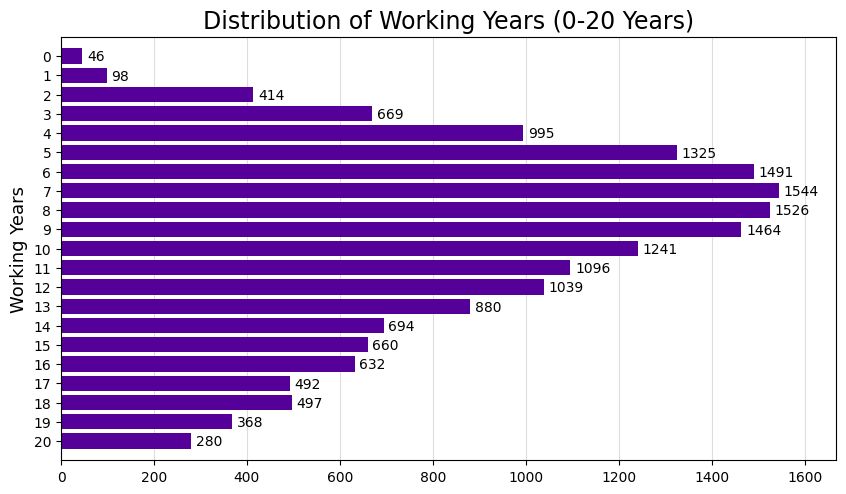

In [206]:
wy_dist = salaries['working_year'].value_counts().reset_index().sort_values('index')
plt.figure(figsize=(10,5.5))
plt.axis([0,wy_dist.iloc[:21,1].max()*1.08,21,-1])
plt.barh(wy_dist.iloc[:21,0], wy_dist.iloc[:21,1], color='#550099', zorder=2)
plt.title("Distribution of Working Years (0-20 Years)", fontsize=17)
for i in range(21):
    plt.text(wy_dist.iloc[i,1]+10, i+0.25, wy_dist.iloc[i,1], color='black', fontsize=10)
plt.ylabel('Working Years', fontsize=13)
plt.yticks(range(21), range(21))
plt.grid(color='#dddddd', axis='x', zorder=1)
plt.show()

### Distribution of Working Years (21+ Years)

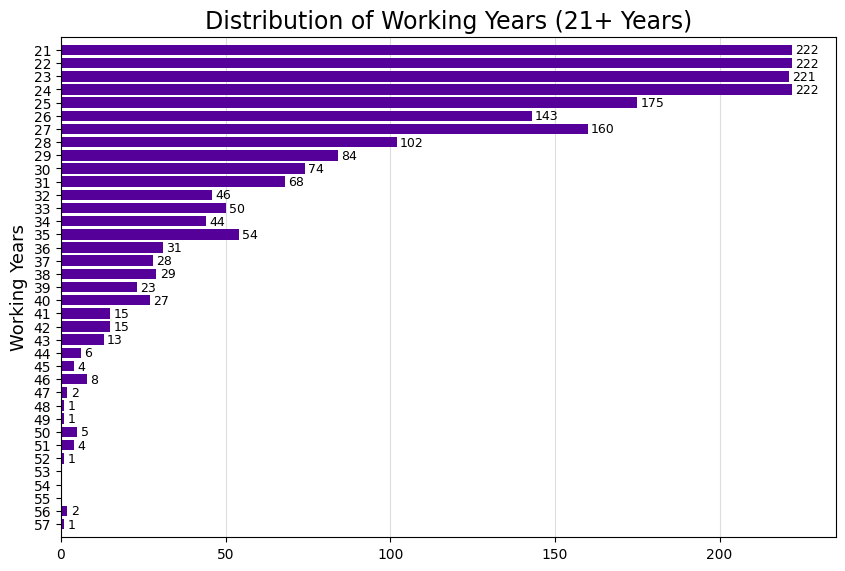

In [207]:
plt.figure(figsize=(10,6.5))
plt.axis([0,wy_dist.iloc[21:,1].max()*1.06,58,20])
plt.barh(wy_dist.iloc[21:,0], wy_dist.iloc[21:,1], color='#550099', zorder=2)
plt.title("Distribution of Working Years (21+ Years)", fontsize=17)
for i in range(21,len(wy_dist)):
    plt.text(wy_dist.iloc[i,1]+1, wy_dist.iloc[i,0]+0.3, wy_dist.iloc[i,1], color='black', fontsize=9)
plt.ylabel('Working Years', fontsize=13)
plt.yticks(range(21,58), range(21,58))
plt.grid(color='#dddddd', axis='x', zorder=1)
plt.show()

### Histogram of Company Scores

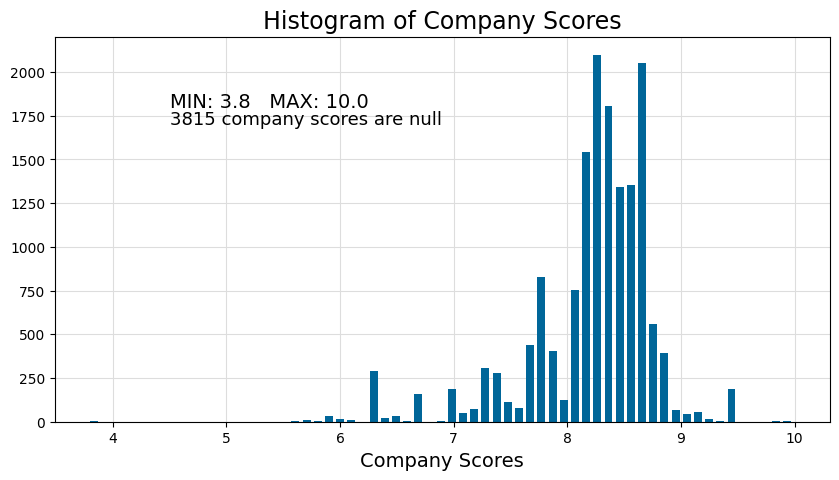

In [208]:
# drop_row = salaries[salaries['company_score'] == 0.0].index[0]  # This row had company score of 0.0, thus removed
plt.figure(figsize=(10,5))
# plt.hist(salaries['company_score'].drop(drop_row), color='#006699', bins=50, width=0.07, zorder=2)
plt.hist(salaries['company_score'], color='#006699', bins=63, width=0.07, zorder=2)
plt.text(4.5, 1800, "MIN: {}   MAX: {}".format(salaries['company_score'].min(), 
                                                salaries['company_score'].max()), fontsize=14)
plt.text(4.5, 1700, "{} company scores are null".format(salaries['company_score'].isnull().sum()), fontsize=13)
plt.title('Histogram of Company Scores', fontsize=17)
plt.xlabel('Company Scores', fontsize=14)
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Histogram of Education Scores

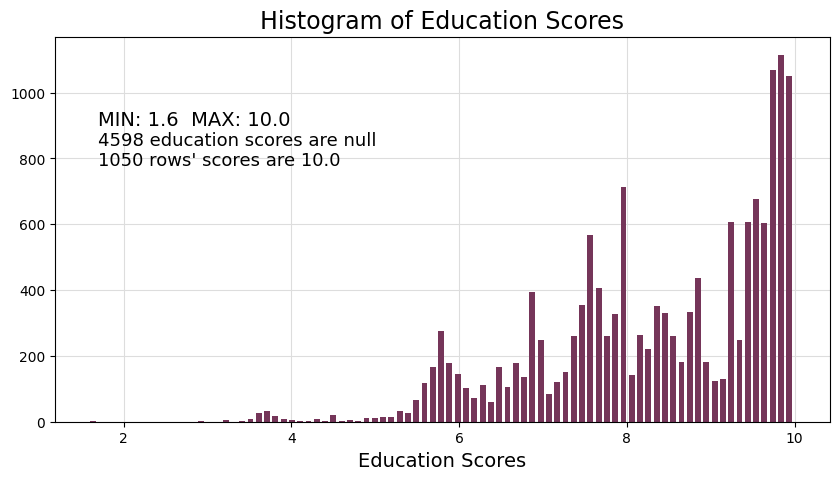

In [209]:
plt.figure(figsize=(10,5))
plt.hist(salaries['education_score'], color='#753559', bins=85, width=0.07, zorder=2)
plt.title("Histogram of Education Scores", fontsize=17)
plt.text(1.7, 900, "MIN: {}  MAX: {}".format(salaries['education_score'].min(), salaries['education_score'].max()),
        fontsize=14)
plt.text(1.7, 840, "{} education scores are null".format(salaries['education_score'].isnull().sum()), fontsize=13)
plt.text(1.7, 780, "{} rows' scores are 10.0".format(salaries[salaries['education_score'] == 10.0].shape[0]), fontsize=13)
plt.xlabel('Education Scores', fontsize=14)
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Histogram of Yearly Salaries

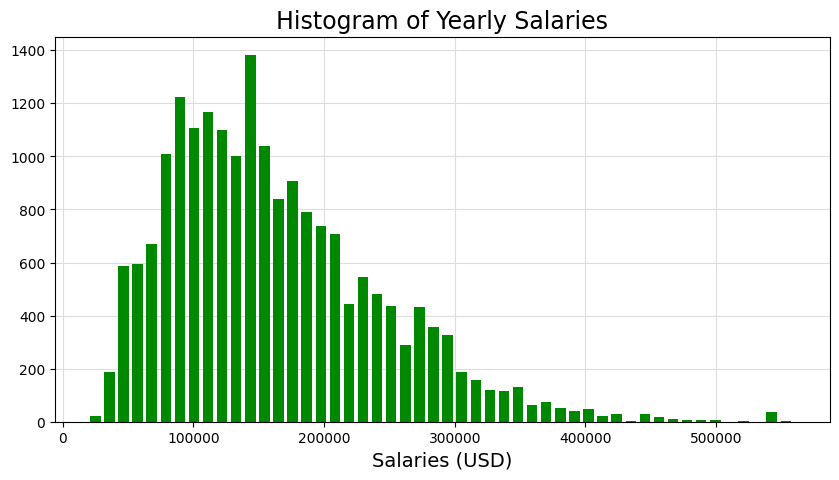

In [210]:
plt.figure(figsize=(10,5))
plt.hist(salaries['amount_usd'], bins=50, color='#008800', width=8000, zorder=2)
plt.title("Histogram of Yearly Salaries", fontsize=17)
plt.xlabel("Salaries (USD)", fontsize=14)
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Salary Counts Against Various Intervals

In [211]:
def visualize_salary_cnt_intv(slr_val, slr_intv, tag):
    slr_cnt = [0 for _ in range(8)]
    slr_intv_name = ['<'+str(slr_intv[0]//1000)+'K']
    for i in range(0,6):
        slr_intv_name.append(str(slr_intv[i]//1000)+'-'+str(slr_intv[i+1]//1000)+'K')
    slr_intv_name.append('>='+str(slr_intv[6]//1000)+'K')
    for x in slr_val:
        cond = 0 if x < slr_intv[0] else 1 if x >= slr_intv[0] and x < slr_intv[1] \
               else 2 if x >= slr_intv[1] and x < slr_intv[2] else 3 if x >= slr_intv[2] and x < slr_intv[3] \
               else 4 if x >= slr_intv[3] and x < slr_intv[4] else 5 if x >= slr_intv[4] and x < slr_intv[5] \
               else 6 if x >= slr_intv[5] and x < slr_intv[6] else 7
        slr_cnt[cond] += 1
    plt.figure(figsize=(10,5))
    plt.axis([-0.5,7.5,0,max(slr_cnt)*1.1])
    plt.bar(slr_intv_name, slr_cnt, width=0.6, color='#0000cc', zorder=2)
    for i in range(8):
        plt.text(i-0.2, slr_cnt[i]+50, "{:4}".format(slr_cnt[i]), fontsize=12, color='k')
    plt.title("Salary Counts Against Specified Intervals - "+tag, fontsize=17)
    plt.xlabel("Salary Intervals", fontsize=14)
    plt.ylabel("Total Counts", fontsize=14)
    plt.grid(color='#dddddd', axis='y', zorder=1)
    plt.show()

In [212]:
slr_val = salaries['amount_usd']
# TYPE 1
# slr_intv = [80000+(t*20000) for t in range(7)]
# visualize_salary_cnt_intv(slr_val, slr_intv, "Type 1")

In [213]:
# TYPE 2
# slr_intv = [80000+(t*30000) for t in range(7)]
# visualize_salary_cnt_intv(slr_val, slr_intv, "Type 2")

In [214]:
# TYPE 3
# slr_intv = [80000+(t*40000) for t in range(7)]
# visualize_salary_cnt_intv(slr_val, slr_intv, "Type 3")

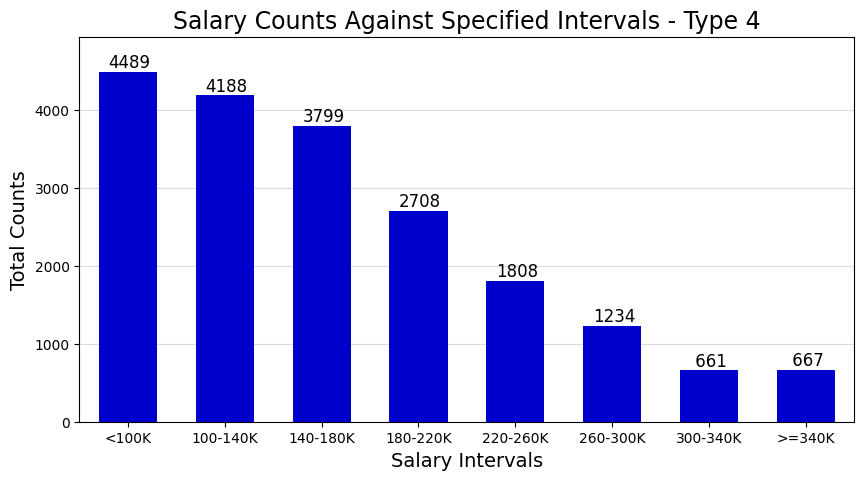

In [215]:
# TYPE 4
slr_intv = [100000+(t*40000) for t in range(7)]
visualize_salary_cnt_intv(slr_val, slr_intv, "Type 4")

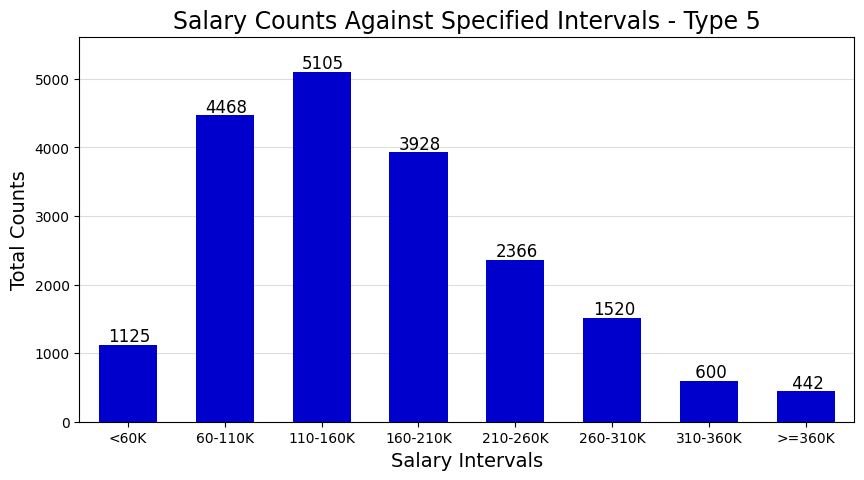

In [216]:
# TYPE 5
slr_intv = [60000+(t*50000) for t in range(7)]
visualize_salary_cnt_intv(slr_val, slr_intv, "Type 5")

### Working Years vs Main Skill Counts

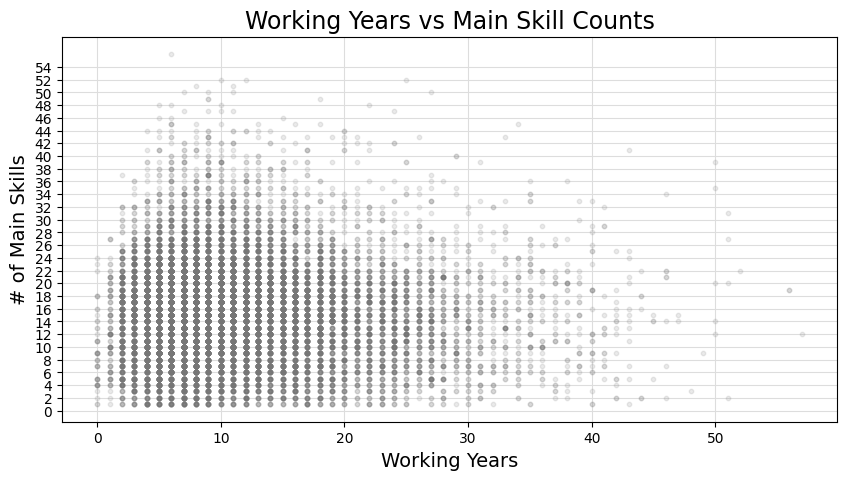

In [217]:
plt.figure(figsize=(10,5))
plt.scatter(salaries['working_year'],salaries['ms_counts'], s=10, alpha=0.15, color='#777777', zorder=2)
plt.title("Working Years vs Main Skill Counts", fontsize=17)
plt.xlabel("Working Years", fontsize=14)
plt.ylabel("# of Main Skills", fontsize=14)
plt.yticks([x for x in range(0,56,2)])
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Working Years vs Skill Counts

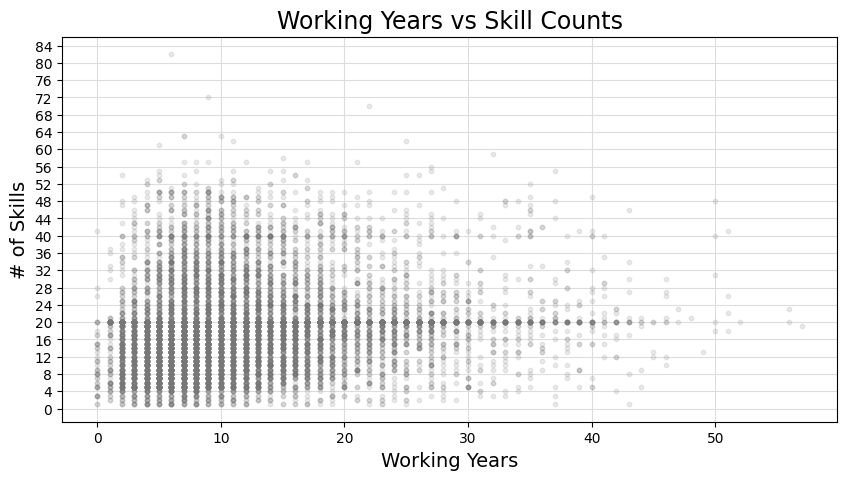

In [218]:
plt.figure(figsize=(10,5))
plt.scatter(salaries['working_year'],salaries['skill_counts'], s=10, alpha=0.15, color='#777777', zorder=2)
plt.title("Working Years vs Skill Counts", fontsize=17)
plt.xlabel("Working Years", fontsize=14)
plt.ylabel("# of Skills", fontsize=14)
plt.yticks([x for x in range(0,85,4)])
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Working Years vs Yearly Salaries

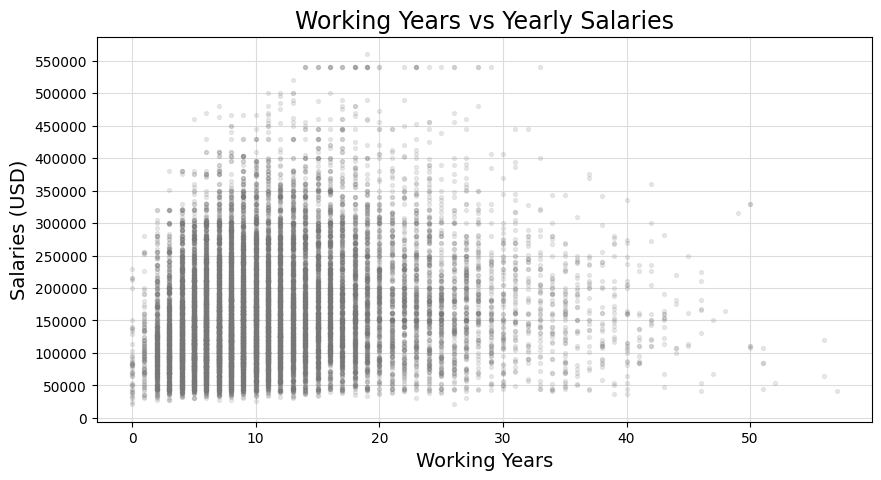

In [219]:
plt.figure(figsize=(10,5))
plt.scatter(salaries['working_year'],salaries['amount_usd'], s=8, alpha=0.15, color='#777777', zorder=2)
plt.title("Working Years vs Yearly Salaries", fontsize=17)
plt.xlabel("Working Years", fontsize=14)
plt.ylabel("Salaries (USD)", fontsize=14)
plt.yticks([x for x in range(0,600000,50000)])
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Main Skill Counts vs Yearly Salaries

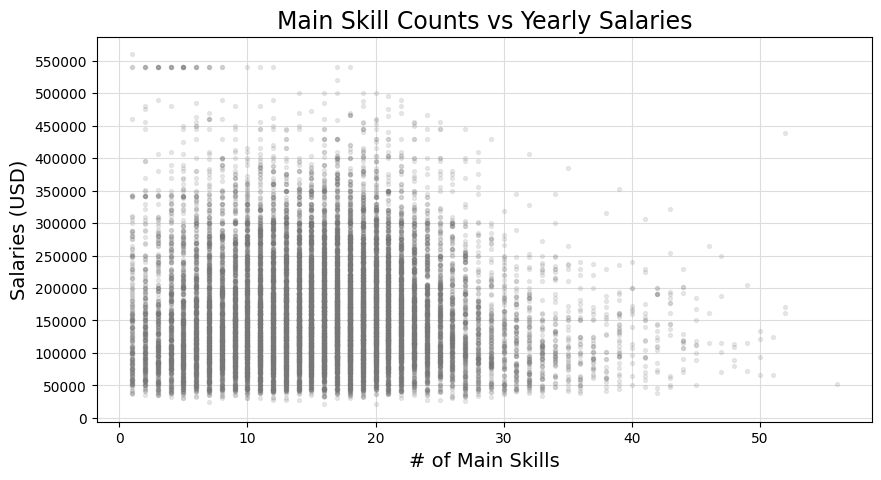

In [220]:
plt.figure(figsize=(10,5))
plt.scatter(salaries['ms_counts'],salaries['amount_usd'], s=8, alpha=0.15, color='#777777', zorder=2)
plt.title("Main Skill Counts vs Yearly Salaries", fontsize=17)
plt.xlabel("# of Main Skills", fontsize=14)
plt.ylabel("Salaries (USD)", fontsize=14)
plt.yticks([x for x in range(0,600000,50000)])
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Skill Counts vs Yearly Salaries

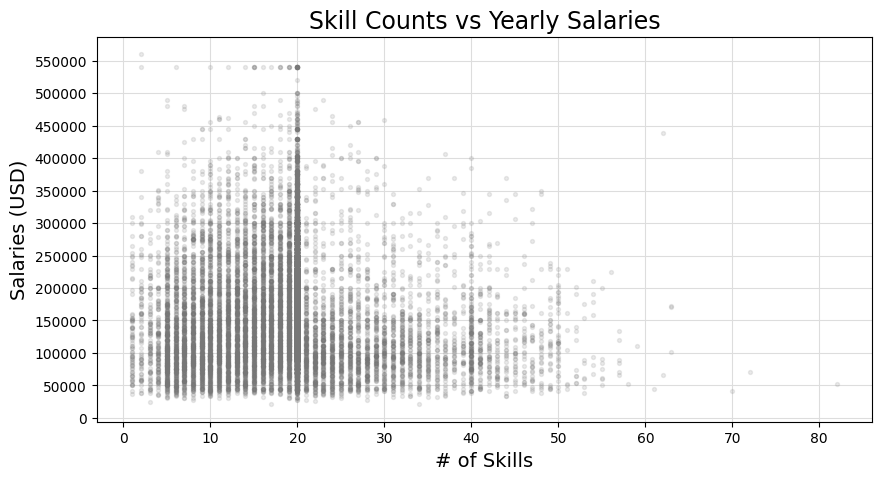

In [221]:
plt.figure(figsize=(10,5))
plt.scatter(salaries['skill_counts'],salaries['amount_usd'], s=8, alpha=0.15, color='#777777', zorder=2)
plt.title("Skill Counts vs Yearly Salaries", fontsize=17)
plt.xlabel("# of Skills", fontsize=14)
plt.ylabel("Salaries (USD)", fontsize=14)
plt.yticks([x for x in range(0,600000,50000)])
plt.grid(color='#dddddd', zorder=1)
plt.show()

### Column Correlations Against Salaries

In [222]:
# Heatmap was disabled because of increasing complexity of added columns afterwards
# plt.figure(figsize=(10.5,6.5))
# sns.heatmap(salaries[selected_columns].corr(),
#            cmap='vlag', annot=True, annot_kws={'size': 7}, fmt='.2f', vmin=-1, vmax=1)
# plt.title("Correlation of Numerical Columns in Heatmap", fontsize=17)
# plt.show()
selected_columns = ['company_score','working_year','education_score','ms_counts','skill_counts',
                    'country_coef','country_usa','country_uk',
                    'title_has_seniority','title_slr_coef','title_seniority_slr_coef','tt_software_eng','tt_data_analyst',
                    'tt_data_scientist','tt_machine_learning','tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng',
                    'tt_bi_analyst','tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer',
                    'position_has_seniority','position_slr_coef','position_seniority_slr_coef','pos_software_eng','pos_data_analyst',
                    'pos_data_scientist','pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager',
                    'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng',
                    'employment_full_time','employment_type_coef','employment_type_slr_coef',
                    'highest_edu_deg_lvl','edu_deg_slr_coef','phd_degree','master_degree','undergrad_degree',
                    'edu_degree_major_coef_max','edu_degree_major_coef_avg','ed_arts','ed_business_admin','ed_computer_eng',
                    'ed_computer_science','ed_electric_electronic','ed_info_tech','ed_math','ed_philosophy',
                    'company_slr_coef','comp_amazon','comp_google','comp_oracle','comp_microsoft','comp_meta','comp_apple','comp_cisco',
                    'comp_aws','comp_ibm','comp_linkedin','comp_capitalone','comp_jpmorgan','comp_intel','comp_saic',
                    'comp_tata','comp_intuit','comp_uber','comp_qualcomm','comp_salesforce','comp_stripe',
                    'main_skill_slr_coef_max','main_skill_slr_coef_avg',
                    'ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming','ms_java','ms_office',
                    'ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res','ms_sales_market','ms_html','ms_mac_learn',
                    'ms_proj_man','ms_software_dev','ms_cust_serv','ms_research',
                    'skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly',
                    'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man',
                    'skill_html','skill_communication',
                    # 'company_score_nafilled0','company_score_nafilled1','company_score_nafilled2','company_score_nafilled3',
                    # 'company_score_nafilled4','company_score_nafilled5','company_score_nafilled6','company_score_nafilled7',
                    # 'company_score_nafilled8','company_score_nafilled9','company_score_nafilled10',
                    'amount_usd']

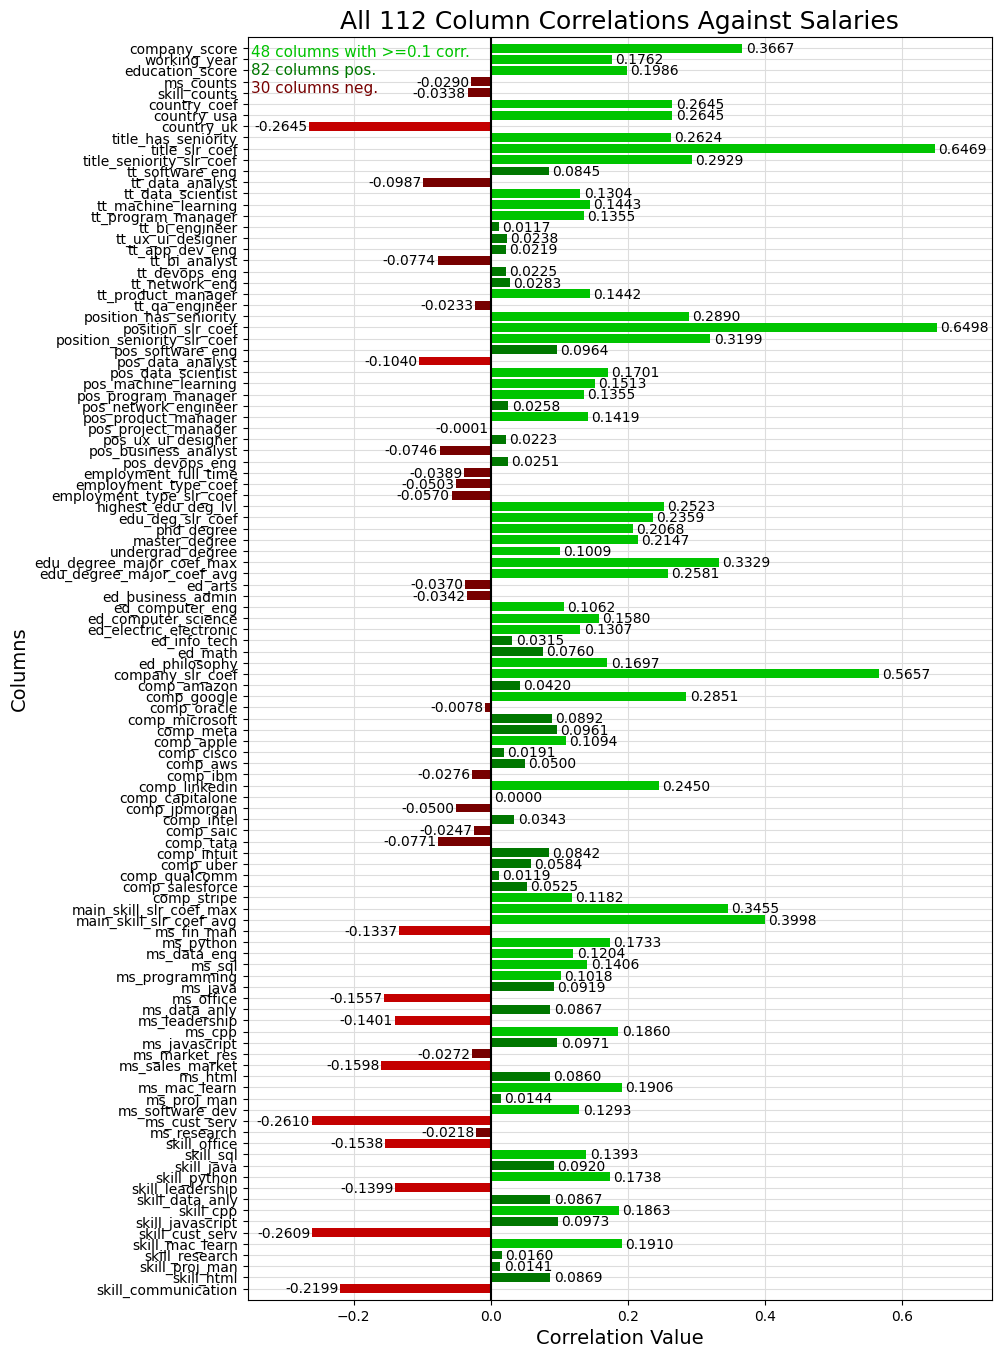

In [223]:
correlations = salaries[selected_columns].corr()['amount_usd'].drop('amount_usd')
# print(len(correlations))
colors = [];   high_pos_corr = 0;   pos_corr = 0;   neg_corr = 0;
# for i in range(len(correlations)):
#     if correlations[i] >= 0.15 or correlations[i] <= -0.15:   colors.append('#0088dd')
#     else:   colors.append('#000099')
for i in range(len(correlations)):
    if correlations[i] >= 0.1:   colors.append('#00c400');  high_pos_corr += 1
    elif correlations[i] >= 0.0:   colors.append('#007700')
    elif correlations[i] >= -0.1:   colors.append('#770000')
    else:   colors.append('#c40000')
    if correlations[i] >= 0.0:   pos_corr += 1
    else:   neg_corr += 1
plt.figure(figsize=(9.6,16.4))
plt.axis([correlations.min()-0.09,correlations.max()+0.08,len(correlations),-1.0])
plt.barh(correlations.index, correlations, color=colors, zorder=2)
for i in range(len(correlations)):
    if correlations[i] >= 0.0:   plt.text(correlations[i]+0.005, i+0.4, "{:.4f}".format(correlations[i]))
    else:   plt.text(correlations[i]-0.08, i+0.4, "{:.4f}".format(correlations[i]))
plt.text(-0.35,0.8,str(high_pos_corr)+" columns with >=0.1 corr.", fontsize=11, color='#00c400')
plt.text(-0.35,2.4,str(pos_corr)+" columns pos.", fontsize=11, color='#007700')
plt.text(-0.35,4.0,str(neg_corr)+" columns neg.", fontsize=11, color='#770000')
plt.axvline(0, color='black')
plt.title("All {} Column Correlations Against Salaries".format(len(correlations)), fontsize=18)
plt.xlabel("Correlation Value", fontsize=14)
plt.ylabel("Columns", fontsize=14)
plt.grid(color='#dddddd', zorder=1)
plt.show()

In [224]:
# Sort the correlation values for easier interpretation
top_limit = 20
pos_corrs = correlations.sort_values(ascending=False)[:top_limit]
neg_corrs = correlations.sort_values()[:top_limit]
print("### MOST POSITIVE CORRELATIONS ###     |  ### MOST NEGATIVE CORRELATIONS ###")
for i in range(top_limit):
    print("{:27}  {:.6f}  |  {:25}  {:.6f}".format(
        pos_corrs.index[i], pos_corrs[i], neg_corrs.index[i], neg_corrs[i]))

### MOST POSITIVE CORRELATIONS ###     |  ### MOST NEGATIVE CORRELATIONS ###
position_slr_coef            0.649842  |  country_uk                 -0.264521
title_slr_coef               0.646858  |  ms_cust_serv               -0.260985
company_slr_coef             0.565727  |  skill_cust_serv            -0.260886
main_skill_slr_coef_avg      0.399793  |  skill_communication        -0.219868
company_score                0.366749  |  ms_sales_market            -0.159767
main_skill_slr_coef_max      0.345524  |  ms_office                  -0.155723
edu_degree_major_coef_max    0.332895  |  skill_office               -0.153803
position_seniority_slr_coef  0.319895  |  ms_leadership              -0.140109
title_seniority_slr_coef     0.292946  |  skill_leadership           -0.139874
position_has_seniority       0.289016  |  ms_fin_man                 -0.133738
comp_google                  0.285069  |  pos_data_analyst           -0.104032
country_usa                  0.264521  |  tt_data_anal

## FINAL DATASET AFTER EDA

In [225]:
# The final status of salary dataset with added columns on the right
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,...,0,0,1,0,0,0,0,0,1,0
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,...,0,0,0,0,1,0,0,0,0,1
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,...,0,0,0,0,0,0,0,0,0,1
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,...,0,0,0,0,0,0,0,0,0,0
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,...,0,0,0,1,0,0,1,0,0,0


In [226]:
salaries.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19554 entries, 0 to 19556
Columns: 135 entries, id to skill_communication
dtypes: float64(27), int64(98), object(10)
memory usage: 20.3+ MB


In [227]:
salaries.columns

Index(['id', 'found_country', 'title', 'position', 'employment_type',
       'company', 'company_score', 'edu_degrees', 'edu_degrees_major',
       'working_year',
       ...
       'skill_leadership', 'skill_data_anly', 'skill_cpp', 'skill_javascript',
       'skill_cust_serv', 'skill_mac_learn', 'skill_research',
       'skill_proj_man', 'skill_html', 'skill_communication'],
      dtype='object', length=135)

In [228]:
salaries.describe()

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd,country_coef,country_usa,country_uk,title_slr_coef,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
count,15739.000000,19554.000000,14956.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,...,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000
mean,8.248993,11.449882,8.401484,15.738008,18.777948,163366.552981,0.966054,0.912959,0.087041,0.452360,...,0.258055,0.211824,0.197095,0.177202,0.179094,0.153370,0.205840,0.168252,0.169275,0.193157
std,0.561583,7.213469,1.383108,7.306042,7.814769,81118.159433,0.109942,0.281902,0.281902,0.145708,...,0.437575,0.408611,0.397815,0.381849,0.383441,0.360353,0.404325,0.374099,0.375004,0.394786
min,3.800000,0.000000,1.600000,1.000000,1.000000,21000.000000,0.610000,0.000000,0.000000,0.102000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.100000,6.000000,7.500000,11.000000,15.000000,102000.000000,1.000000,1.000000,0.000000,0.350000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.400000,10.000000,8.600000,16.000000,20.000000,150000.000000,1.000000,1.000000,0.000000,0.484000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.600000,15.000000,9.700000,20.000000,20.000000,210000.000000,1.000000,1.000000,0.000000,0.539000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,57.000000,10.000000,56.000000,82.000000,560000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [229]:
# salaries.to_csv('Salaries_v3_202412161100(expanded).csv')
# print("Salary dataset was saved to the disk successfully...")